# Modelo de Prediccion de Aceptacion de CDT (Certificado de Deposito a Termino)

## Descripcion del Proyecto

Este notebook implementa un modelo de clasificacion binaria para predecir si un cliente de un banco aceptara o no un Certificado de Deposito a Termino (CDT). El proyecto incluye todas las etapas del proceso de ciencia de datos:

1. **Preparacion del Entorno**: Instalacion de dependencias y carga de librerias
2. **Carga de Datos**: Descarga desde Kaggle y exploracion inicial
3. **Limpieza y Transformacion**: Eliminacion de variables, manejo de nulos, traduccion
4. **Ingenieria de Caracteristicas**: Codificacion, escalado, creacion de quintiles
5. **Analisis Exploratorio**: Estadisticas descriptivas, correlaciones, Information Value
6. **Modelacion**: Entrenamiento de 7 modelos de clasificacion + 1 ensamble
7. **Evaluacion**: Comparacion de metricas y seleccion del mejor modelo

## Como Ejecutar el Notebook

1. Ejecutar las celdas en orden secuencial de arriba hacia abajo
2. La primera celda instalara las dependencias necesarias
3. Los modelos entrenados se guardaran automaticamente en la carpeta `archivos_modelo/`
4. El resultado final es un dataframe `mejor_modelo` con todas las predicciones

---



## 1. Instalacion de Dependencias

Ejecutar esta celda para instalar las librerias adicionales necesarias que no vienen con la instalacion estandar de Python.

In [1]:
!pip install kagglehub==1.0.0
!pip install lightgbm

## 2. Importar Librerias

Esta celda carga todas las librerias necesarias para el proyecto:

| Libreria | Proposito |
|----------|-----------|
| `pandas`, `numpy` | Manipulacion y analisis de datos |
| `matplotlib`, `seaborn` | Visualizacion de graficos |
| `sklearn` | Modelos de Machine Learning, preprocesamiento y metricas |
| `lightgbm` | Algoritmo de Gradient Boosting |
| `joblib` | Serializacion de modelos para produccion |
| `kagglehub` | Descarga de datasets desde Kaggle |

Tambien se configura la carpeta `archivos_modelo/` donde se guardaran todos los artefactos del modelo.

In [2]:
import os # Acceso a archivos del sistema
import kagglehub # Descarga de la base de datos utilizada

# Manipulación de datos
import pandas as pd
import numpy as np

# Para gráficas
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


# Modelos utilizados
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Procesamiento de datos
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import joblib # Serialización de datos
from pathlib import Path

# Métricas de evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Detectar raíz del proyecto y asegurar carpeta `archivos_modelo`
# Buscamos hacia arriba desde el cwd hasta encontrar la carpeta del proyecto o un README
cwd = Path.cwd()
project_root = cwd
for p in [cwd] + list(cwd.parents):
    if (p / 'archivos_modelo').exists() or (p / 'README.md').exists():
        project_root = p
        break

model_dir = project_root / 'archivos_modelo'
model_dir.mkdir(parents=True, exist_ok=True)

# Cambiar directorio de trabajo al model_dir para operaciones relativas
os.chdir(model_dir)
print(f"Directorio de trabajo actual seteado en: {model_dir}")

pd.set_option('display.max_columns', None)

Directorio de trabajo actual seteado en: d:\-CDT-acceptance-test-model-main\archivos_modelo


---

## 3. Acceso a la Base de Datos

### Fuente de Datos

El dataset utilizado proviene de Kaggle y contiene informacion de clientes bancarios. La celda siguiente descarga automaticamente los datos usando la API de Kaggle.

**Nota Importante:** Para que la descarga funcione, debes tener configurada tu API key de Kaggle. Puedes obtenerla desde tu perfil en kaggle.com y guardarla en `~/.kaggle/kaggle.json`.

**URL del Dataset:** https://www.kaggle.com/datasets/kidoen/bank-customers-data

El dataset contiene aproximadamente 45,000 registros de clientes con variables demograficas, financieras y de comportamiento.

In [3]:
# Descarga de la bas de datos
path = kagglehub.dataset_download("kidoen/bank-customers-data")
print("Ruta para la descarga de archivos:", path)
files = os.listdir(path)
print("Archivos en el directorio:", files, "\n\n")

csv_file = [f for f in files][0]

data_orig = pd.read_csv(os.path.join(path, csv_file))

display(data_orig.head())

Ruta para la descarga de archivos: C:\Users\Usuario\.cache\kagglehub\datasets\kidoen\bank-customers-data\versions\2
Archivos en el directorio: ['BankCustomerData.csv'] 




,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,term_deposit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df = data_orig.copy()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42639 entries, 0 to 42638
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           42639 non-null  int64 
 1   job           42639 non-null  object
 2   marital       42639 non-null  object
 3   education     42639 non-null  object
 4   default       42639 non-null  object
 5   balance       42639 non-null  int64 
 6   housing       42639 non-null  object
 7   loan          42639 non-null  object
 8   contact       42639 non-null  object
 9   day           42639 non-null  int64 
 10  month         42639 non-null  object
 11  duration      42639 non-null  int64 
 12  campaign      42639 non-null  int64 
 13  pdays         42639 non-null  int64 
 14  previous      42639 non-null  int64 
 15  poutcome      42639 non-null  object
 16  term_deposit  42639 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.5+ MB


---

## 4. Limpieza de Datos

### 4.1 Eliminacion de Variables

Se eliminan las variables que no pueden ser conocidas previamente a la prediccion o que tienen connotaciones temporales que podrian causar fuga de datos (data leakage):

| Variable Eliminada | Razon |
|-------------------|-------|
| `day`, `month` | Informacion temporal, se opta por no agregarla para realizar un modelo atemporal |
| `duration` | Duracion de la llamada, solo conocida despues del contacto |
| `campaign` | Numero de contactos durante la campana actual |
| `pdays`, `previous`, `poutcome` | Informacion de campanas anteriores |
| `contact` | Tipo de contacto, variable operativa |

La siguiente celda elimina las columnas mencionadas del DataFrame.

In [6]:
# Borrar
df = df.drop(columns=['day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'contact'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42639 entries, 0 to 42638
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           42639 non-null  int64 
 1   job           42639 non-null  object
 2   marital       42639 non-null  object
 3   education     42639 non-null  object
 4   default       42639 non-null  object
 5   balance       42639 non-null  int64 
 6   housing       42639 non-null  object
 7   loan          42639 non-null  object
 8   term_deposit  42639 non-null  object
dtypes: int64(2), object(7)
memory usage: 2.9+ MB


### 4.2 Verificacion de Nulidad

Se verifica si existen valores nulos en el dataset que requieran tratamiento (imputacion o eliminacion).

In [8]:
# Verificación nulos

conteo_nulos = df.isnull().sum()
columnas_nulas = conteo_nulos[conteo_nulos > 0]

if not columnas_nulas.empty:
    print("Columnas con registros nulos y su cantidad:")
    print(columnas_nulas)
else:
    print("No hay columnas con registros nulos en el DataFrame.")

No hay columnas con registros nulos en el DataFrame.


**Resultado:** El dataframe no contiene registros nulos, por lo que no es necesario realizar imputaciones ni eliminar filas.

---

## 5. Procesamiento y Transformacion de Datos

### 5.1 Traduccion de Variables

Para facilitar la interpretacion y el uso posterior en la aplicacion Streamlit, todas las variables y sus valores se traducen del ingles al espanol.

La siguiente celda renombra las columnas del DataFrame al espanol:

In [9]:
nombre_columnas = {
    'age': 'edad',
    'job': 'empleo',
    'marital': 'estado_civil',
    'education': 'nivel_educativo',
    'default': 'incumplimiento',
    'balance': 'saldo',
    'housing': 'prestamo_vivienda',
    'loan': 'prestamo_consumo',
    'term_deposit': 'cdt'
}

df = df.rename(columns=nombre_columnas)

print("Columnas del DataFrame después de renombrar:")
print(df.columns)
del nombre_columnas

Columnas del DataFrame después de renombrar:
Index(['edad', 'empleo', 'estado_civil', 'nivel_educativo', 'incumplimiento',
       'saldo', 'prestamo_vivienda', 'prestamo_consumo', 'cdt'],
      dtype='object')


In [10]:
for column in df.columns:
    if df[column].dtype == 'object':
        print(column.upper())
        print('=====================================')
        # Se ordenan los valores por variable
        print(df[column].sort_values().unique() ,"\n\n\n")

EMPLEO
['admin.' 'blue-collar' 'entrepreneur' 'housemaid' 'management' 'retired'
 'self-employed' 'services' 'student' 'technician' 'unemployed' 'unknown'] 



ESTADO_CIVIL
['divorced' 'married' 'single'] 



NIVEL_EDUCATIVO
['primary' 'secondary' 'tertiary' 'unknown'] 



INCUMPLIMIENTO
['no' 'yes'] 



PRESTAMO_VIVIENDA
['no' 'yes'] 



PRESTAMO_CONSUMO
['no' 'yes'] 



CDT
['no' 'yes'] 





In [11]:
# Mapeo para la columna 'empleo'
empleo_mapping = {
    'admin.': 'administrador',
    'blue-collar': 'obrero',
    'entrepreneur': 'empresario',
    'housemaid': 'empleada_hogar',
    'management': 'gestion',
    'retired': 'jubilado',
    'self-employed': 'autonomo',
    'services': 'servicios',
    'student': 'estudiante',
    'technician': 'tecnico',
    'unemployed': 'desempleado',
    'unknown': 'desconocido'
}
df['empleo'] = df['empleo'].replace(empleo_mapping)

# Mapeo para la columna 'estado_civil'
estado_civil_mapping = {
    'divorced': 'divorciado',
    'married': 'casado',
    'single': 'soltero'
}
df['estado_civil'] = df['estado_civil'].replace(estado_civil_mapping)

# Mapeo para la columna 'educacion'
educacion_mapping = {
    'primary': 'basica',
    'secondary': 'media',
    'tertiary': 'superior',
    'unknown': 'desconocida'
}
df['nivel_educativo'] = df['nivel_educativo'].replace(educacion_mapping)

# Mapeo para incumplimiento, vivienda, prestamo, deposito_a_termino
binary_mapping = {'yes': 'si', 'no': 'no'}
df['incumplimiento'] = df['incumplimiento'].replace(binary_mapping)
df['prestamo_vivienda'] = df['prestamo_vivienda'].replace(binary_mapping)
df['prestamo_consumo'] = df['prestamo_consumo'].replace(binary_mapping)
df['cdt'] = df['cdt'].replace(binary_mapping)


print("Valores categóricos traducidos.")

del empleo_mapping, estado_civil_mapping, educacion_mapping, binary_mapping

Valores categóricos traducidos.


In [12]:
for column in df.columns:
    if df[column].dtype == 'object':
        print(column.upper())
        print('=====================================')
        # Se ordenan los valores por variable
        print(df[column].sort_values().unique() ,"\n\n\n")

EMPLEO
['administrador' 'autonomo' 'desconocido' 'desempleado' 'empleada_hogar'
 'empresario' 'estudiante' 'gestion' 'jubilado' 'obrero' 'servicios'
 'tecnico'] 



ESTADO_CIVIL
['casado' 'divorciado' 'soltero'] 



NIVEL_EDUCATIVO
['basica' 'desconocida' 'media' 'superior'] 



INCUMPLIMIENTO
['no' 'si'] 



PRESTAMO_VIVIENDA
['no' 'si'] 



PRESTAMO_CONSUMO
['no' 'si'] 



CDT
['no' 'si'] 





### 5.2 Conversion de Tipos de Datos

Se convierten las columnas de tipo `object` a tipo `category` para optimizar el uso de memoria y mejorar el rendimiento.

In [13]:
df.dtypes

edad                  int64
empleo               object
estado_civil         object
nivel_educativo      object
incumplimiento       object
saldo                 int64
prestamo_vivienda    object
prestamo_consumo     object
cdt                  object
dtype: object

In [14]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

print("Tipos de datos actualizados:")
df.dtypes

Tipos de datos actualizados:


edad                    int64
empleo               category
estado_civil         category
nivel_educativo      category
incumplimiento       category
saldo                   int64
prestamo_vivienda    category
prestamo_consumo     category
cdt                  category
dtype: object

In [15]:
df.shape


(42639, 9)

### 5.3 Estadisticas Descriptivas

Analisis exploratorio de las variables numericas y categoricas del dataset. Este paso permite entender la distribucion de los datos antes de aplicar transformaciones.

In [16]:
# Descripción estadística de variables numéricas
print("=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 80)
display(df[['edad','saldo']].describe().round(1))

print("\n" + "=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS")
print("=" * 80)

variables_categoricas = ['empleo', 'estado_civil', 'nivel_educativo', 'incumplimiento', 
                         'prestamo_vivienda', 'prestamo_consumo', 'cdt']

for var in variables_categoricas:
    print(f"\n{var.upper()}:")
    print(f"  Categorías: {df[var].nunique()}")
    print(f"  Valores faltantes: {df[var].isna().sum()}")
    
    # Obtener conteos y porcentajes
    value_counts = df[var].value_counts().round(0)
    percentages = (df[var].value_counts(normalize=True) * 100).round(2)
    
    # Crear tabla combinada
    tabla = pd.DataFrame({
        'Frecuencia': value_counts,
        'Porcentaje': percentages
    })
    
    # Agregar total
    tabla.loc['TOTAL'] = [tabla['Frecuencia'].sum(), tabla['Porcentaje'].sum()]
    
    display(tabla)

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,edad,saldo
count,42639.0,42639.0
mean,40.8,1331.9
std,10.2,3011.5
min,18.0,-8019.0
25%,33.0,62.0
50%,39.0,429.0
75%,48.0,1381.5
max,95.0,102127.0



ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS

EMPLEO:
  Categorías: 12
  Valores faltantes: 0


,Frecuencia,Porcentaje
empleo,,
obrero,9536.0,22.36
gestion,8851.0,20.76
tecnico,7223.0,16.94
administrador,4810.0,11.28
servicios,4033.0,9.46
jubilado,1880.0,4.41
autonomo,1500.0,3.52
empresario,1453.0,3.41
desempleado,1193.0,2.80



ESTADO_CIVIL:
  Categorías: 3
  Valores faltantes: 0


...

,Frecuencia,Porcentaje
prestamo_vivienda,,
si,24590.0,57.67
no,18049.0,42.33
TOTAL,42639.0,100.00



PRESTAMO_CONSUMO:
  Categorías: 2
  Valores faltantes: 0


,Frecuencia,Porcentaje
prestamo_consumo,,
no,35554.0,83.38
si,7085.0,16.62
TOTAL,42639.0,100.00



CDT:
  Categorías: 2
  Valores faltantes: 0


,Frecuencia,Porcentaje
cdt,,
no,38678.0,90.71
si,3961.0,9.29
TOTAL,42639.0,100.00


### 5.4 Visualizacion de Distribuciones

Los siguientes graficos muestran la distribucion de las variables numericas clave: edad y saldo. Esto permite identificar la forma de la distribucion, valores atipicos y patrones generales.

Edad - Q1: 33.00, Q3: 48.00, IQR: 15.00
Rango normal (IQR): 10.50 - 70.50
Atípicos detectados: 295



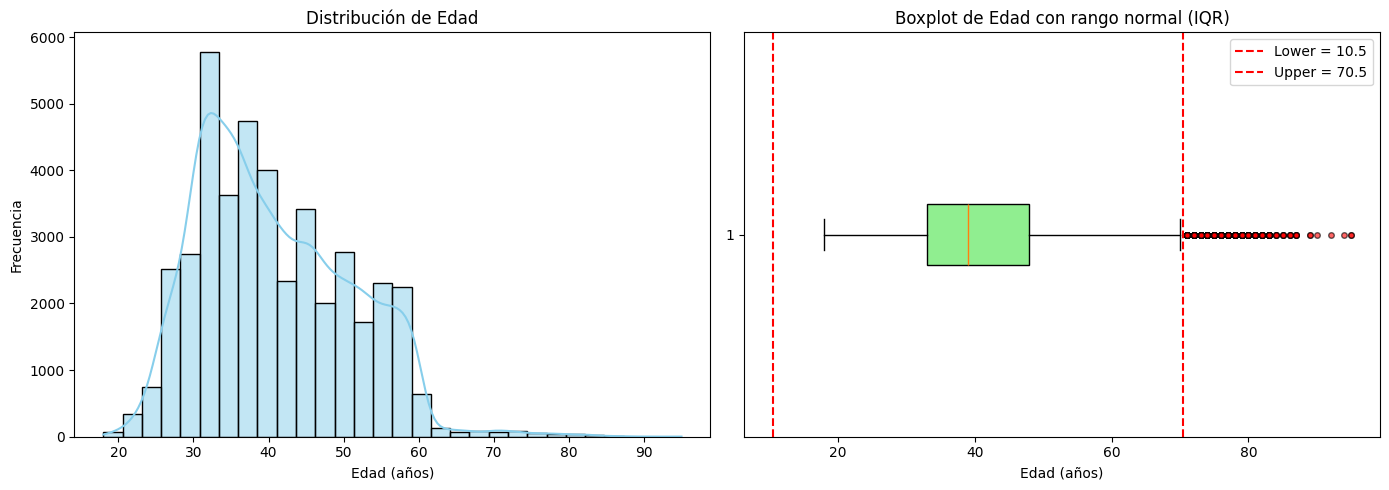

Estadísticas de atípicos (edad):
count    295.000000
mean      76.596610
std        4.871476
min       71.000000
25%       73.000000
50%       76.000000
75%       80.000000
max       95.000000
Name: edad, dtype: float64


In [17]:
# Distribución de edad y boxplot con rango normal (IQR)

q1 = df['edad'].quantile(0.25)
q3 = df['edad'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['edad'] < lower) | (df['edad'] > upper)]['edad']

print(f"Edad - Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"Rango normal (IQR): {lower:.2f} - {upper:.2f}")
print(f"Atípicos detectados: {len(outliers)}\n")

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histograma + KDE
sns.histplot(df['edad'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')

# Boxplot horizontal
axes[1].boxplot(df['edad'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='black'),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.6))
axes[1].set_title('Boxplot de Edad con rango normal (IQR)')
axes[1].set_xlabel('Edad (años)')

# Líneas verticales para los límites IQR
axes[1].axvline(lower, color='red', linestyle='--', linewidth=1.5, label=f'Lower = {lower:.1f}')
axes[1].axvline(upper, color='red', linestyle='--', linewidth=1.5, label=f'Upper = {upper:.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Mostrar estadísticas de los atípicos
if not outliers.empty:
    print('Estadísticas de atípicos (edad):')
    print(outliers.describe())
else:
    print('No se detectaron atípicos en edad según IQR.')

### 5.5 Analisis de Outliers

Se utiliza el metodo del Rango Intercuartilico (IQR) para identificar valores atipicos en las variables numericas. Los outliers pueden afectar el rendimiento de algunos modelos.

Saldo - Q1: 62.00, Q3: 1381.50, IQR: 1319.50
Rango normal (IQR): -1917.25 - 3360.75
Atípicos detectados: 4535



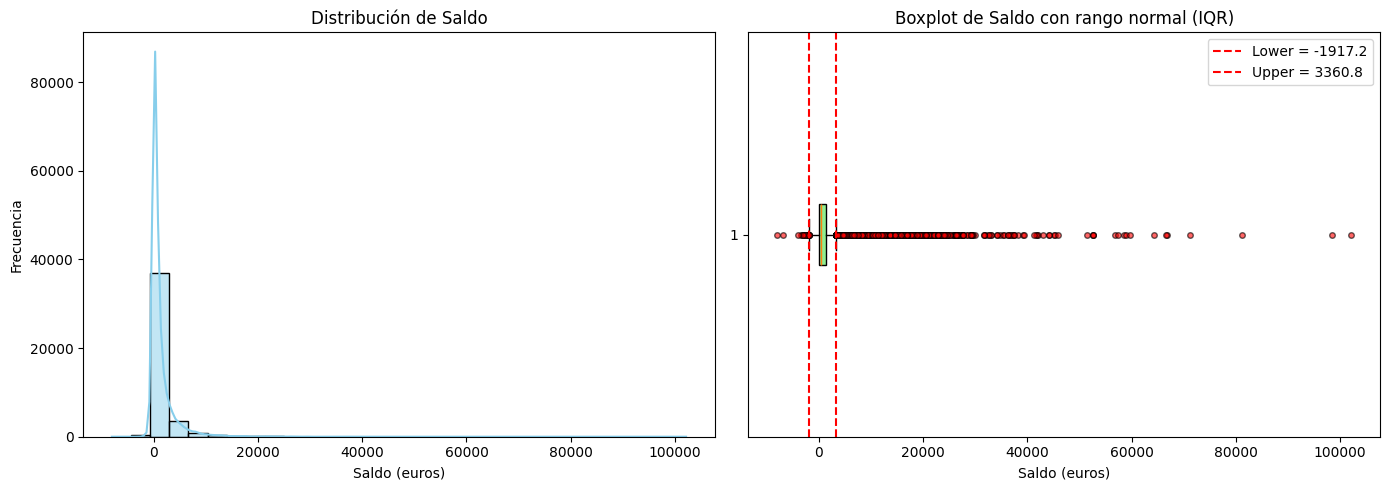

Estadísticas de atípicos (saldo):
count      4535.000000
mean       7391.351268
std        6210.266491
min       -8019.000000
25%        4174.000000
50%        5511.000000
75%        8149.000000
max      102127.000000
Name: saldo, dtype: float64


In [18]:
# Distribución de saldo y boxplot con rango normal (IQR)

q1 = df['saldo'].quantile(0.25)
q3 = df['saldo'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['saldo'] < lower) | (df['saldo'] > upper)]['saldo']

print(f"Saldo - Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"Rango normal (IQR): {lower:.2f} - {upper:.2f}")
print(f"Atípicos detectados: {len(outliers)}\n")

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histograma + KDE
sns.histplot(df['saldo'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Saldo')
axes[0].set_xlabel('Saldo (euros)')
axes[0].set_ylabel('Frecuencia')

# Boxplot horizontal
axes[1].boxplot(df['saldo'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='black'),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.6))
axes[1].set_title('Boxplot de Saldo con rango normal (IQR)')
axes[1].set_xlabel('Saldo (euros)')

# Líneas verticales para los límites IQR
axes[1].axvline(lower, color='red', linestyle='--', linewidth=1.5, label=f'Lower = {lower:.1f}')
axes[1].axvline(upper, color='red', linestyle='--', linewidth=1.5, label=f'Upper = {upper:.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Mostrar estadísticas de los atípicos
if not outliers.empty:
    print('Estadísticas de atípicos (saldo):')
    print(outliers.describe())
else:
    print('No se detectaron atípicos en saldo según IQR.')

In [19]:
# Modificar saldo para reducir impacto de atípicos
# Los valores negativos se establecen en 0
# Finalmente se aplicara una funcion logarítmica (variable+1) para reducir la escala de los valores altos, manteniendo la relación entre ellos
df['saldo'] = df['saldo'].apply(lambda x: 0 if x < 0 else x)
df['saldo'] = df['saldo'].apply(lambda x: np.log(x+1))

Saldo - Q1: 4.14, Q3: 7.23, IQR: 3.09
Rango normal (IQR): -0.49 - 11.86
Atípicos detectados: 0



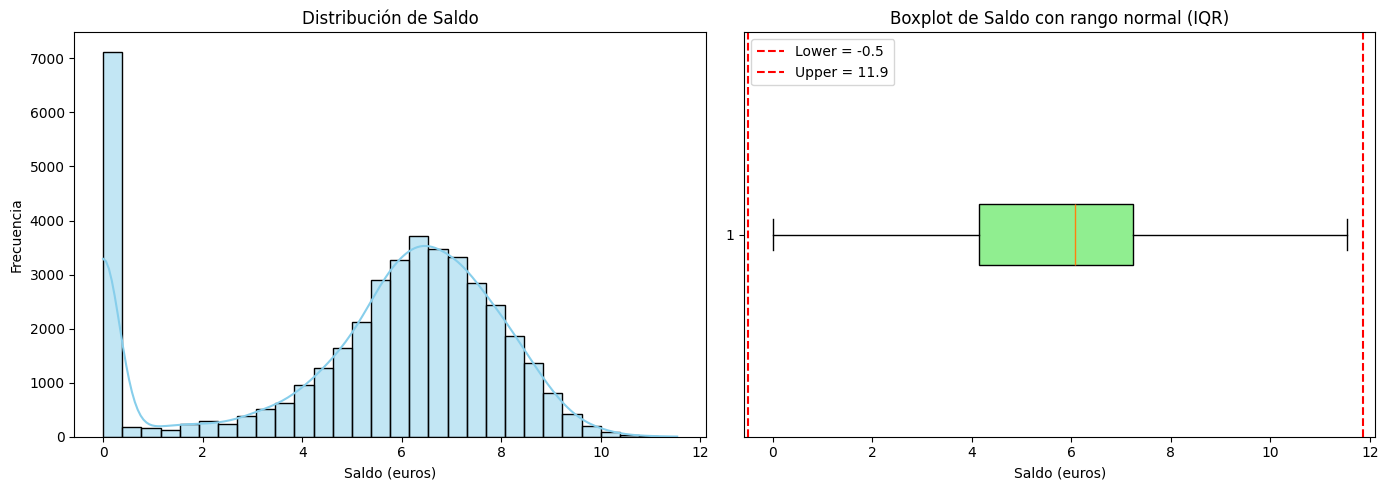

No se detectaron atípicos en saldo según IQR.


In [20]:
# Distribución de saldo y boxplot con rango normal (IQR)

q1 = df['saldo'].quantile(0.25)
q3 = df['saldo'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['saldo'] < lower) | (df['saldo'] > upper)]['saldo']

print(f"Saldo - Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"Rango normal (IQR): {lower:.2f} - {upper:.2f}")
print(f"Atípicos detectados: {len(outliers)}\n")

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histograma + KDE
sns.histplot(df['saldo'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Saldo')
axes[0].set_xlabel('Saldo (euros)')
axes[0].set_ylabel('Frecuencia')

# Boxplot horizontal
axes[1].boxplot(df['saldo'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='black'),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.6))
axes[1].set_title('Boxplot de Saldo con rango normal (IQR)')
axes[1].set_xlabel('Saldo (euros)')

# Líneas verticales para los límites IQR
axes[1].axvline(lower, color='red', linestyle='--', linewidth=1.5, label=f'Lower = {lower:.1f}')
axes[1].axvline(upper, color='red', linestyle='--', linewidth=1.5, label=f'Upper = {upper:.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Mostrar estadísticas de los atípicos
if not outliers.empty:
    print('Estadísticas de atípicos (saldo):')
    print(outliers.describe())
else:
    print('No se detectaron atípicos en saldo según IQR.')

---

## 6. Ingenieria de Caracteristicas

Esta seccion aplica transformaciones a las variables para prepararlas para los modelos de Machine Learning. Los artefactos generados (encoders, scalers) se guardan en la carpeta `archivos_modelo/` para su uso en produccion.

### 6.1 Codificacion Binaria (Label Encoding)

Las variables binarias (si/no) se codifican numericamente usando `LabelEncoder`. Variables afectadas:
- `incumplimiento`: Si el cliente tiene historial de incumplimiento
- `prestamo_vivienda`: Si tiene prestamo de vivienda activo
- `prestamo_consumo`: Si tiene prestamo de consumo activo
- `cdt`: Variable objetivo (si acepto o no el CDT)

**Archivo generado:** `encoders_binarios.joblib`

In [21]:
# Diccionario para almacenar los encoders
encoders = {}

# Variables binarias a codificar
variables_binarias = ['incumplimiento', 'prestamo_vivienda', 'prestamo_consumo', 'cdt']

# Crear y aplicar LabelEncoder a cada variable
for variable in variables_binarias:
    le = LabelEncoder()
    df[variable] = le.fit_transform(df[variable])
    encoders[variable] = le

    # Mostrar el mapeo de clases
    print(f"{variable.upper()}:")
    for i, clase in enumerate(le.classes_):
        print(f"  {clase} -> {i}")
    print()

print("Codificación binaria completada.")
print(f"\nEnconders creados: {list(encoders.keys())}")

INCUMPLIMIENTO:
  no -> 0
  si -> 1

PRESTAMO_VIVIENDA:
  no -> 0
  si -> 1

PRESTAMO_CONSUMO:
  no -> 0
  si -> 1

CDT:
  no -> 0
  si -> 1

Codificación binaria completada.

Enconders creados: ['incumplimiento', 'prestamo_vivienda', 'prestamo_consumo', 'cdt']


In [22]:
# Serializar los encoders con joblib para producción
ruta_encoders = os.path.join(os.getcwd(), 'encoders_binarios.joblib')

joblib.dump(encoders, ruta_encoders)

print(f"Encoders guardados en: {ruta_encoders}")

Encoders guardados en: d:\-CDT-acceptance-test-model-main\archivos_modelo\encoders_binarios.joblib


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42639 entries, 0 to 42638
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   edad               42639 non-null  int64   
 1   empleo             42639 non-null  category
 2   estado_civil       42639 non-null  category
 3   nivel_educativo    42639 non-null  category
 4   incumplimiento     42639 non-null  int64   
 5   saldo              42639 non-null  float64 
 6   prestamo_vivienda  42639 non-null  int64   
 7   prestamo_consumo   42639 non-null  int64   
 8   cdt                42639 non-null  int64   
dtypes: category(3), float64(1), int64(5)
memory usage: 2.1 MB


In [24]:
# Crear instancia del OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Variables categóricas a codificar
variables_categoricas = ['empleo', 'estado_civil', 'nivel_educativo']

# Ajustar y transformar los datos
df_ohe = ohe.fit_transform(df[variables_categoricas])

# Obtener los nombres de las nuevas columnas
feature_names = ohe.get_feature_names_out(variables_categoricas)

# Crear un dataframe con los datos codificados
df_ohe_encoded = pd.DataFrame(df_ohe, columns=feature_names, index=df.index)

# Mostrar información del One Hot Encoder
print("One Hot Encoder aplicado a:")
print(variables_categoricas)
print(f"\nNuevas columnas generadas ({len(feature_names)}):")
print(list(feature_names))
print(f"\nPrimeras filas del resultado:")
print(df_ohe_encoded.head())

One Hot Encoder aplicado a:
['empleo', 'estado_civil', 'nivel_educativo']

Nuevas columnas generadas (19):
['empleo_administrador', 'empleo_autonomo', 'empleo_desconocido', 'empleo_desempleado', 'empleo_empleada_hogar', 'empleo_empresario', 'empleo_estudiante', 'empleo_gestion', 'empleo_jubilado', 'empleo_obrero', 'empleo_servicios', 'empleo_tecnico', 'estado_civil_casado', 'estado_civil_divorciado', 'estado_civil_soltero', 'nivel_educativo_basica', 'nivel_educativo_desconocida', 'nivel_educativo_media', 'nivel_educativo_superior']

Primeras filas del resultado:
   empleo_administrador  empleo_autonomo  empleo_desconocido  \
0                   0.0              0.0                 0.0   
1                   0.0              0.0                 0.0   
2                   0.0              0.0                 0.0   
3                   0.0              0.0                 0.0   
4                   0.0              0.0                 1.0   

   empleo_desempleado  empleo_empleada_hogar  

In [25]:
# Unificar df con df_ohe_encoded
df = pd.concat([df, df_ohe_encoded], axis=1)

# Eliminar las variables categóricas originales
df = df.drop(columns=variables_categoricas)

print("DataFrame unificado:")
print(f"Dimensiones: {df.shape}")
print(f"\nColumnas del DataFrame final:")
print(df.columns.tolist())
print(f"\nPrimeras filas:")
print(df.head())

DataFrame unificado:
Dimensiones: (42639, 25)

Columnas del DataFrame final:
['edad', 'incumplimiento', 'saldo', 'prestamo_vivienda', 'prestamo_consumo', 'cdt', 'empleo_administrador', 'empleo_autonomo', 'empleo_desconocido', 'empleo_desempleado', 'empleo_empleada_hogar', 'empleo_empresario', 'empleo_estudiante', 'empleo_gestion', 'empleo_jubilado', 'empleo_obrero', 'empleo_servicios', 'empleo_tecnico', 'estado_civil_casado', 'estado_civil_divorciado', 'estado_civil_soltero', 'nivel_educativo_basica', 'nivel_educativo_desconocida', 'nivel_educativo_media', 'nivel_educativo_superior']

Primeras filas:
   edad  incumplimiento     saldo  prestamo_vivienda  prestamo_consumo  cdt  \
0    58               0  7.670429                  1                 0    0   
1    44               0  3.401197                  1                 0    0   
2    33               0  1.098612                  1                 1    0   
3    47               0  7.317876                  1                 0    0 

In [26]:
# Serializar el One Hot Encoder con joblib para producción
ruta_ohe = os.path.join(os.getcwd(), 'one_hot_encoder.joblib')

joblib.dump(ohe, ruta_ohe)

print(f"One Hot Encoder guardado en: {ruta_ohe}")
print(f"Tamaño del archivo: {os.path.getsize(ruta_ohe)} bytes")
print(f"\nVariables usadas para codificación: {variables_categoricas}")

One Hot Encoder guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\one_hot_encoder.joblib
Tamaño del archivo: 1616 bytes

Variables usadas para codificación: ['empleo', 'estado_civil', 'nivel_educativo']


### 6.2 Codificacion One-Hot (Variables Categoricas)

Las variables categoricas con multiples categorias se codifican usando `OneHotEncoder`. Se generan columnas binarias para cada categoria. Variables afectadas:
- `empleo`: Tipo de empleo del cliente
- `estado_civil`: Estado civil del cliente
- `nivel_educativo`: Nivel de educacion del cliente

**Archivo generado:** `one_hot_encoder.joblib`

### 6.3 Normalizacion de Variables Numericas (MinMaxScaler)

Las variables numericas se escalan al rango [0, 1] usando `MinMaxScaler` para mejorar la convergencia de los modelos:
- `edad`: Se escala manteniendo la proporcion original
- `saldo`: Se escala manteniendo la proporcion original

**Archivos generados:** `minmax_scaler_edad.joblib`, `minmax_scaler_saldo.joblib`

In [27]:
# Crear instancia del MinMaxScaler
scaler_edad = MinMaxScaler(feature_range=(0, 1))

# Ajustar y transformar la variable edad
# Se necesita reshape porque MinMaxScaler espera un array 2D
edad_escalada = scaler_edad.fit_transform(df[['edad']])

# Reemplazar la columna edad en el dataframe con los valores escalados
df['edad'] = edad_escalada

print("=" * 70)
print("NORMALIZACIÓN DE EDAD CON MINMAXSCALER")
print("=" * 70)

print("\n1. Información del MinMaxScaler:")
print(f"   Rango de escala: {scaler_edad.feature_range}")
print(f"   Valor mínimo original: {scaler_edad.data_min_[0]:.2f}")
print(f"   Valor máximo original: {scaler_edad.data_max_[0]:.2f}")
print(f"   Escala: {scaler_edad.scale_[0]:.6f}")

print(f"\n2. Estadísticas de la edad normalizada:")
print(f"   Mínimo: {df['edad'].min():.6f}")
print(f"   Máximo: {df['edad'].max():.6f}")
print(f"   Media: {df['edad'].mean():.6f}")
print(f"   Mediana: {df['edad'].median():.6f}")

# Serializar el scaler con joblib para producción
ruta_scaler = os.path.join(os.getcwd(), 'minmax_scaler_edad.joblib')

joblib.dump(scaler_edad, ruta_scaler)

print(f"\n3. Serialización del MinMaxScaler:")
print(f"   Archivo guardado en: {ruta_scaler}")
print(f"   Tamaño del archivo: {os.path.getsize(ruta_scaler)} bytes")


print("\n" + "=" * 70)
print("✓ Normalización de edad completada y guardada en joblib")
print("=" * 70)

NORMALIZACIÓN DE EDAD CON MINMAXSCALER

1. Información del MinMaxScaler:
   Rango de escala: (0, 1)
   Valor mínimo original: 18.00
   Valor máximo original: 95.00
   Escala: 0.012987

2. Estadísticas de la edad normalizada:
   Mínimo: 0.000000
   Máximo: 1.000000
   Media: 0.295959
   Mediana: 0.272727

3. Serialización del MinMaxScaler:
   Archivo guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\minmax_scaler_edad.joblib
   Tamaño del archivo: 975 bytes

✓ Normalización de edad completada y guardada en joblib


In [28]:
# Crear instancia del MinMaxScaler
scaler_saldo = MinMaxScaler(feature_range=(0, 1))

# Ajustar y transformar la variable saldo
# Se necesita reshape porque MinMaxScaler espera un array 2D
saldo_escalado = scaler_saldo.fit_transform(df[['saldo']])

# Reemplazar la columna saldo en el dataframe con los valores escalados
df['saldo'] = saldo_escalado

print("=" * 70)
print("NORMALIZACIÓN DE SALDO CON MINMAXSCALER")
print("=" * 70)

print("\n1. Información del MinMaxScaler:")
print(f"   Rango de escala: {scaler_saldo.feature_range}")
print(f"   Valor mínimo original: {scaler_saldo.data_min_[0]:.2f}")
print(f"   Valor máximo original: {scaler_saldo.data_max_[0]:.2f}")
print(f"   Escala: {scaler_saldo.scale_[0]:.6f}")

print(f"\n2. Estadísticas de la edad normalizada:")
print(f"   Mínimo: {df['saldo'].min():.6f}")
print(f"   Máximo: {df['saldo'].max():.6f}")
print(f"   Media: {df['saldo'].mean():.6f}")
print(f"   Mediana: {df['saldo'].median():.6f}")

# Serializar el scaler con joblib para producción
ruta_scaler = os.path.join(os.getcwd(), 'minmax_scaler_saldo.joblib')

joblib.dump(scaler_saldo, ruta_scaler)

print(f"\n3. Serialización del MinMaxScaler:")
print(f"   Archivo guardado en: {ruta_scaler}")
print(f"   Tamaño del archivo: {os.path.getsize(ruta_scaler)} bytes")


print("\n" + "=" * 70)
print("✓ Normalización de saldo completada y guardada en joblib")
print("=" * 70)

NORMALIZACIÓN DE SALDO CON MINMAXSCALER

1. Información del MinMaxScaler:
   Rango de escala: (0, 1)
   Valor mínimo original: 0.00
   Valor máximo original: 11.53
   Escala: 0.086700

2. Estadísticas de la edad normalizada:
   Mínimo: 0.000000
   Máximo: 1.000000
   Media: 0.455598
   Mediana: 0.525732

3. Serialización del MinMaxScaler:
   Archivo guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\minmax_scaler_saldo.joblib
   Tamaño del archivo: 975 bytes

✓ Normalización de saldo completada y guardada en joblib


### 6.4 Creacion de Quintiles

Se crean variables de quintiles para segmentar la edad en grupos. Los quintiles permiten capturar relaciones no lineales entre la edad y la variable objetivo.

**Archivos generados:** `quintiles_generador.joblib`, `one_hot_encoder_quintiles.joblib`

In [29]:
df['norm_cant_productos'] = (df['prestamo_vivienda'] + df['prestamo_consumo'])/2
df['edad_saldo'] = (df['edad'] + df['saldo'])/2

In [30]:
# Crear copia del dataframe para trabajar
df_quintiles = df.copy()

# Crear quintiles de edad
# Como edad ya está normalizada (0-1), la usamos directamente
df_quintiles['quintil_edad'] = pd.qcut(df_quintiles['edad'],
                                        q=5,
                                        labels=['Q1_Edad_Muy_Bajo', 'Q2_Edad_Bajo',
                                               'Q3_Edad_Medio', 'Q4_Edad_Alto',
                                               'Q5_Edad_Muy_Alto'],
                                        duplicates='drop')

# Crear quintiles de saldo
# Como saldo ya está normalizado (0-1), la usamos directamente
df_quintiles['quintil_saldo'] = pd.qcut(df_quintiles['saldo'],
                                        q=5,
                                        labels=['Q1_Saldo_Muy_Bajo', 'Q2_Saldo_Bajo',
                                               'Q3_Saldo_Medio', 'Q4_Saldo_Alto',
                                               'Q5_Saldo_Muy_Alto'],
                                        duplicates='drop')

# Guardar los quintiles como transformadores en un diccionario
# Para reproducir en producción, necesitamos los puntos de corte
quintiles_info = {
    'edad_bins': pd.qcut(df['edad'], q=5, duplicates='drop', retbins=True)[1].tolist(),
    'saldo_bins': pd.qcut(df['saldo'], q=5, duplicates='drop', retbins=True)[1].tolist(),
    'edad_labels': ['Q1_Edad_Muy_Bajo', 'Q2_Edad_Bajo', 'Q3_Edad_Medio',
                   'Q4_Edad_Alto', 'Q5_Edad_Muy_Alto'],
    'saldo_labels': ['Q1_Saldo_Muy_Bajo', 'Q2_Saldo_Bajo', 'Q3_Saldo_Medio',
                    'Q4_Saldo_Alto', 'Q5_Saldo_Muy_Alto']
}

# Serializar los quintiles
ruta_quintiles = os.path.join(os.getcwd(), 'quintiles_generador.joblib')
joblib.dump(quintiles_info, ruta_quintiles)

print(f"   Serialización de Quintiles:")
print(f"   Archivo guardado en: {ruta_quintiles}")
print(f"   Tamaño del archivo: {os.path.getsize(ruta_quintiles)} bytes")


   Serialización de Quintiles:
   Archivo guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\quintiles_generador.joblib
   Tamaño del archivo: 367 bytes


In [31]:
# Crear instancia del OneHotEncoder para quintiles
ohe_quintiles = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Variables a codificar
variables_quintiles = ['quintil_edad']

# Ajustar y transformar
quintiles_ohe = ohe_quintiles.fit_transform(df_quintiles[variables_quintiles])

# Obtener nombres de características
quintiles_feature_names = ohe_quintiles.get_feature_names_out(variables_quintiles)

# Crear dataframe con las características codificadas
df_quintiles_encoded = pd.DataFrame(quintiles_ohe,
                                   columns=quintiles_feature_names,
                                   index=df_quintiles.index)

ruta_ohe_quintiles = os.path.join(os.getcwd(), 'one_hot_encoder_quintiles.joblib')
joblib.dump(ohe_quintiles, ruta_ohe_quintiles)

print(f"   Serialización del OneHotEncoder (Quintiles):")
print(f"   Archivo guardado en: {ruta_ohe_quintiles}")
print(f"   Tamaño del archivo: {os.path.getsize(ruta_ohe_quintiles)} bytes")

   Serialización del OneHotEncoder (Quintiles):
   Archivo guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\one_hot_encoder_quintiles.joblib
   Tamaño del archivo: 1056 bytes


In [32]:
# Agregar las columnas de quintiles al dataframe original
df = pd.concat([df, df_quintiles_encoded], axis=1)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42639 entries, 0 to 42638
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   edad                           42639 non-null  float64
 1   incumplimiento                 42639 non-null  int64  
 2   saldo                          42639 non-null  float64
 3   prestamo_vivienda              42639 non-null  int64  
 4   prestamo_consumo               42639 non-null  int64  
 5   cdt                            42639 non-null  int64  
 6   empleo_administrador           42639 non-null  float64
 7   empleo_autonomo                42639 non-null  float64
 8   empleo_desconocido             42639 non-null  float64
 9   empleo_desempleado             42639 non-null  float64
 10  empleo_empleada_hogar          42639 non-null  float64
 11  empleo_empresario              42639 non-null  float64
 12  empleo_estudiante              42639 non-null 

### 6.5 Creacion de Variables de Interaccion

Se crean nuevas variables que combinan informacion de multiples variables existentes para capturar efectos de interaccion.

In [34]:
# Calcular la matriz de correlación
correlation_matrix = df.corr()

# Revisar las variables que tengan más de un 50% de correlación con cdt
high_correlation_vars = correlation_matrix[abs(correlation_matrix['cdt']) > 0.5].index

# Mostrar las variables con alta correlación diferentes a cdt
print("Variables con alta correlación (> 0.5) con cdt:")
cant_corr = 0
for var in high_correlation_vars:
    if var != 'cdt':
        print(f" - {var} (correlación: {correlation_matrix.loc[var, 'cdt']:.2f})")
        cant_corr += 1
if cant_corr == 0:
    print("No hay variables con correlación mayor a 0.5 con cdt.")

Variables con alta correlación (> 0.5) con cdt:
No hay variables con correlación mayor a 0.5 con cdt.


### 6.6 Analisis de Correlaciones

Se calcula la matriz de correlacion para identificar variables altamente correlacionadas (|r| > 0.7) que podrian causar multicolinealidad en los modelos.

In [35]:
# Calcular la matriz de correlación
correlation_matrix = df.corr()
umbral_seleccionado = 0.7

# Identificar pares de variables con correlación mayor a 0.5 (excluyendo la correlación consigo misma)
high_correlation_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)): # Para evitar duplicados y auto-correlación
        col1 = correlation_matrix.columns[i]
        col2 = correlation_matrix.columns[j]
        correlation_value = correlation_matrix.iloc[i, j]

        if abs(correlation_value) > umbral_seleccionado:
            high_correlation_pairs.append((col1, col2, correlation_value))

# Mostrar los pares de alta correlación
if high_correlation_pairs:
    print("Pares de variables con correlación absoluta > 0.7:")
    for col1, col2, corr_val in high_correlation_pairs:
        print(f"  - {col1} y {col2}: {corr_val:.4f}")
else:
    print("No se encontraron pares de variables con correlación absoluta superior a 0.7.")

Pares de variables con correlación absoluta > 0.7:
  - edad y quintil_edad_Q5_Edad_Muy_Alto: 0.7623
  - saldo y edad_saldo: 0.8862
  - prestamo_vivienda y norm_cant_productos: 0.8042
  - estado_civil_casado y estado_civil_soltero: -0.7685


**Resultado del Analisis de Correlaciones:**

En general, son pocas las variables con correlacion alta. Se conservan todas las variables considerando que:
- Las variables de quintil (`quintil_edad_Q5_Edad_Muy_Alto`, `norm_cant_productos`) tienen valor predictivo
- Las variables `estado_civil_casado` y `estado_civil_soltero` no tienen correlacion perfecta debido a la existencia de `estado_civil_divorciado`

---

## 7. Modelacion

Esta seccion contiene el proceso de entrenamiento y evaluacion de modelos de clasificacion para predecir la aceptacion de CDT. Se entrenan 7 modelos individuales y 1 modelo de ensamble.

### 7.1 Analisis de Information Value (IV)

El Information Value (IV) es una metrica que mide el poder predictivo de cada variable respecto a la variable objetivo. Permite identificar variables con bajo poder predictivo que pueden ser eliminadas.

**Interpretacion del IV:**
| Rango IV | Interpretacion |
|----------|----------------|
| < 0.02 | Sin poder predictivo |
| 0.02 - 0.10 | Poder predictivo debil |
| 0.10 - 0.30 | Poder predictivo medio |
| 0.30 - 0.50 | Poder predictivo fuerte |
| > 0.50 | Sospechosamente fuerte (posible fuga de datos) |

In [36]:
def calculate_woe_iv(df_input, feature, target):
    """
    Calculates Weight of Evidence (WOE) and Information Value (IV) for a given feature.

    Args:
        df_input (pd.DataFrame): The input DataFrame.
        feature (str): The name of the feature column.
        target (str): The name of the target column (binary, 0 or 1).

    Returns:
        dict: A dictionary containing the IV and a DataFrame with WOE and other stats.
    """
    df_woe_iv = df_input.groupby(feature)[target].agg(
        total= 'count',
        bad=lambda x: (x == 1).sum(),
        good=lambda x: (x == 0).sum()
    ).reset_index()

    # Calculate percentages, handling cases where good/bad count might be zero
    df_woe_iv['percent_bad'] = df_woe_iv['bad'] / df_woe_iv['bad'].sum()
    df_woe_iv['percent_good'] = df_woe_iv['good'] / df_woe_iv['good'].sum()

    # Replace 0 with a small epsilon to avoid division by zero or log(0)
    df_woe_iv['percent_bad'] = df_woe_iv['percent_bad'].replace(0, 0.000001)
    df_woe_iv['percent_good'] = df_woe_iv['percent_good'].replace(0, 0.000001)

    df_woe_iv['WOE'] = np.log(df_woe_iv['percent_good'] / df_woe_iv['percent_bad'])
    df_woe_iv['IV'] = (df_woe_iv['percent_good'] - df_woe_iv['percent_bad']) * df_woe_iv['WOE']

    total_iv = df_woe_iv['IV'].sum()

    return {'IV': total_iv, 'WOE_Table': df_woe_iv}

In [37]:
# Target variable
target_variable = 'cdt'

# Use df_encoded for feature selection for IV calculation
df_base_for_iv = df.copy()

# Get all feature columns (excluding the target)
all_features = [col for col in df_base_for_iv.columns if col != target_variable]

# Separate features into numerical and categorical for IV calculation
numerical_features = []
categorical_features = []

for col in all_features:
    # Heuristic: if a numerical column has more than 10 unique values, treat as continuous numerical (to be binned)
    # Otherwise, treat as categorical (includes actual category dtypes and low-cardinality numericals like 0/1)
    if df_base_for_iv[col].dtype in ['int64', 'float64'] and df_base_for_iv[col].nunique() > 10:
        numerical_features.append(col)
    else:
        categorical_features.append(col)

# Store IV results
iv_results = {}

print("Calculando IV para variables categóricas (incluyendo one-hot-encoded)...")
for feature in categorical_features:
    iv_calc = calculate_woe_iv(df_base_for_iv, feature, target_variable)
    iv_results[feature] = iv_calc['IV']

print("\nCalculando IV para variables numéricas (binnear por cuantiles)...")
for feature in numerical_features:
    df_temp = df_base_for_iv.copy()
    try:
        # Bin numerical features using quantiles (5 bins), handling duplicates
        df_temp[f'{feature}_binned'] = pd.qcut(df_temp[feature], q=5, duplicates='drop')
        iv_calc = calculate_woe_iv(df_temp, f'{feature}_binned', target_variable)
        iv_results[feature] = iv_calc['IV']
    except Exception as e:
        print(f"  - Advertencia: No se pudo binnear la característica '{feature}'. Error: {e}")
        print(f"  - Saltando el cálculo de IV para '{feature}' debido a un error de binning.")

# Sort IV results
sorted_iv_results = sorted(iv_results.items(), key=lambda item: item[1], reverse=True)

print("\n--- Resultados de Information Value (IV) para df_encoded ---")
iv_df_encoded = pd.DataFrame(sorted_iv_results, columns=['Feature', 'IV']) # Store in a new var
display(iv_df_encoded)

print("\n--- Interpretación de los valores de IV ---")
print("IV < 0.02: No tiene poder predictivo (Pobre)")
print("0.02 <= IV < 0.1: Poder predictivo débil (Débil)")
print("0.1 <= IV < 0.3: Poder predictivo medio (Medio)")
print("0.3 <= IV < 0.5: Poder predictivo fuerte (Fuerte)")
print("IV >= 0.5: Poder predictivo sospechosamente fuerte (Sospechoso)")

Calculando IV para variables categóricas (incluyendo one-hot-encoded)...

Calculando IV para variables numéricas (binnear por cuantiles)...

--- Resultados de Information Value (IV) para df_encoded ---


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31972\2903426970.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_woe_iv = df_input.groupby(feature)[target].agg(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_31972\2903426970.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_woe_iv = df_input.groupby(feature)[target].agg(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_31972\2903426970.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default an

,Feature,IV
0,norm_cant_productos,0.154595
1,prestamo_vivienda,0.116954
2,saldo,0.078063
3,edad_saldo,0.048052
4,empleo_obrero,0.038359
5,nivel_educativo_superior,0.037951
6,estado_civil_casado,0.036410
7,edad,0.035924
8,prestamo_consumo,0.035259
9,estado_civil_soltero,0.031902



--- Interpretación de los valores de IV ---
IV < 0.02: No tiene poder predictivo (Pobre)
0.02 <= IV < 0.1: Poder predictivo débil (Débil)
0.1 <= IV < 0.3: Poder predictivo medio (Medio)
0.3 <= IV < 0.5: Poder predictivo fuerte (Fuerte)
IV >= 0.5: Poder predictivo sospechosamente fuerte (Sospechoso)


In [38]:
low_iv_features = iv_df_encoded[iv_df_encoded['IV'] < 0.01]['Feature'].tolist()

print(f"Las variables a eliminar en las iteraciones son:")
for i in low_iv_features:
    print(f"  {i}")

Las variables a eliminar en las iteraciones son:
  empleo_gestion
  quintil_edad_Q3_Edad_Medio
  empleo_servicios
  quintil_edad_Q5_Edad_Muy_Alto
  incumplimiento
  empleo_empleada_hogar
  empleo_empresario
  empleo_desempleado
  quintil_edad_Q2_Edad_Bajo
  estado_civil_divorciado
  empleo_tecnico
  empleo_administrador
  empleo_autonomo
  nivel_educativo_desconocida
  empleo_desconocido


In [39]:
# Eliminar las variables en low_iv_features
df = df.drop(columns=low_iv_features)

### 7.2 Division de Datos (Train-Test Split)

Se divide el dataset en conjuntos de entrenamiento (70%) y prueba (30%). Se utiliza estratificacion para mantener la proporcion de clases en ambos conjuntos.

| Conjunto | Porcentaje | Uso |
|----------|------------|-----|
| Entrenamiento | 70% | Entrenar los modelos |
| Prueba | 30% | Evaluar rendimiento final |

In [40]:
# División Train-Test 70% - 30%
print("=" * 90)
print("DIVISIÓN TRAIN-TEST 70% - 30%")
print("=" * 90)

# Separar características (X) de la variable objetivo (y)
X = df.drop('cdt', axis=1)
y = df['cdt']

print(f"\nDataframe original: {df.shape}")
print(f"  - Características (X): {X.shape}")
print(f"  - Variable objetivo (y): {y.shape}")

# Realizar la división train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"\nDivisión realizada:")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_test:  {X_test.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_test:  {y_test.shape}")

# Verificar proporciones
print(f"\nVerificación de proporciones:")
print(f"  - Entrenamiento: {X_train.shape[0] / df.shape[0] * 100:.2f}% ({X_train.shape[0]} registros)")
print(f"  - Validación:    {X_test.shape[0] / df.shape[0] * 100:.2f}% ({X_test.shape[0]} registros)")

# Verificar distribución de clases en ambos conjuntos
print(f"\nDistribución de la variable objetivo:")
print(f"\n  Conjunto de Entrenamiento (y_train):")
print(f"    {y_train.value_counts().to_string()}")
print(f"\n  Conjunto de Validación (y_test):")
print(f"    {y_test.value_counts().to_string()}")

print("\n" + "=" * 90)

DIVISIÓN TRAIN-TEST 70% - 30%

Dataframe original: (42639, 17)
  - Características (X): (42639, 16)
  - Variable objetivo (y): (42639,)

División realizada:
  - X_train: (29847, 16)
  - X_test:  (12792, 16)
  - y_train: (29847,)
  - y_test:  (12792,)

Verificación de proporciones:
  - Entrenamiento: 70.00% (29847 registros)
  - Validación:    30.00% (12792 registros)

Distribución de la variable objetivo:

  Conjunto de Entrenamiento (y_train):
    cdt
0    27074
1     2773

  Conjunto de Validación (y_test):
    cdt
0    11604
1     1188



---

## 8. Entrenamiento de Modelos

Se entrenan 7 modelos de clasificacion diferentes, cada uno con hiperparametros optimizados, y posteriormente un modelo de ensamble que combina las predicciones de todos.

### Resumen de Modelos

| Modelo | Algoritmo | Descripcion |
|--------|-----------|-------------|
| 1 | Regresion Logistica | Modelo lineal para clasificacion binaria |
| 2 | K-Nearest Neighbors (KNN) | Clasificacion basada en vecinos mas cercanos |
| 3 | Support Vector Machine (SVM) | Clasificacion mediante hiperplanos |
| 4 | Decision Tree | Arbol de decision |
| 5 | Neural Network (MLP) | Red neuronal multicapa |
| 6 | Random Forest | Ensamble de arboles de decision |
| 7 | LightGBM | Gradient Boosting optimizado |
| 8 | Voting Ensemble | Combinacion de todos los modelos anteriores |

### Carga de Librerias Adicionales para Modelos

La siguiente celda importa las clases de sklearn necesarias para entrenar todos los modelos de clasificacion.

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score, confusion_matrix
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score


### Modelo 1: Regresion Logistica

La celda siguiente contiene el codigo y resultados de RandomizedSearchCV.

MODELO 1: REGRESIÓN LOGÍSTICA CON RANDOMIZEDSEARCHCV

Ejecutando RandomizedSearchCV para Regresión Logística...
   - Número de iteraciones: 4000
   - CV folds: 10
   - Scoring: roc_auc
   - n_jobs: -1 (usar todos los procesadores disponibles)

✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - warm_start: False
      - tol: 0.0001
      - solver: saga
      - random_state: 42
      - penalty: l1
      - max_iter: 2000
      - l1_ratio: 0.4
      - fit_intercept: False
      - dual: False
      - class_weight: balanced
      - C: 0.1

   Mejor AUC-ROC CV (10-fold): 0.6569

   Buscando umbral óptimo que maximice F1 Score...
   Probando 99 umbrales diferentes...

   ✓ UMBRAL ÓPTIMO ENCONTRADO
      Umbral: 0.61
      F1 Score máximo: 0.2344


MÉTRICAS DE EVALUACIÓN - REGRESIÓN LOGÍSTICA - CONJUNTO TEST

Matriz de Confusión - Test - Detalles:
   Verdaderos Negativos (TN):    9937
   Falsos Positivos (FP):        1667
   Falsos Negativos (FN):         809
   Verdaderos Positivos (TP):     379

Métricas de Rendimiento - Test:
   Precisión (Precision):      0.1852  (TP / (TP + FP))
   Sensibilidad (Recall):      0.3190  (TP / (TP + FN))
   Especificidad (Specificity):0.8563  (TN / (TN + FP))
   F1 Score:                   0.2344  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.8064  ((TP + TN) / Total)
   AUC-ROC:                    0.6343


EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST

MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO

Matriz de Confusión - Train - Detalles:
   Verdaderos Negativos (TN):   23312
   Falsos Positivos (FP):        3762
   Falsos Negativos (FN):        1842
   Verdaderos Positivos (TP):     931

Métricas de Rendimiento - Train:
   Precisión (Precision):      0.1984  (TP / (TP + FP))
   Sensibilidad (Recall):      0.3357  (TP / (TP + FN))
   Especificidad (Specificity):0.8610  (TN / (TN + FP))
   F1 Score:                   0.2494  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.8122  ((TP + TN) / Total)
   AUC-ROC:                    0.6587


ANÁLISIS COMPARATIVO: TRAIN vs TEST

Comparación de Métricas:
              Métrica    Train     Test  Diferencia  % Diferencia
            Precisión 0.198381 0.185239    0.013141      7.094100
Sensibilidad (Recall) 0.335737 0.319024    0.016714      5.239080
        Especificidad 0.861047 0.856343    0.004705      0.549413
             F1 Score 0.249397 0.234385    0.015013      6.405114
 Exactitud (Accuracy) 0.812242 0.806442    0.005801      0.719322
              AUC-ROC 0.658657 0.634274    0.024383      3.844285


CRITERIO DE SOBREAJUSTE:
Diferencia significativa (> 0.05): Posible sobreajuste
Diferencia leve (0.02 - 0.05): Ligero sobreajuste
Diferencia mínima (< 0.02): Modelo bien calibrado

INDICES DE SOBREAJUSTE:
   Precisión                 | Diferencia:  0.0131 | Nivel: MÍNIMO
   Sensibilidad (Recall)     | Diferencia:  0.0167 | Nivel: MÍNIMO
   Especificidad             | Diferencia:  0.0047 | Nivel: MÍNIMO
   F1 Score                  | Diferencia:  0.0150 | Nivel: MÍNIMO
   Exactitud (Accuracy)      | Diferencia:  0.0058 | Nivel: MÍNIMO
   AUC-ROC                   | Diferencia:  0.0244 | Nivel: LEVE

Diferencia Promedio: 0.0133
CONCLUSIÓN: Modelo bien generalizado (sin sobreajuste evidente)

MODELO 1: REGRESIÓN LOGÍSTICA CON RANDOMIZEDSEARCHCV

Ejecutando RandomizedSearchCV para Regresión Logística...
   - Número de iteraciones: 4000
   - CV folds: 10
   - Scoring: roc_auc
   - n_jobs: -1 (usar todos los procesadores disponibles)



c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
18820 fits failed out of a total of 40000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2630 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\User

✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - warm_start: False
      - tol: 0.0001
      - solver: saga
      - random_state: 42
      - penalty: l1
      - max_iter: 2000
      - l1_ratio: 0.4
      - fit_intercept: False
      - dual: False
      - class_weight: balanced
      - C: 0.1

   Mejor AUC-ROC CV (10-fold): 0.6569

   Buscando umbral óptimo que maximice F1 Score...
   Probando 99 umbrales diferentes...

   ✓ UMBRAL ÓPTIMO ENCONTRADO
      Umbral: 0.61
      F1 Score máximo: 0.2344

   Top 10 umbrales según F1 Score:


,Umbral,F1_Score
60,0.61,0.234385
59,0.60,0.232288
62,0.63,0.230247
58,0.59,0.229854
61,0.62,0.228094
57,0.58,0.226673
63,0.64,0.225277
55,0.56,0.223073
56,0.57,0.223022
54,0.55,0.222505



   Predicciones guardadas en dataframe (12792 registros)
   Umbral aplicado a todas las predicciones: 0.61
   Primeras 5 predicciones:


,ID,y_actual,y_pred,y_pred_proba,umbral_aplicado
0,0,1,0,0.586839,0.61
1,1,0,0,0.390875,0.61
2,2,0,0,0.496016,0.61
3,3,0,0,0.577532,0.61
4,4,0,1,0.611883,0.61


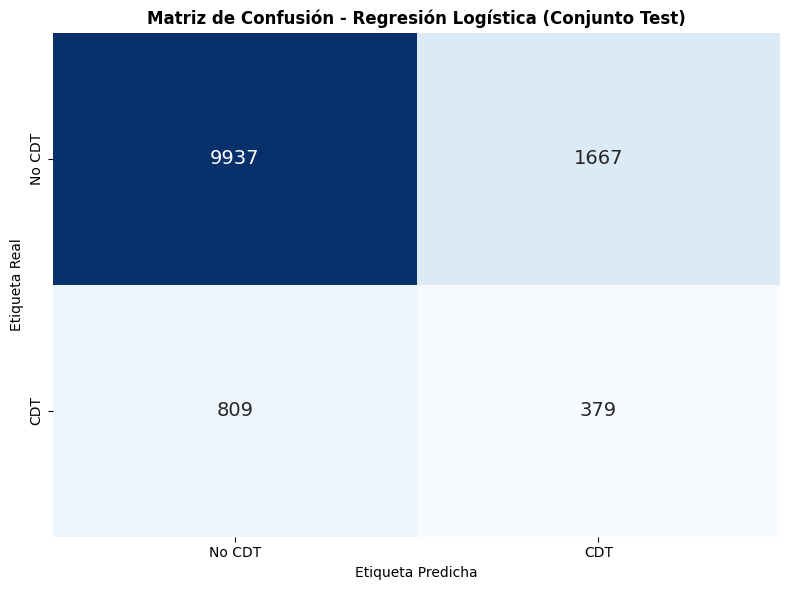


MÉTRICAS DE EVALUACIÓN - REGRESIÓN LOGÍSTICA - CONJUNTO TEST

Matriz de Confusión - Test - Detalles:
   Verdaderos Negativos (TN):    9937
   Falsos Positivos (FP):        1667
   Falsos Negativos (FN):         809
   Verdaderos Positivos (TP):     379

Métricas de Rendimiento - Test:
   Precisión (Precision):      0.1852  (TP / (TP + FP))
   Sensibilidad (Recall):      0.3190  (TP / (TP + FN))
   Especificidad (Specificity):0.8563  (TN / (TN + FP))
   F1 Score:                   0.2344  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.8064  ((TP + TN) / Total)
   AUC-ROC:                    0.6343


EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST

MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO

Matriz de Confusión - Train - Detalles:
   Verdaderos Negativos (TN):   23312
   Falsos Positivos (FP):        3762
   Falsos Negativos (FN):        1842
   Verdaderos Positivos (TP):     931

Métricas de Rendimiento - Train:
   Precisión (Precision):      0.1984  

In [46]:
###################################################
## Modelo 1: Regresión Logística
###################################################

print("=" * 100)
print("MODELO 1: REGRESIÓN LOGÍSTICA CON RANDOMIZEDSEARCHCV")
print("=" * 100)

# Definir grid de hiperparámetros para Regresión Logística
param_grid_lr = {
    'random_state': [42],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'l1_ratio': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'C': [0.001, 0.01, 0.1, 0.2, 0.5, 1, 10],
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga'],
    'max_iter': [500, 1000, 1500, 2000],
    'class_weight': ['balanced', None],
    'warm_start': [False],
    'fit_intercept': [False],
    'tol': [0.0001],
    'dual': [False]
}


# Crear instancia de Regresión Logística
lr_model = LogisticRegression(verbose=0)

# Crear RandomizedSearchCV
print("\nEjecutando RandomizedSearchCV para Regresión Logística...")
print("   - Número de iteraciones: 4000")
print("   - CV folds: 10")
print("   - Scoring: roc_auc")
print("   - n_jobs: -1 (usar todos los procesadores disponibles)\n")

rs_lr = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=param_grid_lr,
    n_iter=4000,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

# Entrenar el modelo
rs_lr.fit(X_train, y_train)

print(f"✓ RandomizedSearchCV completado")
print(f"\n   Mejores parámetros encontrados:")
for param, value in rs_lr.best_params_.items():
    print(f"      - {param}: {value}")

print(f"\n   Mejor AUC-ROC CV (10-fold): {rs_lr.best_score_:.4f}")

# ============================================================================
# BÚSQUEDA DE UMBRAL ÓPTIMO BASADO EN F1 SCORE
# ============================================================================
from sklearn.metrics import f1_score as f1_score_metric

# Obtener probabilidades predichas
y_pred_proba_lr = rs_lr.predict_proba(X_test)[:, 1]

# Definir rango de umbrales a probar
thresholds = np.arange(0.01, 1.00, 0.01)
f1_scores = []
threshold_results = []

print("\n   Buscando umbral óptimo que maximice F1 Score...")
print("   Probando " + str(len(thresholds)) + " umbrales diferentes...")

for threshold in thresholds:
    # Aplicar umbral manualmente
    y_pred_temp = (y_pred_proba_lr >= threshold).astype(int)
    
    # Calcular F1 score
    f1_temp = f1_score_metric(y_test, y_pred_temp)
    f1_scores.append(f1_temp)
    
    threshold_results.append({
        'Umbral': threshold,
        'F1_Score': f1_temp
    })

# Encontrar el umbral óptimo
df_thresholds = pd.DataFrame(threshold_results)
optimal_idx = df_thresholds['F1_Score'].idxmax()
optimal_threshold = df_thresholds.loc[optimal_idx, 'Umbral']
optimal_f1 = df_thresholds.loc[optimal_idx, 'F1_Score']

print(f"\n   ✓ UMBRAL ÓPTIMO ENCONTRADO")
print(f"      Umbral: {optimal_threshold:.2f}")
print(f"      F1 Score máximo: {optimal_f1:.4f}")

# Aplicar el umbral óptimo para obtener predicciones finales
y_pred_lr = (y_pred_proba_lr >= optimal_threshold).astype(int)

# Mostrar los 10 mejores umbrales
print(f"\n   Top 10 umbrales según F1 Score:")
top_thresholds = df_thresholds.nlargest(10, 'F1_Score')
display(top_thresholds)

# Guardar predicciones en dataframe
df_predictions_lr = pd.DataFrame({
    'ID': range(len(y_test)),
    'y_actual': y_test.values,
    'y_pred': y_pred_lr,
    'y_pred_proba': y_pred_proba_lr,
    'umbral_aplicado': optimal_threshold
})

print(f"\n   Predicciones guardadas en dataframe ({len(df_predictions_lr)} registros)")
print(f"   Umbral aplicado a todas las predicciones: {optimal_threshold:.2f}")
print(f"   Primeras 5 predicciones:")
display(df_predictions_lr.head())

# ============================================================================
# MATRIZ DE CONFUSIÓN
# ============================================================================
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['No CDT', 'CDT'], yticklabels=['No CDT', 'CDT'],
            ax=ax, annot_kws={'size': 14})
ax.set_title('Matriz de Confusión - Regresión Logística (Conjunto Test)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Etiqueta Real')
ax.set_xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

# ============================================================================
# CÁLCULO DE MÉTRICAS
# ============================================================================
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

tn, fp, fn, tp = cm_lr.ravel()

precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
auc = roc_auc_score(y_test, y_pred_proba_lr)

# Calcular adicionales
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\n" + "=" * 100)
print("MÉTRICAS DE EVALUACIÓN - REGRESIÓN LOGÍSTICA - CONJUNTO TEST")
print("=" * 100)

print("\nMatriz de Confusión - Test - Detalles:")
print(f"   Verdaderos Negativos (TN):  {tn:>6}")
print(f"   Falsos Positivos (FP):      {fp:>6}")
print(f"   Falsos Negativos (FN):      {fn:>6}")
print(f"   Verdaderos Positivos (TP):  {tp:>6}")

print("\nMétricas de Rendimiento - Test:")
print(f"   Precisión (Precision):      {precision:.4f}  (TP / (TP + FP))")
print(f"   Sensibilidad (Recall):      {recall:.4f}  (TP / (TP + FN))")
print(f"   Especificidad (Specificity):{specificity:.4f}  (TN / (TN + FP))")
print(f"   F1 Score:                   {f1:.4f}  (2 * Precision * Recall / (Precision + Recall))")
print(f"   Exactitud (Accuracy):       {accuracy:.4f}  ((TP + TN) / Total)")
print(f"   AUC-ROC:                    {auc:.4f}")

# ============================================================================
# MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO - DETECCIÓN DE SOBREAJUSTE
# ============================================================================
print("\n\n" + "=" * 100)
print("EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST")
print("=" * 100)

# Obtener predicciones en conjunto de entrenamiento
y_pred_proba_train_lr = rs_lr.predict_proba(X_train)[:, 1]
y_pred_train_lr = (y_pred_proba_train_lr >= optimal_threshold).astype(int)

# Calcular métricas en conjunto de entrenamiento
cm_train_lr = confusion_matrix(y_train, y_pred_train_lr)
tn_train, fp_train, fn_train, tp_train = cm_train_lr.ravel()

precision_train = precision_score(y_train, y_pred_train_lr)
recall_train = recall_score(y_train, y_pred_train_lr)
f1_train = f1_score(y_train, y_pred_train_lr)
auc_train = roc_auc_score(y_train, y_pred_proba_train_lr)

specificity_train = tn_train / (tn_train + fp_train) if (tn_train + fp_train) > 0 else 0
sensitivity_train = tp_train / (tp_train + fn_train) if (tp_train + fn_train) > 0 else 0
accuracy_train = (tp_train + tn_train) / (tp_train + tn_train + fp_train + fn_train)

print("\n" + "=" * 100)
print("MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO")
print("=" * 100)

print("\nMatriz de Confusión - Train - Detalles:")
print(f"   Verdaderos Negativos (TN):  {tn_train:>6}")
print(f"   Falsos Positivos (FP):      {fp_train:>6}")
print(f"   Falsos Negativos (FN):      {fn_train:>6}")
print(f"   Verdaderos Positivos (TP):  {tp_train:>6}")

print("\nMétricas de Rendimiento - Train:")
print(f"   Precisión (Precision):      {precision_train:.4f}  (TP / (TP + FP))")
print(f"   Sensibilidad (Recall):      {recall_train:.4f}  (TP / (TP + FN))")
print(f"   Especificidad (Specificity):{specificity_train:.4f}  (TN / (TN + FP))")
print(f"   F1 Score:                   {f1_train:.4f}  (2 * Precision * Recall / (Precision + Recall))")
print(f"   Exactitud (Accuracy):       {accuracy_train:.4f}  ((TP + TN) / Total)")
print(f"   AUC-ROC:                    {auc_train:.4f}")

# ============================================================================
# COMPARACIÓN Y ANÁLISIS DE SOBREAJUSTE
# ============================================================================
print("\n\n" + "=" * 100)
print("ANÁLISIS COMPARATIVO: TRAIN vs TEST")
print("=" * 100)

# Crear dataframe de comparación
df_comparison = pd.DataFrame({
    'Métrica': ['Precisión', 'Sensibilidad (Recall)', 'Especificidad', 'F1 Score', 
                'Exactitud (Accuracy)', 'AUC-ROC'],
    'Train': [precision_train, recall_train, specificity_train, f1_train, accuracy_train, auc_train],
    'Test': [precision, recall, specificity, f1, accuracy, auc],
})

# Calcular diferencia y porcentaje de diferencia
df_comparison['Diferencia'] = df_comparison['Train'] - df_comparison['Test']
df_comparison['% Diferencia'] = (df_comparison['Diferencia'] / df_comparison['Test'].abs()) * 100

print("\nComparación de Métricas:")
print(df_comparison.to_string(index=False))

# Análisis de sobreajuste
print("\n\nCRITERIO DE SOBREAJUSTE:")
print("Diferencia significativa (> 0.05): Posible sobreajuste")
print("Diferencia leve (0.02 - 0.05): Ligero sobreajuste")
print("Diferencia mínima (< 0.02): Modelo bien calibrado")

print("\nINDICES DE SOBREAJUSTE:")
for idx, row in df_comparison.iterrows():
    diff = row['Diferencia']
    if abs(diff) > 0.05:
        nivel = "ALTO"
    elif abs(diff) > 0.02:
        nivel = "LEVE"
    else:
        nivel = "MÍNIMO"
    print(f"   {row['Métrica']:<25} | Diferencia: {diff:>7.4f} | Nivel: {nivel}")

# Resumen general
avg_diff = df_comparison['Diferencia'].abs().mean()
print(f"\nDiferencia Promedio: {avg_diff:.4f}")

if avg_diff > 0.05:
    print("CONCLUSIÓN: Modelo con SOBREAJUSTE significativo")
elif avg_diff > 0.02:
    print("CONCLUSIÓN: Modelo con ligero sobreajuste")
else:
    print("CONCLUSIÓN: Modelo bien generalizado (sin sobreajuste evidente)")


### Modelo 2: K-Nearest Neighbors (KNN) - Busqueda de Hiperparametros

La celda siguiente contiene el codigo y resultados de RandomizedSearchCV.

MODELO 2: K-NEAREST NEIGHBORS CON RANDOMIZEDSEARCHCV

Ejecutando RandomizedSearchCV para KNN...
   - Número de iteraciones: 1000
   - CV folds: 10
   - Scoring: roc_auc
   - n_jobs: -1 (usar todos los procesadores disponibles)

✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - weights: uniform
      - n_neighbors: 30
      - metric: euclidean
      - leaf_size: 20
      - algorithm: ball_tree

   Mejor AUC-ROC CV (10-fold): 0.6405

   Buscando umbral óptimo que maximice F1 Score...
   Probando 99 umbrales diferentes...

   ✓ UMBRAL ÓPTIMO ENCONTRADO
      Umbral: 0.14
      F1 Score máximo: 0.2287

MÉTRICAS DE EVALUACIÓN - KNN - CONJUNTO TEST

Matriz de Confusión - Test - Detalles:
   Verdaderos Negativos (TN):    9656
   Falsos Positivos (FP):        1948
   Falsos Negativos (FN):         783
   Verdaderos Positivos (TP):     405

Métricas de Rendimiento - Test:
   Precisión (Precision):      0.1721  (TP / (TP + FP))
   Sensibilidad (Recall):      0.3409  (TP / (TP + FN))
   Especificidad (Specificity):0.8321  (TN / (TN + FP))
   F1 Score:                   0.2287  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.7865  ((TP + TN) / Total)
   AUC-ROC:                    0.6307


EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST

MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO

Matriz de Confusión - Train - Detalles:
   Verdaderos Negativos (TN):   22948
   Falsos Positivos (FP):        4126
   Falsos Negativos (FN):        1510
   Verdaderos Positivos (TP):    1263

Métricas de Rendimiento - Train:
   Precisión (Precision):      0.2344  (TP / (TP + FP))
   Sensibilidad (Recall):      0.4555  (TP / (TP + FN))
   Especificidad (Specificity):0.8476  (TN / (TN + FP))
   F1 Score:                   0.3095  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.8112  ((TP + TN) / Total)
   AUC-ROC:                    0.7540


ANÁLISIS COMPARATIVO: TRAIN vs TEST

Comparación de Métricas:
              Métrica    Train     Test  Diferencia  % Diferencia
            Precisión 0.234366 0.172121    0.062246     36.163928
Sensibilidad (Recall) 0.455463 0.340909    0.114554     33.602596
        Especificidad 0.847603 0.832127    0.015476      1.859814
             F1 Score 0.309483 0.228749    0.080734     35.293728
 Exactitud (Accuracy) 0.811170 0.786507    0.024663      3.135777
              AUC-ROC 0.754032 0.630677    0.123355     19.559120


CRITERIO DE SOBREAJUSTE:
Diferencia significativa (> 0.05): Posible sobreajuste
Diferencia leve (0.02 - 0.05): Ligero sobreajuste
Diferencia mínima (< 0.02): Modelo bien calibrado

INDICES DE SOBREAJUSTE:
   Precisión                 | Diferencia:  0.0622 | Nivel: ALTO
   Sensibilidad (Recall)     | Diferencia:  0.1146 | Nivel: ALTO
   Especificidad             | Diferencia:  0.0155 | Nivel: MÍNIMO
   F1 Score                  | Diferencia:  0.0807 | Nivel: ALTO
   Exactitud (Accuracy)      | Diferencia:  0.0247 | Nivel: LEVE
   AUC-ROC                   | Diferencia:  0.1234 | Nivel: ALTO

Diferencia Promedio: 0.0702
CONCLUSIÓN: Modelo con SOBREAJUSTE significativo

MODELO 2: K-NEAREST NEIGHBORS CON RANDOMIZEDSEARCHCV

Ejecutando RandomizedSearchCV para KNN...
   - Número de iteraciones: 1000
   - CV folds: 10
   - Scoring: roc_auc
   - n_jobs: -1 (usar todos los procesadores disponibles)



c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 648 is smaller than n_iter=1000. Running 648 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - weights: uniform
      - n_neighbors: 30
      - metric: euclidean
      - leaf_size: 20
      - algorithm: ball_tree

   Mejor AUC-ROC CV (10-fold): 0.6405

   Buscando umbral óptimo que maximice F1 Score...
   Probando 99 umbrales diferentes...

   ✓ UMBRAL ÓPTIMO ENCONTRADO
      Umbral: 0.14
      F1 Score máximo: 0.2287

   Top 10 umbrales según F1 Score:


,Umbral,F1_Score
13,0.14,0.228749
14,0.15,0.228749
15,0.16,0.228749
10,0.11,0.224448
11,0.12,0.224448
12,0.13,0.224448
16,0.17,0.221479
17,0.18,0.221479
18,0.19,0.221479
19,0.20,0.221479



   Predicciones guardadas en dataframe (12792 registros)
   Umbral aplicado a todas las predicciones: 0.14
   Primeras 5 predicciones:


,ID,y_actual,y_pred,y_pred_proba,umbral_aplicado
0,0,1,1,0.433333,0.14
1,1,0,0,0.066667,0.14
2,2,0,0,0.066667,0.14
3,3,0,0,0.066667,0.14
4,4,0,0,0.100000,0.14


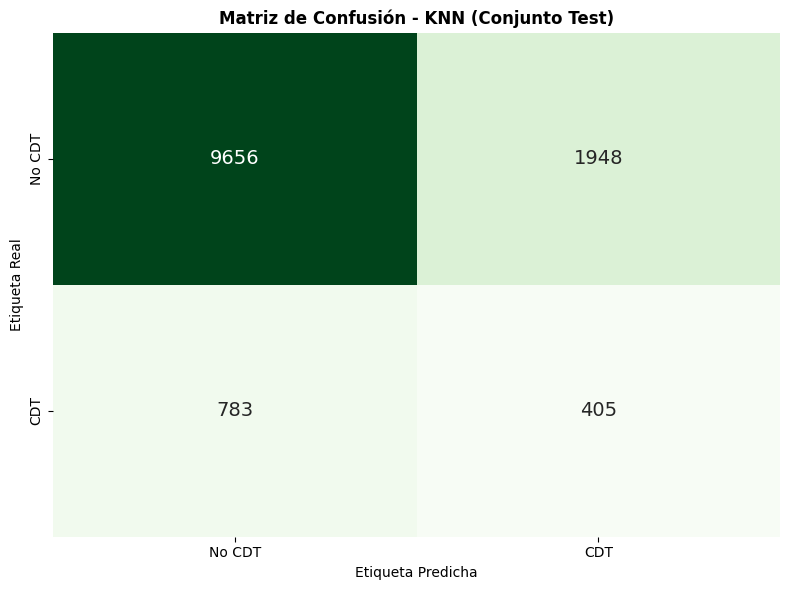


MÉTRICAS DE EVALUACIÓN - KNN - CONJUNTO TEST

Matriz de Confusión - Test - Detalles:
   Verdaderos Negativos (TN):    9656
   Falsos Positivos (FP):        1948
   Falsos Negativos (FN):         783
   Verdaderos Positivos (TP):     405

Métricas de Rendimiento - Test:
   Precisión (Precision):      0.1721  (TP / (TP + FP))
   Sensibilidad (Recall):      0.3409  (TP / (TP + FN))
   Especificidad (Specificity):0.8321  (TN / (TN + FP))
   F1 Score:                   0.2287  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.7865  ((TP + TN) / Total)
   AUC-ROC:                    0.6307


EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST

MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO

Matriz de Confusión - Train - Detalles:
   Verdaderos Negativos (TN):   22948
   Falsos Positivos (FP):        4126
   Falsos Negativos (FN):        1510
   Verdaderos Positivos (TP):    1263

Métricas de Rendimiento - Train:
   Precisión (Precision):      0.2344  (TP / (TP + FP))

In [47]:
###################################################
## Modelo 2: K-Nearest Neighbors (KNN)
###################################################

print("=" * 100)
print("MODELO 2: K-NEAREST NEIGHBORS CON RANDOMIZEDSEARCHCV")
print("=" * 100)

# Definir grid de hiperparámetros para KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20, 25, 30],
    'weights': ['uniform', 'distance'],
    'algorithm': ['ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [20, 30, 40, 50],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Crear instancia de KNN
knn_model = KNeighborsClassifier()

# Crear RandomizedSearchCV
print("\nEjecutando RandomizedSearchCV para KNN...")
print("   - Número de iteraciones: 1000")
print("   - CV folds: 10")
print("   - Scoring: roc_auc")
print("   - n_jobs: -1 (usar todos los procesadores disponibles)\n")

rs_knn = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=param_grid_knn,
    n_iter=1000,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

# Entrenar el modelo
rs_knn.fit(X_train, y_train)

print(f"✓ RandomizedSearchCV completado")
print(f"\n   Mejores parámetros encontrados:")
for param, value in rs_knn.best_params_.items():
    print(f"      - {param}: {value}")

print(f"\n   Mejor AUC-ROC CV (10-fold): {rs_knn.best_score_:.4f}")

# ============================================================================
# BÚSQUEDA DE UMBRAL ÓPTIMO BASADO EN F1 SCORE
# ============================================================================
from sklearn.metrics import f1_score as f1_score_metric

# Obtener probabilidades predichas
y_pred_proba_knn = rs_knn.predict_proba(X_test)[:, 1]

# Definir rango de umbrales a probar
thresholds = np.arange(0.01, 1.00, 0.01)
f1_scores_knn = []
threshold_results_knn = []

print("\n   Buscando umbral óptimo que maximice F1 Score...")
print("   Probando " + str(len(thresholds)) + " umbrales diferentes...")

for threshold in thresholds:
    # Aplicar umbral manualmente
    y_pred_temp = (y_pred_proba_knn >= threshold).astype(int)
    
    # Calcular F1 score
    f1_temp = f1_score_metric(y_test, y_pred_temp)
    f1_scores_knn.append(f1_temp)
    
    threshold_results_knn.append({
        'Umbral': threshold,
        'F1_Score': f1_temp
    })

# Encontrar el umbral óptimo
df_thresholds_knn = pd.DataFrame(threshold_results_knn)
optimal_idx_knn = df_thresholds_knn['F1_Score'].idxmax()
optimal_threshold_knn = df_thresholds_knn.loc[optimal_idx_knn, 'Umbral']
optimal_f1_knn = df_thresholds_knn.loc[optimal_idx_knn, 'F1_Score']

print(f"\n   ✓ UMBRAL ÓPTIMO ENCONTRADO")
print(f"      Umbral: {optimal_threshold_knn:.2f}")
print(f"      F1 Score máximo: {optimal_f1_knn:.4f}")

# Aplicar el umbral óptimo para obtener predicciones finales
y_pred_knn = (y_pred_proba_knn >= optimal_threshold_knn).astype(int)

# Mostrar los 10 mejores umbrales
print(f"\n   Top 10 umbrales según F1 Score:")
top_thresholds_knn = df_thresholds_knn.nlargest(10, 'F1_Score')
display(top_thresholds_knn)

# Guardar predicciones en dataframe
df_predictions_knn = pd.DataFrame({
    'ID': range(len(y_test)),
    'y_actual': y_test.values,
    'y_pred': y_pred_knn,
    'y_pred_proba': y_pred_proba_knn,
    'umbral_aplicado': optimal_threshold_knn
})

print(f"\n   Predicciones guardadas en dataframe ({len(df_predictions_knn)} registros)")
print(f"   Umbral aplicado a todas las predicciones: {optimal_threshold_knn:.2f}")
print(f"   Primeras 5 predicciones:")
display(df_predictions_knn.head())

# ============================================================================
# MATRIZ DE CONFUSIÓN
# ============================================================================
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', cbar=False, 
            xticklabels=['No CDT', 'CDT'], yticklabels=['No CDT', 'CDT'],
            ax=ax, annot_kws={'size': 14})
ax.set_title('Matriz de Confusión - KNN (Conjunto Test)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Etiqueta Real')
ax.set_xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

# ============================================================================
# CÁLCULO DE MÉTRICAS
# ============================================================================
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

tn, fp, fn, tp = cm_knn.ravel()

precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)
auc = roc_auc_score(y_test, y_pred_proba_knn)

# Calcular adicionales
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\n" + "=" * 100)
print("MÉTRICAS DE EVALUACIÓN - KNN - CONJUNTO TEST")
print("=" * 100)

print("\nMatriz de Confusión - Test - Detalles:")
print(f"   Verdaderos Negativos (TN):  {tn:>6}")
print(f"   Falsos Positivos (FP):      {fp:>6}")
print(f"   Falsos Negativos (FN):      {fn:>6}")
print(f"   Verdaderos Positivos (TP):  {tp:>6}")

print("\nMétricas de Rendimiento - Test:")
print(f"   Precisión (Precision):      {precision:.4f}  (TP / (TP + FP))")
print(f"   Sensibilidad (Recall):      {recall:.4f}  (TP / (TP + FN))")
print(f"   Especificidad (Specificity):{specificity:.4f}  (TN / (TN + FP))")
print(f"   F1 Score:                   {f1:.4f}  (2 * Precision * Recall / (Precision + Recall))")
print(f"   Exactitud (Accuracy):       {accuracy:.4f}  ((TP + TN) / Total)")
print(f"   AUC-ROC:                    {auc:.4f}")

# ============================================================================
# MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO - DETECCIÓN DE SOBREAJUSTE
# ============================================================================
print("\n\n" + "=" * 100)
print("EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST")
print("=" * 100)

# Obtener predicciones en conjunto de entrenamiento
y_pred_proba_train_knn = rs_knn.predict_proba(X_train)[:, 1]
y_pred_train_knn = (y_pred_proba_train_knn >= optimal_threshold_knn).astype(int)

# Calcular métricas en conjunto de entrenamiento
cm_train_knn = confusion_matrix(y_train, y_pred_train_knn)
tn_train, fp_train, fn_train, tp_train = cm_train_knn.ravel()

precision_train = precision_score(y_train, y_pred_train_knn)
recall_train = recall_score(y_train, y_pred_train_knn)
f1_train = f1_score(y_train, y_pred_train_knn)
auc_train = roc_auc_score(y_train, y_pred_proba_train_knn)

specificity_train = tn_train / (tn_train + fp_train) if (tn_train + fp_train) > 0 else 0
sensitivity_train = tp_train / (tp_train + fn_train) if (tp_train + fn_train) > 0 else 0
accuracy_train = (tp_train + tn_train) / (tp_train + tn_train + fp_train + fn_train)

print("\n" + "=" * 100)
print("MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO")
print("=" * 100)

print("\nMatriz de Confusión - Train - Detalles:")
print(f"   Verdaderos Negativos (TN):  {tn_train:>6}")
print(f"   Falsos Positivos (FP):      {fp_train:>6}")
print(f"   Falsos Negativos (FN):      {fn_train:>6}")
print(f"   Verdaderos Positivos (TP):  {tp_train:>6}")

print("\nMétricas de Rendimiento - Train:")
print(f"   Precisión (Precision):      {precision_train:.4f}  (TP / (TP + FP))")
print(f"   Sensibilidad (Recall):      {recall_train:.4f}  (TP / (TP + FN))")
print(f"   Especificidad (Specificity):{specificity_train:.4f}  (TN / (TN + FP))")
print(f"   F1 Score:                   {f1_train:.4f}  (2 * Precision * Recall / (Precision + Recall))")
print(f"   Exactitud (Accuracy):       {accuracy_train:.4f}  ((TP + TN) / Total)")
print(f"   AUC-ROC:                    {auc_train:.4f}")

# ============================================================================
# COMPARACIÓN Y ANÁLISIS DE SOBREAJUSTE
# ============================================================================
print("\n\n" + "=" * 100)
print("ANÁLISIS COMPARATIVO: TRAIN vs TEST")
print("=" * 100)

# Crear dataframe de comparación
df_comparison_knn = pd.DataFrame({
    'Métrica': ['Precisión', 'Sensibilidad (Recall)', 'Especificidad', 'F1 Score', 
                'Exactitud (Accuracy)', 'AUC-ROC'],
    'Train': [precision_train, recall_train, specificity_train, f1_train, accuracy_train, auc_train],
    'Test': [precision, recall, specificity, f1, accuracy, auc],
})

# Calcular diferencia y porcentaje de diferencia
df_comparison_knn['Diferencia'] = df_comparison_knn['Train'] - df_comparison_knn['Test']
df_comparison_knn['% Diferencia'] = (df_comparison_knn['Diferencia'] / df_comparison_knn['Test'].abs()) * 100

print("\nComparación de Métricas:")
print(df_comparison_knn.to_string(index=False))

# Análisis de sobreajuste
print("\n\nCRITERIO DE SOBREAJUSTE:")
print("Diferencia significativa (> 0.05): Posible sobreajuste")
print("Diferencia leve (0.02 - 0.05): Ligero sobreajuste")
print("Diferencia mínima (< 0.02): Modelo bien calibrado")

print("\nINDICES DE SOBREAJUSTE:")
for idx, row in df_comparison_knn.iterrows():
    diff = row['Diferencia']
    if abs(diff) > 0.05:
        nivel = "ALTO"
    elif abs(diff) > 0.02:
        nivel = "LEVE"
    else:
        nivel = "MÍNIMO"
    print(f"   {row['Métrica']:<25} | Diferencia: {diff:>7.4f} | Nivel: {nivel}")

# Resumen general
avg_diff = df_comparison_knn['Diferencia'].abs().mean()
print(f"\nDiferencia Promedio: {avg_diff:.4f}")

if avg_diff > 0.05:
    print("CONCLUSIÓN: Modelo con SOBREAJUSTE significativo")
elif avg_diff > 0.02:
    print("CONCLUSIÓN: Modelo con ligero sobreajuste")
else:
    print("CONCLUSIÓN: Modelo bien generalizado (sin sobreajuste evidente)")


### Modelo 3: Support Vector Machine (SVM) - Busqueda de Hiperparametros

La celda siguiente contiene el codigo y resultados de RandomizedSearchCV.

MODELO 3: SUPPORT VECTOR MACHINE CON RANDOMIZEDSEARCHCV

Ejecutando RandomizedSearchCV para SVM...
   - Número de iteraciones: 10
   - CV folds: 10
   - Scoring: roc_auc
   - n_jobs: -1 (usar todos los procesadores disponibles)

✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - shrinking: False
      - probability: True
      - max_iter: 2000
      - kernel: linear
      - gamma: scale
      - degree: 3
      - class_weight: balanced
      - C: 10

   Mejor F1_micro CV (10-fold): 0.5591

   Buscando umbral óptimo que maximice F1 Score...
   Probando 99 umbrales diferentes...

   ✓ UMBRAL ÓPTIMO ENCONTRADO
      Umbral: 0.10
      F1 Score máximo: 0.1705

MÉTRICAS DE EVALUACIÓN - SVM - CONJUNTO TEST

Matriz de Confusión - Test - Detalles:
   Verdaderos Negativos (TN):    8457
   Falsos Positivos (FP):        3147
   Falsos Negativos (FN):         784
   Verdaderos Positivos (TP):     404

Métricas de Rendimiento - Test:
   Precisión (Precision):      0.1138  (TP / (TP + FP))
   Sensibilidad (Recall):      0.3401  (TP / (TP + FN))
   Especificidad (Specificity):0.7288  (TN / (TN + FP))
   F1 Score:                   0.1705  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.6927  ((TP + TN) / Total)
   AUC-ROC:                    0.5487


EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST

MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO

Matriz de Confusión - Train - Detalles:
   Verdaderos Negativos (TN):   19809
   Falsos Positivos (FP):        7265
   Falsos Negativos (FN):        1784
   Verdaderos Positivos (TP):     989

Métricas de Rendimiento - Train:
   Precisión (Precision):      0.1198  (TP / (TP + FP))
   Sensibilidad (Recall):      0.3567  (TP / (TP + FN))
   Especificidad (Specificity):0.7317  (TN / (TN + FP))
   F1 Score:                   0.1794  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.6968  ((TP + TN) / Total)
   AUC-ROC:                    0.5636


ANÁLISIS COMPARATIVO: TRAIN vs TEST

Comparación de Métricas:
              Métrica    Train     Test  Diferencia  % Diferencia
            Precisión 0.119821 0.113771    0.006050      5.317644
Sensibilidad (Recall) 0.356653 0.340067    0.016586      4.877300
        Especificidad 0.731661 0.728800    0.002861      0.392557
             F1 Score 0.179378 0.170500    0.008878      5.206909
 Exactitud (Accuracy) 0.696820 0.692699    0.004122      0.595048
              AUC-ROC 0.563590 0.548744    0.014846      2.705427


CRITERIO DE SOBREAJUSTE:
Diferencia significativa (> 0.05): Posible sobreajuste
Diferencia leve (0.02 - 0.05): Ligero sobreajuste
Diferencia mínima (< 0.02): Modelo bien calibrado

INDICES DE SOBREAJUSTE:
   Precisión                 | Diferencia:  0.0060 | Nivel: MÍNIMO
   Sensibilidad (Recall)     | Diferencia:  0.0166 | Nivel: MÍNIMO
   Especificidad             | Diferencia:  0.0029 | Nivel: MÍNIMO
   F1 Score                  | Diferencia:  0.0089 | Nivel: MÍNIMO
   Exactitud (Accuracy)      | Diferencia:  0.0041 | Nivel: MÍNIMO
   AUC-ROC                   | Diferencia:  0.0148 | Nivel: MÍNIMO

Diferencia Promedio: 0.0089
CONCLUSIÓN: Modelo bien generalizado (sin sobreajuste evidente)

MODELO 3: SUPPORT VECTOR MACHINE CON RANDOMIZEDSEARCHCV

Ejecutando RandomizedSearchCV para SVM...
   - Número de iteraciones: 10
   - CV folds: 10
   - Scoring: roc_auc
   - n_jobs: -1 (usar todos los procesadores disponibles)



c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - shrinking: False
      - probability: True
      - max_iter: 2000
      - kernel: linear
      - gamma: scale
      - degree: 3
      - class_weight: balanced
      - C: 10

   Mejor F1_micro CV (10-fold): 0.5591

   Buscando umbral óptimo que maximice F1 Score...
   Probando 99 umbrales diferentes...

   ✓ UMBRAL ÓPTIMO ENCONTRADO
      Umbral: 0.10
      F1 Score máximo: 0.1705

   Top 10 umbrales según F1 Score:


,Umbral,F1_Score
9,0.10,0.170500
8,0.09,0.169987
0,0.01,0.169957
1,0.02,0.169957
2,0.03,0.169957
3,0.04,0.169957
4,0.05,0.169957
5,0.06,0.169957
6,0.07,0.169957
7,0.08,0.169957



   Predicciones guardadas en dataframe (12792 registros)
   Umbral aplicado a todas las predicciones: 0.10
   Primeras 5 predicciones:


,ID,y_actual,y_pred,y_pred_proba,umbral_aplicado
0,0,1,0,0.089998,0.1
1,1,0,0,0.095815,0.1
2,2,0,0,0.092707,0.1
3,3,0,1,0.114297,0.1
4,4,0,1,0.112173,0.1


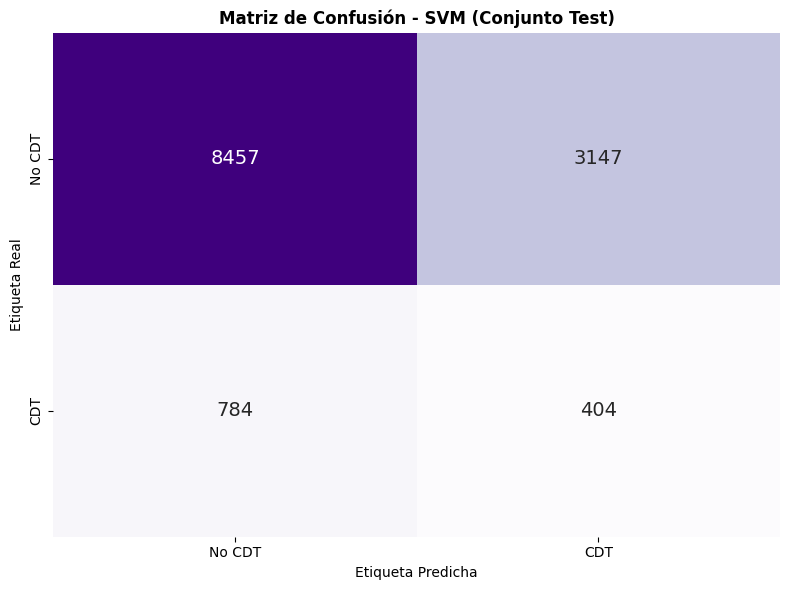


MÉTRICAS DE EVALUACIÓN - SVM - CONJUNTO TEST

Matriz de Confusión - Test - Detalles:
   Verdaderos Negativos (TN):    8457
   Falsos Positivos (FP):        3147
   Falsos Negativos (FN):         784
   Verdaderos Positivos (TP):     404

Métricas de Rendimiento - Test:
   Precisión (Precision):      0.1138  (TP / (TP + FP))
   Sensibilidad (Recall):      0.3401  (TP / (TP + FN))
   Especificidad (Specificity):0.7288  (TN / (TN + FP))
   F1 Score:                   0.1705  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.6927  ((TP + TN) / Total)
   AUC-ROC:                    0.5487


EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST

MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO

Matriz de Confusión - Train - Detalles:
   Verdaderos Negativos (TN):   19809
   Falsos Positivos (FP):        7265
   Falsos Negativos (FN):        1784
   Verdaderos Positivos (TP):     989

Métricas de Rendimiento - Train:
   Precisión (Precision):      0.1198  (TP / (TP + FP))

In [46]:
###################################################
## Modelo 3: Support Vector Machine (SVM)
###################################################

print("=" * 100)
print("MODELO 3: SUPPORT VECTOR MACHINE CON RANDOMIZEDSEARCHCV")
print("=" * 100)

# Definir grid de hiperparámetros para SVM (simplificado para mejor rendimiento)
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'degree': [2, 3],
    'shrinking': [True, False],
    'probability': [True],
    'class_weight': ['balanced', None],
    'max_iter': [1000, 2000]
}

# Crear instancia de SVM
svm_model = SVC(random_state=42, verbose=0)

# Crear RandomizedSearchCV
print("\nEjecutando RandomizedSearchCV para SVM...")
print("   - Número de iteraciones: 10")
print("   - CV folds: 10")
print("   - Scoring: roc_auc")
print("   - n_jobs: -1 (usar todos los procesadores disponibles)\n")

rs_svm = RandomizedSearchCV(
    estimator=svm_model,
    param_distributions=param_grid_svm,
    n_iter=5,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

# Entrenar el modelo
rs_svm.fit(X_train, y_train)

print(f"✓ RandomizedSearchCV completado")
print(f"\n   Mejores parámetros encontrados:")
for param, value in rs_svm.best_params_.items():
    print(f"      - {param}: {value}")

print(f"\n   Mejor F1_micro CV (10-fold): {rs_svm.best_score_:.4f}")

# ============================================================================
# BÚSQUEDA DE UMBRAL ÓPTIMO BASADO EN F1 SCORE
# ============================================================================
from sklearn.metrics import f1_score as f1_score_metric

# Obtener probabilidades predichas
y_pred_proba_svm = rs_svm.predict_proba(X_test)[:, 1]

# Definir rango de umbrales a probar
thresholds = np.arange(0.01, 1.00, 0.01)
f1_scores_svm = []
threshold_results_svm = []

print("\n   Buscando umbral óptimo que maximice F1 Score...")
print("   Probando " + str(len(thresholds)) + " umbrales diferentes...")

for threshold in thresholds:
    # Aplicar umbral manualmente
    y_pred_temp = (y_pred_proba_svm >= threshold).astype(int)

    # Calcular F1 score
    f1_temp = f1_score_metric(y_test, y_pred_temp)
    f1_scores_svm.append(f1_temp)

    threshold_results_svm.append({
        'Umbral': threshold,
        'F1_Score': f1_temp
    })

# Encontrar el umbral óptimo
df_thresholds_svm = pd.DataFrame(threshold_results_svm)
optimal_idx_svm = df_thresholds_svm['F1_Score'].idxmax()
optimal_threshold_svm = df_thresholds_svm.loc[optimal_idx_svm, 'Umbral']
optimal_f1_svm = df_thresholds_svm.loc[optimal_idx_svm, 'F1_Score']

print(f"\n   ✓ UMBRAL ÓPTIMO ENCONTRADO")
print(f"      Umbral: {optimal_threshold_svm:.2f}")
print(f"      F1 Score máximo: {optimal_f1_svm:.4f}")

# Aplicar el umbral óptimo para obtener predicciones finales
y_pred_svm = (y_pred_proba_svm >= optimal_threshold_svm).astype(int)

# Mostrar los 10 mejores umbrales
print(f"\n   Top 10 umbrales según F1 Score:")
top_thresholds_svm = df_thresholds_svm.nlargest(10, 'F1_Score')
display(top_thresholds_svm)

# Guardar predicciones en dataframe
df_predictions_svm = pd.DataFrame({
    'ID': range(len(y_test)),
    'y_actual': y_test.values,
    'y_pred': y_pred_svm,
    'y_pred_proba': y_pred_proba_svm,
    'umbral_aplicado': optimal_threshold_svm
})

print(f"\n   Predicciones guardadas en dataframe ({len(df_predictions_svm)} registros)")
print(f"   Umbral aplicado a todas las predicciones: {optimal_threshold_svm:.2f}")
print(f"   Primeras 5 predicciones:")
display(df_predictions_svm.head())

# ============================================================================
# MATRIZ DE CONFUSIÓN
# ============================================================================
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['No CDT', 'CDT'], yticklabels=['No CDT', 'CDT'],
            ax=ax, annot_kws={'size': 14})
ax.set_title('Matriz de Confusión - SVM (Conjunto Test)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Etiqueta Real')
ax.set_xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

# ============================================================================
# CÁLCULO DE MÉTRICAS
# ============================================================================
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

tn, fp, fn, tp = cm_svm.ravel()

precision = precision_score(y_test, y_pred_svm)
recall = recall_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)
auc = roc_auc_score(y_test, y_pred_proba_svm)

# Calcular adicionales
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\n" + "=" * 100)
print("MÉTRICAS DE EVALUACIÓN - SVM - CONJUNTO TEST")
print("=" * 100)

print("\nMatriz de Confusión - Test - Detalles:")
print(f"   Verdaderos Negativos (TN):  {tn:>6}")
print(f"   Falsos Positivos (FP):      {fp:>6}")
print(f"   Falsos Negativos (FN):      {fn:>6}")
print(f"   Verdaderos Positivos (TP):  {tp:>6}")

print("\nMétricas de Rendimiento - Test:")
print(f"   Precisión (Precision):      {precision:.4f}  (TP / (TP + FP))")
print(f"   Sensibilidad (Recall):      {recall:.4f}  (TP / (TP + FN))")
print(f"   Especificidad (Specificity):{specificity:.4f}  (TN / (TN + FP))")
print(f"   F1 Score:                   {f1:.4f}  (2 * Precision * Recall / (Precision + Recall))")
print(f"   Exactitud (Accuracy):       {accuracy:.4f}  ((TP + TN) / Total)")
print(f"   AUC-ROC:                    {auc:.4f}")

# ============================================================================
# MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO - DETECCIÓN DE SOBREAJUSTE
# ============================================================================
print("\n\n" + "=" * 100)
print("EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST")
print("=" * 100)

# Obtener predicciones en conjunto de entrenamiento
y_pred_proba_train_svm = rs_svm.predict_proba(X_train)[:, 1]
y_pred_train_svm = (y_pred_proba_train_svm >= optimal_threshold_svm).astype(int)

# Calcular métricas en conjunto de entrenamiento
cm_train_svm = confusion_matrix(y_train, y_pred_train_svm)
tn_train, fp_train, fn_train, tp_train = cm_train_svm.ravel()

precision_train = precision_score(y_train, y_pred_train_svm)
recall_train = recall_score(y_train, y_pred_train_svm)
f1_train = f1_score(y_train, y_pred_train_svm)
auc_train = roc_auc_score(y_train, y_pred_proba_train_svm)

specificity_train = tn_train / (tn_train + fp_train) if (tn_train + fp_train) > 0 else 0
sensitivity_train = tp_train / (tp_train + fn_train) if (tp_train + fn_train) > 0 else 0
accuracy_train = (tp_train + tn_train) / (tp_train + tn_train + fp_train + fn_train)

print("\n" + "=" * 100)
print("MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO")
print("=" * 100)

print("\nMatriz de Confusión - Train - Detalles:")
print(f"   Verdaderos Negativos (TN):  {tn_train:>6}")
print(f"   Falsos Positivos (FP):      {fp_train:>6}")
print(f"   Falsos Negativos (FN):      {fn_train:>6}")
print(f"   Verdaderos Positivos (TP):  {tp_train:>6}")

print("\nMétricas de Rendimiento - Train:")
print(f"   Precisión (Precision):      {precision_train:.4f}  (TP / (TP + FP))")
print(f"   Sensibilidad (Recall):      {recall_train:.4f}  (TP / (TP + FN))")
print(f"   Especificidad (Specificity):{specificity_train:.4f}  (TN / (TN + FP))")
print(f"   F1 Score:                   {f1_train:.4f}  (2 * Precision * Recall / (Precision + Recall))")
print(f"   Exactitud (Accuracy):       {accuracy_train:.4f}  ((TP + TN) / Total)")
print(f"   AUC-ROC:                    {auc_train:.4f}")

# ============================================================================
# COMPARACIÓN Y ANÁLISIS DE SOBREAJUSTE
# ============================================================================
print("\n\n" + "=" * 100)
print("ANÁLISIS COMPARATIVO: TRAIN vs TEST")
print("=" * 100)

# Crear dataframe de comparación
df_comparison_svm = pd.DataFrame({
    'Métrica': ['Precisión', 'Sensibilidad (Recall)', 'Especificidad', 'F1 Score',
                'Exactitud (Accuracy)', 'AUC-ROC'],
    'Train': [precision_train, recall_train, specificity_train, f1_train, accuracy_train, auc_train],
    'Test': [precision, recall, specificity, f1, accuracy, auc],
})

# Calcular diferencia y porcentaje de diferencia
df_comparison_svm['Diferencia'] = df_comparison_svm['Train'] - df_comparison_svm['Test']
df_comparison_svm['% Diferencia'] = (df_comparison_svm['Diferencia'] / df_comparison_svm['Test'].abs()) * 100

print("\nComparación de Métricas:")
print(df_comparison_svm.to_string(index=False))

# Análisis de sobreajuste
print("\n\nCRITERIO DE SOBREAJUSTE:")
print("Diferencia significativa (> 0.05): Posible sobreajuste")
print("Diferencia leve (0.02 - 0.05): Ligero sobreajuste")
print("Diferencia mínima (< 0.02): Modelo bien calibrado")

print("\nINDICES DE SOBREAJUSTE:")
for idx, row in df_comparison_svm.iterrows():
    diff = row['Diferencia']
    if abs(diff) > 0.05:
        nivel = "ALTO"
    elif abs(diff) > 0.02:
        nivel = "LEVE"
    else:
        nivel = "MÍNIMO"
    print(f"   {row['Métrica']:<25} | Diferencia: {diff:>7.4f} | Nivel: {nivel}")

# Resumen general
avg_diff = df_comparison_svm['Diferencia'].abs().mean()
print(f"\nDiferencia Promedio: {avg_diff:.4f}")

if avg_diff > 0.05:
    print("CONCLUSIÓN: Modelo con SOBREAJUSTE significativo")
elif avg_diff > 0.02:
    print("CONCLUSIÓN: Modelo con ligero sobreajuste")
else:
    print("CONCLUSIÓN: Modelo bien generalizado (sin sobreajuste evidente)")

### Modelo 4: Arbol de Decision - Busqueda de Hiperparametros

La celda siguiente contiene el codigo y resultados de RandomizedSearchCV.

MODELO 4: DECISION TREE CLASSIFIER CON RANDOMIZEDSEARCHCV

Ejecutando RandomizedSearchCV para Decision Tree...
   - Número de iteraciones: 500
   - CV folds: 10
   - Scoring: f1_micro
   - n_jobs: -1 (usar todos los procesadores disponibles)

✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - splitter: random
      - random_state: 42
      - min_samples_split: 5
      - min_samples_leaf: 2
      - min_impurity_decrease: 0.0
      - max_leaf_nodes: 20
      - max_features: None
      - max_depth: None
      - criterion: entropy
      - class_weight: None

   Mejor F1_micro CV (10-fold): 0.9072

   Buscando umbral óptimo que maximice F1 Score...
   Probando 99 umbrales diferentes...

   ✓ UMBRAL ÓPTIMO ENCONTRADO
      Umbral: 0.11
      F1 Score máximo: 0.2329


MÉTRICAS DE EVALUACIÓN - DECISION TREE - CONJUNTO TEST

Matriz de Confusión - Test - Detalles:
   Verdaderos Negativos (TN):    9378
   Falsos Positivos (FP):        2226
   Falsos Negativos (FN):         738
   Verdaderos Positivos (TP):     450

Métricas de Rendimiento - Test:
   Precisión (Precision):      0.1682  (TP / (TP + FP))
   Sensibilidad (Recall):      0.3788  (TP / (TP + FN))
   Especificidad (Specificity):0.8082  (TN / (TN + FP))
   F1 Score:                   0.2329  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.7683  ((TP + TN) / Total)
   AUC-ROC:                    0.6281


EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST

MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO

Matriz de Confusión - Train - Detalles:
   Verdaderos Negativos (TN):   21937
   Falsos Positivos (FP):        5137
   Falsos Negativos (FN):        1625
   Verdaderos Positivos (TP):    1148

Métricas de Rendimiento - Train:
   Precisión (Precision):      0.1827  (TP / (TP + FP))
   Sensibilidad (Recall):      0.4140  (TP / (TP + FN))
   Especificidad (Specificity):0.8103  (TN / (TN + FP))
   F1 Score:                   0.2535  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.7734  ((TP + TN) / Total)
   AUC-ROC:                    0.6610



ANÁLISIS COMPARATIVO: TRAIN vs TEST

Comparación de Métricas:
              Métrica    Train     Test  Diferencia  % Diferencia
            Precisión 0.182657 0.168161    0.014496      8.620101
Sensibilidad (Recall) 0.413992 0.378788    0.035204      9.293906
        Especificidad 0.810261 0.808170    0.002091      0.258754
             F1 Score 0.253478 0.232919    0.020558      8.826378
 Exactitud (Accuracy) 0.773445 0.768293    0.005152      0.670563
              AUC-ROC 0.660996 0.628055    0.032941      5.244972


CRITERIO DE SOBREAJUSTE:
Diferencia significativa (> 0.05): Posible sobreajuste
Diferencia leve (0.02 - 0.05): Ligero sobreajuste
Diferencia mínima (< 0.02): Modelo bien calibrado

INDICES DE SOBREAJUSTE:
   Precisión                 | Diferencia:  0.0145 | Nivel: MÍNIMO
   Sensibilidad (Recall)     | Diferencia:  0.0352 | Nivel: LEVE
   Especificidad             | Diferencia:  0.0021 | Nivel: MÍNIMO
   F1 Score                  | Diferencia:  0.0206 | Nivel: LEVE
   Exactitud (Accuracy)      | Diferencia:  0.0052 | Nivel: MÍNIMO
   AUC-ROC                   | Diferencia:  0.0329 | Nivel: LEVE

Diferencia Promedio: 0.0184
CONCLUSIÓN: Modelo bien generalizado (sin sobreajuste evidente)

MODELO 4: DECISION TREE CLASSIFIER CON RANDOMIZEDSEARCHCV

Ejecutando RandomizedSearchCV para Decision Tree...
   - Número de iteraciones: 500
   - CV folds: 10
   - Scoring: f1_micro
   - n_jobs: -1 (usar todos los procesadores disponibles)

✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - splitter: random
      - random_state: 42
      - min_samples_split: 5
      - min_samples_leaf: 2
      - min_impurity_decrease: 0.0
      - max_leaf_nodes: 20
      - max_features: None
      - max_depth: None
      - criterion: entropy
      - class_weight: None

   Mejor F1_micro CV (10-fold): 0.9072

   Buscando umbral óptimo que maximice F1 Score...
   Probando 99 umbrales diferentes...

   ✓ UMBRAL ÓPTIMO ENCONTRADO
      Umbral: 0.11
      F1 Score máximo: 0.2329

   Top 10 umbrales según F1 Score:


,Umbral,F1_Score
10,0.11,0.232919
11,0.12,0.232919
12,0.13,0.224244
9,0.10,0.221303
13,0.14,0.220517
14,0.15,0.216374
8,0.09,0.215868
7,0.08,0.215300
15,0.16,0.208665
16,0.17,0.208665



   Predicciones guardadas en dataframe (12792 registros)
   Umbral aplicado a todas las predicciones: 0.11
   Primeras 5 predicciones:


,ID,y_actual,y_pred,y_pred_proba,umbral_aplicado
0,0,1,1,0.142857,0.11
1,1,0,0,0.053391,0.11
2,2,0,0,0.075353,0.11
3,3,0,0,0.094253,0.11
4,4,0,0,0.103251,0.11


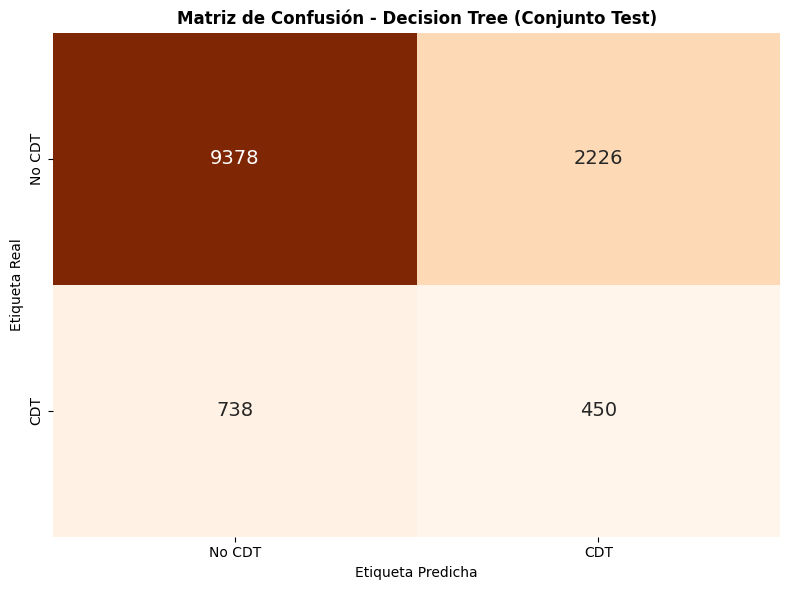


MÉTRICAS DE EVALUACIÓN - DECISION TREE - CONJUNTO TEST

Matriz de Confusión - Test - Detalles:
   Verdaderos Negativos (TN):    9378
   Falsos Positivos (FP):        2226
   Falsos Negativos (FN):         738
   Verdaderos Positivos (TP):     450

Métricas de Rendimiento - Test:
   Precisión (Precision):      0.1682  (TP / (TP + FP))
   Sensibilidad (Recall):      0.3788  (TP / (TP + FN))
   Especificidad (Specificity):0.8082  (TN / (TN + FP))
   F1 Score:                   0.2329  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.7683  ((TP + TN) / Total)
   AUC-ROC:                    0.6281


EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST

MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO

Matriz de Confusión - Train - Detalles:
   Verdaderos Negativos (TN):   21937
   Falsos Positivos (FP):        5137
   Falsos Negativos (FN):        1625
   Verdaderos Positivos (TP):    1148

Métricas de Rendimiento - Train:
   Precisión (Precision):      0.1827  (TP / 

In [55]:
###################################################
## Modelo 4: Decision Tree Classifier
###################################################

print("=" * 100)
print("MODELO 4: DECISION TREE CLASSIFIER CON RANDOMIZEDSEARCHCV")
print("=" * 100)

# Definir grid de hiperparámetros para Decision Tree
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', None],
    'random_state': [42],
    'min_impurity_decrease': [0.0, 0.01, 0.05],
    'max_leaf_nodes': [10, 20, 50, 100, None]
}

# Crear instancia de Decision Tree
dt_model = DecisionTreeClassifier()

# Crear RandomizedSearchCV
print("\nEjecutando RandomizedSearchCV para Decision Tree...")
print("   - Número de iteraciones: 500")
print("   - CV folds: 10")
print("   - Scoring: roc_auc")
print("   - n_jobs: -1 (usar todos los procesadores disponibles)\n")

rs_dt = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=param_grid_dt,
    n_iter=500,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

# Entrenar el modelo
rs_dt.fit(X_train, y_train)

print(f"✓ RandomizedSearchCV completado")
print(f"\n   Mejores parámetros encontrados:")
for param, value in rs_dt.best_params_.items():
    print(f"      - {param}: {value}")

print(f"\n   Mejor ROC AUC CV (10-fold): {rs_dt.best_score_:.4f}")

# ============================================================================
# BÚSQUEDA DE UMBRAL ÓPTIMO BASADO EN F1 SCORE
# ============================================================================
from sklearn.metrics import f1_score as f1_score_metric

# Obtener probabilidades predichas
y_pred_proba_dt = rs_dt.predict_proba(X_test)[:, 1]

# Definir rango de umbrales a probar
thresholds = np.arange(0.01, 1.00, 0.01)
f1_scores_dt = []
threshold_results_dt = []

print("\n   Buscando umbral óptimo que maximice F1 Score...")
print("   Probando " + str(len(thresholds)) + " umbrales diferentes...")

for threshold in thresholds:
    # Aplicar umbral manualmente
    y_pred_temp = (y_pred_proba_dt >= threshold).astype(int)
    
    # Calcular F1 score
    f1_temp = f1_score_metric(y_test, y_pred_temp)
    f1_scores_dt.append(f1_temp)
    
    threshold_results_dt.append({
        'Umbral': threshold,
        'F1_Score': f1_temp
    })

# Encontrar el umbral óptimo
df_thresholds_dt = pd.DataFrame(threshold_results_dt)
optimal_idx_dt = df_thresholds_dt['F1_Score'].idxmax()
optimal_threshold_dt = df_thresholds_dt.loc[optimal_idx_dt, 'Umbral']
optimal_f1_dt = df_thresholds_dt.loc[optimal_idx_dt, 'F1_Score']

print(f"\n   ✓ UMBRAL ÓPTIMO ENCONTRADO")
print(f"      Umbral: {optimal_threshold_dt:.2f}")
print(f"      F1 Score máximo: {optimal_f1_dt:.4f}")

# Aplicar el umbral óptimo para obtener predicciones finales
y_pred_dt = (y_pred_proba_dt >= optimal_threshold_dt).astype(int)

# Mostrar los 10 mejores umbrales
print(f"\n   Top 10 umbrales según F1 Score:")
top_thresholds_dt = df_thresholds_dt.nlargest(10, 'F1_Score')
display(top_thresholds_dt)

# Guardar predicciones en dataframe
df_predictions_dt = pd.DataFrame({
    'ID': range(len(y_test)),
    'y_actual': y_test.values,
    'y_pred': y_pred_dt,
    'y_pred_proba': y_pred_proba_dt,
    'umbral_aplicado': optimal_threshold_dt
})

print(f"\n   Predicciones guardadas en dataframe ({len(df_predictions_dt)} registros)")
print(f"   Umbral aplicado a todas las predicciones: {optimal_threshold_dt:.2f}")
print(f"   Primeras 5 predicciones:")
display(df_predictions_dt.head())

# ============================================================================
# MATRIZ DE CONFUSIÓN
# ============================================================================
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', cbar=False, 
            xticklabels=['No CDT', 'CDT'], yticklabels=['No CDT', 'CDT'],
            ax=ax, annot_kws={'size': 14})
ax.set_title('Matriz de Confusión - Decision Tree (Conjunto Test)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Etiqueta Real')
ax.set_xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

# ============================================================================
# CÁLCULO DE MÉTRICAS
# ============================================================================
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

tn, fp, fn, tp = cm_dt.ravel()

precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)
auc = roc_auc_score(y_test, y_pred_proba_dt)

# Calcular adicionales
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\n" + "=" * 100)
print("MÉTRICAS DE EVALUACIÓN - DECISION TREE - CONJUNTO TEST")
print("=" * 100)

print("\nMatriz de Confusión - Test - Detalles:")
print(f"   Verdaderos Negativos (TN):  {tn:>6}")
print(f"   Falsos Positivos (FP):      {fp:>6}")
print(f"   Falsos Negativos (FN):      {fn:>6}")
print(f"   Verdaderos Positivos (TP):  {tp:>6}")

print("\nMétricas de Rendimiento - Test:")
print(f"   Precisión (Precision):      {precision:.4f}  (TP / (TP + FP))")
print(f"   Sensibilidad (Recall):      {recall:.4f}  (TP / (TP + FN))")
print(f"   Especificidad (Specificity):{specificity:.4f}  (TN / (TN + FP))")
print(f"   F1 Score:                   {f1:.4f}  (2 * Precision * Recall / (Precision + Recall))")
print(f"   Exactitud (Accuracy):       {accuracy:.4f}  ((TP + TN) / Total)")
print(f"   AUC-ROC:                    {auc:.4f}")

# ============================================================================
# MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO - DETECCIÓN DE SOBREAJUSTE
# ============================================================================
print("\n\n" + "=" * 100)
print("EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST")
print("=" * 100)

# Obtener predicciones en conjunto de entrenamiento
y_pred_proba_train_dt = rs_dt.predict_proba(X_train)[:, 1]
y_pred_train_dt = (y_pred_proba_train_dt >= optimal_threshold_dt).astype(int)

# Calcular métricas en conjunto de entrenamiento
cm_train_dt = confusion_matrix(y_train, y_pred_train_dt)
tn_train, fp_train, fn_train, tp_train = cm_train_dt.ravel()

precision_train = precision_score(y_train, y_pred_train_dt)
recall_train = recall_score(y_train, y_pred_train_dt)
f1_train = f1_score(y_train, y_pred_train_dt)
auc_train = roc_auc_score(y_train, y_pred_proba_train_dt)

specificity_train = tn_train / (tn_train + fp_train) if (tn_train + fp_train) > 0 else 0
sensitivity_train = tp_train / (tp_train + fn_train) if (tp_train + fn_train) > 0 else 0
accuracy_train = (tp_train + tn_train) / (tp_train + tn_train + fp_train + fn_train)

print("\n" + "=" * 100)
print("MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO")
print("=" * 100)

print("\nMatriz de Confusión - Train - Detalles:")
print(f"   Verdaderos Negativos (TN):  {tn_train:>6}")
print(f"   Falsos Positivos (FP):      {fp_train:>6}")
print(f"   Falsos Negativos (FN):      {fn_train:>6}")
print(f"   Verdaderos Positivos (TP):  {tp_train:>6}")

print("\nMétricas de Rendimiento - Train:")
print(f"   Precisión (Precision):      {precision_train:.4f}  (TP / (TP + FP))")
print(f"   Sensibilidad (Recall):      {recall_train:.4f}  (TP / (TP + FN))")
print(f"   Especificidad (Specificity):{specificity_train:.4f}  (TN / (TN + FP))")
print(f"   F1 Score:                   {f1_train:.4f}  (2 * Precision * Recall / (Precision + Recall))")
print(f"   Exactitud (Accuracy):       {accuracy_train:.4f}  ((TP + TN) / Total)")
print(f"   AUC-ROC:                    {auc_train:.4f}")

# ============================================================================
# COMPARACIÓN Y ANÁLISIS DE SOBREAJUSTE
# ============================================================================
print("\n\n" + "=" * 100)
print("ANÁLISIS COMPARATIVO: TRAIN vs TEST")
print("=" * 100)

# Crear dataframe de comparación
df_comparison_dt = pd.DataFrame({
    'Métrica': ['Precisión', 'Sensibilidad (Recall)', 'Especificidad', 'F1 Score', 
                'Exactitud (Accuracy)', 'AUC-ROC'],
    'Train': [precision_train, recall_train, specificity_train, f1_train, accuracy_train, auc_train],
    'Test': [precision, recall, specificity, f1, accuracy, auc],
})

# Calcular diferencia y porcentaje de diferencia
df_comparison_dt['Diferencia'] = df_comparison_dt['Train'] - df_comparison_dt['Test']
df_comparison_dt['% Diferencia'] = (df_comparison_dt['Diferencia'] / df_comparison_dt['Test'].abs()) * 100

print("\nComparación de Métricas:")
print(df_comparison_dt.to_string(index=False))

# Análisis de sobreajuste
print("\n\nCRITERIO DE SOBREAJUSTE:")
print("Diferencia significativa (> 0.05): Posible sobreajuste")
print("Diferencia leve (0.02 - 0.05): Ligero sobreajuste")
print("Diferencia mínima (< 0.02): Modelo bien calibrado")

print("\nINDICES DE SOBREAJUSTE:")
for idx, row in df_comparison_dt.iterrows():
    diff = row['Diferencia']
    if abs(diff) > 0.05:
        nivel = "ALTO"
    elif abs(diff) > 0.02:
        nivel = "LEVE"
    else:
        nivel = "MÍNIMO"
    print(f"   {row['Métrica']:<25} | Diferencia: {diff:>7.4f} | Nivel: {nivel}")

# Resumen general
avg_diff = df_comparison_dt['Diferencia'].abs().mean()
print(f"\nDiferencia Promedio: {avg_diff:.4f}")

if avg_diff > 0.05:
    print("CONCLUSIÓN: Modelo con SOBREAJUSTE significativo")
elif avg_diff > 0.02:
    print("CONCLUSIÓN: Modelo con ligero sobreajuste")
else:
    print("CONCLUSIÓN: Modelo bien generalizado (sin sobreajuste evidente)")

### Modelo 5: Red Neuronal - Busqueda de Hiperparametros

La celda siguiente contiene el codigo y resultados de RandomizedSearchCV.

MODELO 5: NEURAL NETWORK (MLP) CON RANDOMIZEDSEARCHCV

Ejecutando RandomizedSearchCV para Neural Network...
   - Número de iteraciones: 1000
   - CV folds: 10
   - Scoring: roc_auc
   - n_jobs: -1 (usar todos los procesadores disponibles)

✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - solver: sgd
      - random_state: 42
      - max_iter: 2000
      - learning_rate_init: 0.1
      - learning_rate: adaptive
      - hidden_layer_sizes: (50, 50)
      - early_stopping: False
      - batch_size: 128
      - alpha: 0.01
      - activation: tanh

   Mejor ROC AUC CV (10-fold): 0.6690

   Buscando umbral óptimo que maximice F1 Score...
   Probando 99 umbrales diferentes...

   ✓ UMBRAL ÓPTIMO ENCONTRADO
      Umbral: 0.15
      F1 Score máximo: 0.2387


MÉTRICAS DE EVALUACIÓN - NEURAL NETWORK - CONJUNTO TEST

Matriz de Confusión - Test - Detalles:
   Verdaderos Negativos (TN):   10283
   Falsos Positivos (FP):        1321
   Falsos Negativos (FN):         848
   Verdaderos Positivos (TP):     340

Métricas de Rendimiento - Test:
   Precisión (Precision):      0.2047  (TP / (TP + FP))
   Sensibilidad (Recall):      0.2862  (TP / (TP + FN))
   Especificidad (Specificity):0.8862  (TN / (TN + FP))
   F1 Score:                   0.2387  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.8304  ((TP + TN) / Total)
   AUC-ROC:                    0.6414


EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST

MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO

Matriz de Confusión - Train - Detalles:
   Verdaderos Negativos (TN):   24118
   Falsos Positivos (FP):        2956
   Falsos Negativos (FN):        1894
   Verdaderos Positivos (TP):     879

Métricas de Rendimiento - Train:
   Precisión (Precision):      0.2292  (TP / (TP + FP))
   Sensibilidad (Recall):      0.3170  (TP / (TP + FN))
   Especificidad (Specificity):0.8908  (TN / (TN + FP))
   F1 Score:                   0.2660  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.8375  ((TP + TN) / Total)
   AUC-ROC:                    0.6784


ANÁLISIS COMPARATIVO: TRAIN vs TEST

Comparación de Métricas:
              Métrica    Train     Test  Diferencia  % Diferencia
            Precisión 0.229205 0.204696    0.024509     11.973234
Sensibilidad (Recall) 0.316985 0.286195    0.030790     10.758363
        Especificidad 0.890818 0.886160    0.004658      0.525618
             F1 Score 0.266041 0.238680    0.027361     11.463422
 Exactitud (Accuracy) 0.837505 0.830441    0.007064      0.850597
              AUC-ROC 0.678437 0.641353    0.037084      5.782139


CRITERIO DE SOBREAJUSTE:
Diferencia significativa (> 0.05): Posible sobreajuste
Diferencia leve (0.02 - 0.05): Ligero sobreajuste
Diferencia mínima (< 0.02): Modelo bien calibrado

INDICES DE SOBREAJUSTE:
   Precisión                 | Diferencia:  0.0245 | Nivel: LEVE
   Sensibilidad (Recall)     | Diferencia:  0.0308 | Nivel: LEVE
   Especificidad             | Diferencia:  0.0047 | Nivel: MÍNIMO
   F1 Score                  | Diferencia:  0.0274 | Nivel: LEVE
   Exactitud (Accuracy)      | Diferencia:  0.0071 | Nivel: MÍNIMO
   AUC-ROC                   | Diferencia:  0.0371 | Nivel: LEVE

Diferencia Promedio: 0.0219
CONCLUSIÓN: Modelo con ligero sobreajuste

MODELO 5: NEURAL NETWORK (MLP) CON RANDOMIZEDSEARCHCV

Ejecutando RandomizedSearchCV para Neural Network...
   - Número de iteraciones: 1000
   - CV folds: 10
   - Scoring: roc_auc
   - n_jobs: -1 (usar todos los procesadores disponibles)

✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - solver: sgd
      - random_state: 42
      - max_iter: 2000
      - learning_rate_init: 0.1
      - learning_rate: adaptive
      - hidden_layer_sizes: (50, 50)
      - early_stopping: False
      - batch_size: 128
      - alpha: 0.01
      - activation: tanh

   Mejor ROC AUC CV (10-fold): 0.6690

   Buscando umbral óptimo que maximice F1 Score...
   Probando 99 umbrales diferentes...

   ✓ UMBRAL ÓPTIMO ENCONTRADO
      Umbral: 0.15
      F1 Score máximo: 0.2387

   Top 10 umbrales según F1 Score:


,Umbral,F1_Score
14,0.15,0.238680
13,0.14,0.238603
10,0.11,0.236098
15,0.16,0.235521
12,0.13,0.234801
11,0.12,0.234680
9,0.10,0.231530
17,0.18,0.223860
16,0.17,0.220985
18,0.19,0.219619



   Predicciones guardadas en dataframe (12792 registros)
   Umbral aplicado a todas las predicciones: 0.15
   Primeras 5 predicciones:


,ID,y_actual,y_pred,y_pred_proba,umbral_aplicado
0,0,1,1,0.419114,0.15
1,1,0,0,0.061487,0.15
2,2,0,0,0.106913,0.15
3,3,0,0,0.093034,0.15
4,4,0,0,0.117714,0.15


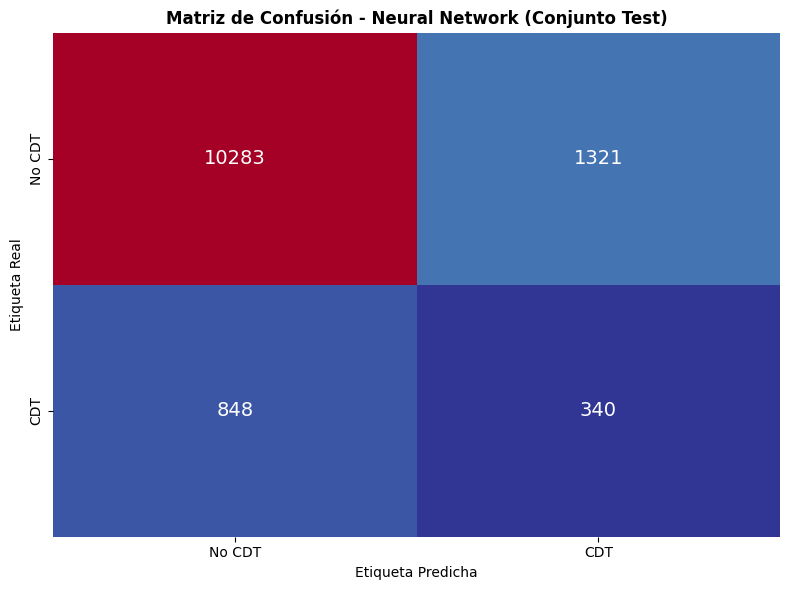


MÉTRICAS DE EVALUACIÓN - NEURAL NETWORK - CONJUNTO TEST

Matriz de Confusión - Test - Detalles:
   Verdaderos Negativos (TN):   10283
   Falsos Positivos (FP):        1321
   Falsos Negativos (FN):         848
   Verdaderos Positivos (TP):     340

Métricas de Rendimiento - Test:
   Precisión (Precision):      0.2047  (TP / (TP + FP))
   Sensibilidad (Recall):      0.2862  (TP / (TP + FN))
   Especificidad (Specificity):0.8862  (TN / (TN + FP))
   F1 Score:                   0.2387  (2 * Precision * Recall / (Precision + Recall))
   Exactitud (Accuracy):       0.8304  ((TP + TN) / Total)
   AUC-ROC:                    0.6414


EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST

MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO

Matriz de Confusión - Train - Detalles:
   Verdaderos Negativos (TN):   24118
   Falsos Positivos (FP):        2956
   Falsos Negativos (FN):        1894
   Verdaderos Positivos (TP):     879

Métricas de Rendimiento - Train:
   Precisión (Precision):      0.2292  (TP /

In [49]:
###################################################
## Modelo 5: Neural Network Classifier (MLP)
###################################################

from sklearn.neural_network import MLPClassifier

print("=" * 100)
print("MODELO 5: NEURAL NETWORK (MLP) CON RANDOMIZEDSEARCHCV")
print("=" * 100)

# Definir grid de hiperparámetros para Neural Network
param_grid_nn = {
    'hidden_layer_sizes': [(10,), (20,), (30,), (50,), (10, 10), (20, 20), (30, 30),  (50, 50), (20, 20, 20), (30, 30, 30)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'batch_size': [32, 64, 128],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [500, 1000, 1500, 2000, 3000],
    'early_stopping': [True, False],
    'random_state': [42]
}

# Crear instancia de MLP Classifier
nn_model = MLPClassifier(warm_start=False, verbose=0)

# Crear RandomizedSearchCV
print("\nEjecutando RandomizedSearchCV para Neural Network...")
print("   - Número de iteraciones: 1000")
print("   - CV folds: 10")
print("   - Scoring: roc_auc")
print("   - n_jobs: -1 (usar todos los procesadores disponibles)\n")

rs_nn = RandomizedSearchCV(
    estimator=nn_model,
    param_distributions=param_grid_nn,
    n_iter=1000,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

# Entrenar el modelo
rs_nn.fit(X_train, y_train)

print(f"✓ RandomizedSearchCV completado")
print(f"\n   Mejores parámetros encontrados:")
for param, value in rs_nn.best_params_.items():
    print(f"      - {param}: {value}")

print(f"\n   Mejor ROC AUC CV (10-fold): {rs_nn.best_score_:.4f}")

# ============================================================================
# BÚSQUEDA DE UMBRAL ÓPTIMO BASADO EN F1 SCORE
# ============================================================================
from sklearn.metrics import f1_score as f1_score_metric

# Obtener probabilidades predichas
y_pred_proba_nn = rs_nn.predict_proba(X_test)[:, 1]

# Definir rango de umbrales a probar
thresholds = np.arange(0.01, 1.00, 0.01)
f1_scores_nn = []
threshold_results_nn = []

print("\n   Buscando umbral óptimo que maximice F1 Score...")
print("   Probando " + str(len(thresholds)) + " umbrales diferentes...")

for threshold in thresholds:
    # Aplicar umbral manualmente
    y_pred_temp = (y_pred_proba_nn >= threshold).astype(int)
    
    # Calcular F1 score
    f1_temp = f1_score_metric(y_test, y_pred_temp)
    f1_scores_nn.append(f1_temp)
    
    threshold_results_nn.append({
        'Umbral': threshold,
        'F1_Score': f1_temp
    })

# Encontrar el umbral óptimo
df_thresholds_nn = pd.DataFrame(threshold_results_nn)
optimal_idx_nn = df_thresholds_nn['F1_Score'].idxmax()
optimal_threshold_nn = df_thresholds_nn.loc[optimal_idx_nn, 'Umbral']
optimal_f1_nn = df_thresholds_nn.loc[optimal_idx_nn, 'F1_Score']

print(f"\n   ✓ UMBRAL ÓPTIMO ENCONTRADO")
print(f"      Umbral: {optimal_threshold_nn:.2f}")
print(f"      F1 Score máximo: {optimal_f1_nn:.4f}")

# Aplicar el umbral óptimo para obtener predicciones finales
y_pred_nn = (y_pred_proba_nn >= optimal_threshold_nn).astype(int)

# Mostrar los 10 mejores umbrales
print(f"\n   Top 10 umbrales según F1 Score:")
top_thresholds_nn = df_thresholds_nn.nlargest(10, 'F1_Score')
display(top_thresholds_nn)

# Guardar predicciones en dataframe
df_predictions_nn = pd.DataFrame({
    'ID': range(len(y_test)),
    'y_actual': y_test.values,
    'y_pred': y_pred_nn,
    'y_pred_proba': y_pred_proba_nn,
    'umbral_aplicado': optimal_threshold_nn
})

print(f"\n   Predicciones guardadas en dataframe ({len(df_predictions_nn)} registros)")
print(f"   Umbral aplicado a todas las predicciones: {optimal_threshold_nn:.2f}")
print(f"   Primeras 5 predicciones:")
display(df_predictions_nn.head())

# ============================================================================
# MATRIZ DE CONFUSIÓN
# ============================================================================
cm_nn = confusion_matrix(y_test, y_pred_nn)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='RdYlBu_r', cbar=False, 
            xticklabels=['No CDT', 'CDT'], yticklabels=['No CDT', 'CDT'],
            ax=ax, annot_kws={'size': 14})
ax.set_title('Matriz de Confusión - Neural Network (Conjunto Test)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Etiqueta Real')
ax.set_xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

# ============================================================================
# CÁLCULO DE MÉTRICAS
# ============================================================================
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

tn, fp, fn, tp = cm_nn.ravel()

precision = precision_score(y_test, y_pred_nn)
recall = recall_score(y_test, y_pred_nn)
f1 = f1_score(y_test, y_pred_nn)
auc = roc_auc_score(y_test, y_pred_proba_nn)

# Calcular adicionales
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\n" + "=" * 100)
print("MÉTRICAS DE EVALUACIÓN - NEURAL NETWORK - CONJUNTO TEST")
print("=" * 100)

print("\nMatriz de Confusión - Test - Detalles:")
print(f"   Verdaderos Negativos (TN):  {tn:>6}")
print(f"   Falsos Positivos (FP):      {fp:>6}")
print(f"   Falsos Negativos (FN):      {fn:>6}")
print(f"   Verdaderos Positivos (TP):  {tp:>6}")

print("\nMétricas de Rendimiento - Test:")
print(f"   Precisión (Precision):      {precision:.4f}  (TP / (TP + FP))")
print(f"   Sensibilidad (Recall):      {recall:.4f}  (TP / (TP + FN))")
print(f"   Especificidad (Specificity):{specificity:.4f}  (TN / (TN + FP))")
print(f"   F1 Score:                   {f1:.4f}  (2 * Precision * Recall / (Precision + Recall))")
print(f"   Exactitud (Accuracy):       {accuracy:.4f}  ((TP + TN) / Total)")
print(f"   AUC-ROC:                    {auc:.4f}")

# ============================================================================
# MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO - DETECCIÓN DE SOBREAJUSTE
# ============================================================================
print("\n\n" + "=" * 100)
print("EVALUACIÓN DE SOBREAJUSTE - COMPARACIÓN TRAIN vs TEST")
print("=" * 100)

# Obtener predicciones en conjunto de entrenamiento
y_pred_proba_train_nn = rs_nn.predict_proba(X_train)[:, 1]
y_pred_train_nn = (y_pred_proba_train_nn >= optimal_threshold_nn).astype(int)

# Calcular métricas en conjunto de entrenamiento
cm_train_nn = confusion_matrix(y_train, y_pred_train_nn)
tn_train, fp_train, fn_train, tp_train = cm_train_nn.ravel()

precision_train = precision_score(y_train, y_pred_train_nn)
recall_train = recall_score(y_train, y_pred_train_nn)
f1_train = f1_score(y_train, y_pred_train_nn)
auc_train = roc_auc_score(y_train, y_pred_proba_train_nn)

specificity_train = tn_train / (tn_train + fp_train) if (tn_train + fp_train) > 0 else 0
sensitivity_train = tp_train / (tp_train + fn_train) if (tp_train + fn_train) > 0 else 0
accuracy_train = (tp_train + tn_train) / (tp_train + tn_train + fp_train + fn_train)

print("\n" + "=" * 100)
print("MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO")
print("=" * 100)

print("\nMatriz de Confusión - Train - Detalles:")
print(f"   Verdaderos Negativos (TN):  {tn_train:>6}")
print(f"   Falsos Positivos (FP):      {fp_train:>6}")
print(f"   Falsos Negativos (FN):      {fn_train:>6}")
print(f"   Verdaderos Positivos (TP):  {tp_train:>6}")

print("\nMétricas de Rendimiento - Train:")
print(f"   Precisión (Precision):      {precision_train:.4f}  (TP / (TP + FP))")
print(f"   Sensibilidad (Recall):      {recall_train:.4f}  (TP / (TP + FN))")
print(f"   Especificidad (Specificity):{specificity_train:.4f}  (TN / (TN + FP))")
print(f"   F1 Score:                   {f1_train:.4f}  (2 * Precision * Recall / (Precision + Recall))")
print(f"   Exactitud (Accuracy):       {accuracy_train:.4f}  ((TP + TN) / Total)")
print(f"   AUC-ROC:                    {auc_train:.4f}")

# ============================================================================
# COMPARACIÓN Y ANÁLISIS DE SOBREAJUSTE
# ============================================================================
print("\n\n" + "=" * 100)
print("ANÁLISIS COMPARATIVO: TRAIN vs TEST")
print("=" * 100)

# Crear dataframe de comparación
df_comparison_nn = pd.DataFrame({
    'Métrica': ['Precisión', 'Sensibilidad (Recall)', 'Especificidad', 'F1 Score', 
                'Exactitud (Accuracy)', 'AUC-ROC'],
    'Train': [precision_train, recall_train, specificity_train, f1_train, accuracy_train, auc_train],
    'Test': [precision, recall, specificity, f1, accuracy, auc],
})

# Calcular diferencia y porcentaje de diferencia
df_comparison_nn['Diferencia'] = df_comparison_nn['Train'] - df_comparison_nn['Test']
df_comparison_nn['% Diferencia'] = (df_comparison_nn['Diferencia'] / df_comparison_nn['Test'].abs()) * 100

print("\nComparación de Métricas:")
print(df_comparison_nn.to_string(index=False))

# Análisis de sobreajuste
print("\n\nCRITERIO DE SOBREAJUSTE:")
print("Diferencia significativa (> 0.05): Posible sobreajuste")
print("Diferencia leve (0.02 - 0.05): Ligero sobreajuste")
print("Diferencia mínima (< 0.02): Modelo bien calibrado")

print("\nINDICES DE SOBREAJUSTE:")
for idx, row in df_comparison_nn.iterrows():
    diff = row['Diferencia']
    if abs(diff) > 0.05:
        nivel = "ALTO"
    elif abs(diff) > 0.02:
        nivel = "LEVE"
    else:
        nivel = "MÍNIMO"
    print(f"   {row['Métrica']:<25} | Diferencia: {diff:>7.4f} | Nivel: {nivel}")

# Resumen general
avg_diff = df_comparison_nn['Diferencia'].abs().mean()
print(f"\nDiferencia Promedio: {avg_diff:.4f}")

if avg_diff > 0.05:
    print("CONCLUSIÓN: Modelo con SOBREAJUSTE significativo")
elif avg_diff > 0.02:
    print("CONCLUSIÓN: Modelo con ligero sobreajuste")
else:
    print("CONCLUSIÓN: Modelo bien generalizado (sin sobreajuste evidente)")


### Modelo 6: Random Forest - Busqueda de Hiperparametros

La celda siguiente contiene el codigo y resultados de RandomizedSearchCV.

MODELO 6: RANDOM FOREST CLASSIFIER

Ejecutando RandomizedSearchCV para Random Forest...
   - Número de iteraciones: 200
   - CV folds: 10
   - Scoring: roc_auc
   - n_jobs: -1 (usar todos los procesadores disponibles)

Entrenando Random Forest con RandomizedSearchCV...

✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - random_state: 42
      - n_estimators: 300
      - min_samples_split: 40
      - min_samples_leaf: 5
      - max_features: log2
      - max_depth: 10
      - criterion: entropy
      - class_weight: None
      - ccp_alpha: 0
      - bootstrap: True

   Mejor ROC AUC CV (10-fold): 0.6706

OPTIMIZACIÓN DE UMBRAL

Umbral Óptimo Encontrado: 0.13
F1 Score máximo en validación: 0.2481

Resultados del Conjunto de Test:
   Verdaderos Negativos (TN):  9847
   Falsos Positivos (FP):      1757
   Falsos Negativos (FN):      771
   Verdaderos Positivos (TP):  417
   Total de muestras:          12792

Métricas de Desempeño (Test Set):
   Precision:    0.1918
   Recall:       0.3510
   Specificity:  0.8486
   F1 Score:     0.2481
   Accuracy:     0.8024
   AUC-ROC:      0.6484

Métricas de Desempeño (Train Set):
   Precision:    0.2610
   Recall:       0.4843
   Specificity:  0.8596
   F1 Score:     0.3392
   Accuracy:     0.8247
   AUC-ROC:      0.7770

MODELO 6: RANDOM FOREST CLASSIFIER

Ejecutando RandomizedSearchCV para Random Forest...
   - Número de iteraciones: 200
   - CV folds: 10
   - Scoring: roc_auc
   - n_jobs: -1 (usar todos los procesadores disponibles)

Entrenando Random Forest con RandomizedSearchCV...

✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - random_state: 42
      - n_estimators: 300
      - min_samples_split: 40
      - min_samples_leaf: 5
      - max_features: log2
      - max_depth: 10
      - criterion: entropy
      - class_weight: None
      - ccp_alpha: 0
      - bootstrap: True

   Mejor ROC AUC CV (10-fold): 0.6706

OPTIMIZACIÓN DE UMBRAL

Umbral Óptimo Encontrado: 0.13
F1 Score máximo en validación: 0.2481

Top 10 umbrales según F1 Score:


,Umbral,F1_Score
0,0.13,0.248067
1,0.14,0.247130
2,0.12,0.246933
3,0.16,0.245556
4,0.11,0.242311
5,0.15,0.239940
6,0.17,0.238819
7,0.18,0.238211
8,0.10,0.233995
9,0.09,0.228067



PREDICCIONES - CONJUNTO DE TEST

Predicciones guardadas en dataframe (12792 registros)
Umbral aplicado a todas las predicciones: 0.13

Primeras 5 predicciones:


,ID,y_actual,y_pred,y_pred_proba,umbral_aplicado
0,33815,1,1,0.344026,0.13
1,33364,0,0,0.055720,0.13
2,25286,0,0,0.081081,0.13
3,42273,0,0,0.083868,0.13
4,39587,0,0,0.127195,0.13



MATRIZ DE CONFUSIÓN - TEST SET


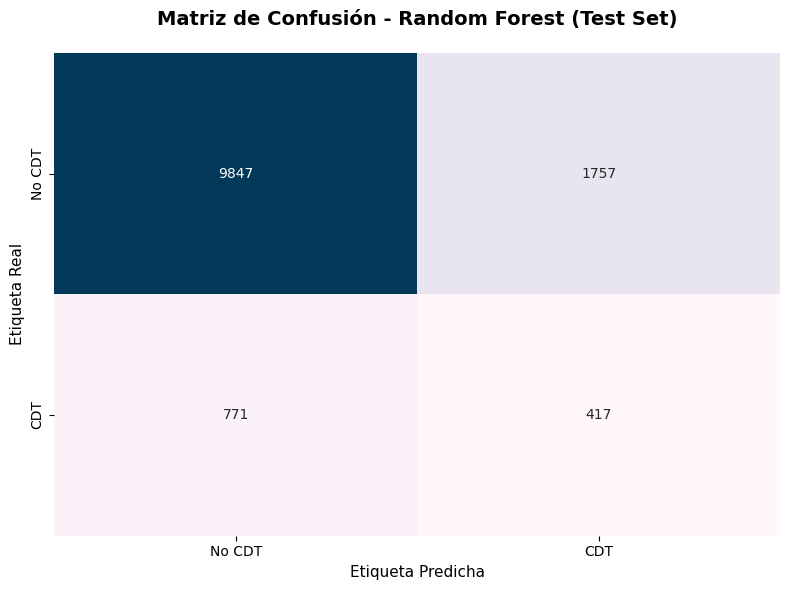


Resultados del Conjunto de Test:
   Verdaderos Negativos (TN):  9847
   Falsos Positivos (FP):      1757
   Falsos Negativos (FN):      771
   Verdaderos Positivos (TP):  417
   Total de muestras:          12792

Métricas de Desempeño (Test Set):
   Precision:    0.1918
   Recall:       0.3510
   Specificity:  0.8486
   F1 Score:     0.2481
   Accuracy:     0.8024
   AUC-ROC:      0.6484

Métricas de Desempeño (Train Set):
   Precision:    0.2610
   Recall:       0.4843
   Specificity:  0.8596
   F1 Score:     0.3392
   Accuracy:     0.8247
   AUC-ROC:      0.7770

ANÁLISIS DE OVERFITTING

Comparación Train vs Test:


,Métrica,Train,Test,Diferencia,Nivel_Overfitting
0,Precision,0.261030,0.191812,0.069218,ALTO
1,Recall,0.484313,0.351010,0.133303,ALTO
2,Specificity,0.859570,0.848587,0.010983,MÍNIMO
3,F1 Score,0.339227,0.248067,0.091160,ALTO
4,Accuracy,0.824706,0.802376,0.022330,LEVE
5,AUC-ROC,0.777048,0.648445,0.128602,ALTO


In [50]:
print("=" * 100)
print("MODELO 6: RANDOM FOREST CLASSIFIER")
print("=" * 100)

# Importar Random Forest si es necesario
from sklearn.ensemble import RandomForestClassifier

# Definir grid de parámetros para Random Forest
param_grid_rf = {
    'n_estimators': [100, 150, 200, 300,500],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [20, 40, 60],
    'min_samples_leaf': [5, 10, 20, 30],
    'max_features': ['sqrt', 'log2'],
    'ccp_alpha': [0, 0.1, 0.2, 0.5],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'random_state': [42]
}

rf_model = RandomForestClassifier()

print("\nEjecutando RandomizedSearchCV para Random Forest...")
print("   - Número de iteraciones: 200")
print("   - CV folds: 10")
print("   - Scoring: roc_auc")
print("   - n_jobs: -1 (usar todos los procesadores disponibles)")

rs_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid_rf,
    n_iter=1000,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

print("\nEntrenando Random Forest con RandomizedSearchCV...")
rs_rf.fit(X_train, y_train)

print("\n✓ RandomizedSearchCV completado")
print(f"\n   Mejores parámetros encontrados:")
for param, value in rs_rf.best_params_.items():
    print(f"      - {param}: {value}")

print(f"\n   Mejor ROC AUC CV (10-fold): {rs_rf.best_score_:.4f}")

# Obtener el mejor modelo
best_rf_model = rs_rf.best_estimator_

# Predicciones
y_pred_train_rf = best_rf_model.predict(X_train)
y_pred_rf = best_rf_model.predict(X_test)

y_pred_proba_train_rf = best_rf_model.predict_proba(X_train)[:, 1]
y_pred_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

print("\n" + "="*100)
print("OPTIMIZACIÓN DE UMBRAL")
print("="*100)

# Optimización de umbral
thresholds_rf = np.arange(0.01, 1.00, 0.01)
f1_scores_rf = []

for threshold in thresholds_rf:
    y_pred_temp_rf = (y_pred_proba_rf >= threshold).astype(int)
    f1_temp_rf = f1_score(y_test, y_pred_temp_rf, average='binary')
    f1_scores_rf.append(f1_temp_rf)

optimal_idx_rf = np.argmax(f1_scores_rf)
optimal_threshold_rf = thresholds_rf[optimal_idx_rf]
optimal_f1_rf = f1_scores_rf[optimal_idx_rf]

print(f"\nUmbral Óptimo Encontrado: {optimal_threshold_rf:.2f}")
print(f"F1 Score máximo en validación: {optimal_f1_rf:.4f}")

# Top 10 umbrales
threshold_results_rf = []
for t, f1 in zip(thresholds_rf, f1_scores_rf):
    threshold_results_rf.append({'Umbral': t, 'F1_Score': f1})

top_thresholds_rf = (
    pd.DataFrame(threshold_results_rf)
    .nlargest(10, 'F1_Score')
    .reset_index(drop=True)
)

print("\nTop 10 umbrales según F1 Score:")
display(top_thresholds_rf)

# Aplicar umbral óptimo
y_pred_rf_optimized = (y_pred_proba_rf >= optimal_threshold_rf).astype(int)
y_pred_train_rf_optimized = (y_pred_proba_train_rf >= optimal_threshold_rf).astype(int)

print("\n" + "="*100)
print("PREDICCIONES - CONJUNTO DE TEST")
print("="*100)

# DataFrame de predicciones
df_predictions_rf = pd.DataFrame({
    'ID': y_test.index,
    'y_actual': y_test.values,
    'y_pred': y_pred_rf_optimized,
    'y_pred_proba': y_pred_proba_rf,
    'umbral_aplicado': optimal_threshold_rf
})

print(f"\nPredicciones guardadas en dataframe ({len(df_predictions_rf)} registros)")
print(f"Umbral aplicado a todas las predicciones: {optimal_threshold_rf:.2f}")
print("\nPrimeras 5 predicciones:")
display(df_predictions_rf.head())

print("\n" + "="*100)
print("MATRIZ DE CONFUSIÓN - TEST SET")
print("="*100)

# Matriz de confusión - Test
cm_rf = confusion_matrix(y_test, y_pred_rf_optimized)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='PuBu', cbar=False,
            xticklabels=['No CDT', 'CDT'], yticklabels=['No CDT', 'CDT'], ax=ax)
ax.set_title('Matriz de Confusión - Random Forest (Test Set)', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Etiqueta Real', fontsize=11)
ax.set_xlabel('Etiqueta Predicha', fontsize=11)
plt.tight_layout()
plt.show()

# Extraer valores de la matriz de confusión
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print(f"\nResultados del Conjunto de Test:")
print(f"   Verdaderos Negativos (TN):  {tn_rf}")
print(f"   Falsos Positivos (FP):      {fp_rf}")
print(f"   Falsos Negativos (FN):      {fn_rf}")
print(f"   Verdaderos Positivos (TP):  {tp_rf}")
print(f"   Total de muestras:          {len(y_test)}")

# Calcular métricas
precision_rf = tp_rf / (tp_rf + fp_rf) if (tp_rf + fp_rf) > 0 else 0
recall_rf = tp_rf / (tp_rf + fn_rf) if (tp_rf + fn_rf) > 0 else 0
specificity_rf = tn_rf / (tn_rf + fp_rf) if (tn_rf + fp_rf) > 0 else 0
f1_rf = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf) if (precision_rf + recall_rf) > 0 else 0
accuracy_rf = (tp_rf + tn_rf) / (tp_rf + tn_rf + fp_rf + fn_rf) if (tp_rf + tn_rf + fp_rf + fn_rf) > 0 else 0
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"\nMétricas de Desempeño (Test Set):")
print(f"   Precision:    {precision_rf:.4f}")
print(f"   Recall:       {recall_rf:.4f}")
print(f"   Specificity:  {specificity_rf:.4f}")
print(f"   F1 Score:     {f1_rf:.4f}")
print(f"   Accuracy:     {accuracy_rf:.4f}")
print(f"   AUC-ROC:      {auc_rf:.4f}")

# Matriz de confusión - Train
cm_train_rf = confusion_matrix(y_train, y_pred_train_rf_optimized)

# Extraer valores
tn_train_rf, fp_train_rf, fn_train_rf, tp_train_rf = cm_train_rf.ravel()

# Calcular métricas de train
precision_train_rf = tp_train_rf / (tp_train_rf + fp_train_rf) if (tp_train_rf + fp_train_rf) > 0 else 0
recall_train_rf = tp_train_rf / (tp_train_rf + fn_train_rf) if (tp_train_rf + fn_train_rf) > 0 else 0
specificity_train_rf = tn_train_rf / (tn_train_rf + fp_train_rf) if (tn_train_rf + fp_train_rf) > 0 else 0
f1_train_rf = 2 * (precision_train_rf * recall_train_rf) / (precision_train_rf + recall_train_rf) if (precision_train_rf + recall_train_rf) > 0 else 0
accuracy_train_rf = (tp_train_rf + tn_train_rf) / (tp_train_rf + tn_train_rf + fp_train_rf + fn_train_rf) if (tp_train_rf + tn_train_rf + fp_train_rf + fn_train_rf) > 0 else 0
auc_train_rf = roc_auc_score(y_train, y_pred_proba_train_rf)

print(f"\nMétricas de Desempeño (Train Set):")
print(f"   Precision:    {precision_train_rf:.4f}")
print(f"   Recall:       {recall_train_rf:.4f}")
print(f"   Specificity:  {specificity_train_rf:.4f}")
print(f"   F1 Score:     {f1_train_rf:.4f}")
print(f"   Accuracy:     {accuracy_train_rf:.4f}")
print(f"   AUC-ROC:      {auc_train_rf:.4f}")

print("\n" + "="*100)
print("ANÁLISIS DE OVERFITTING")
print("="*100)

# Tabla de comparación
df_comparison_rf = pd.DataFrame({
    'Métrica': ['Precision', 'Recall', 'Specificity', 'F1 Score', 'Accuracy', 'AUC-ROC'],
    'Train': [precision_train_rf, recall_train_rf, specificity_train_rf, f1_train_rf, accuracy_train_rf, auc_train_rf],
    'Test': [precision_rf, recall_rf, specificity_rf, f1_rf, accuracy_rf, auc_rf]
})

df_comparison_rf['Diferencia'] = abs(df_comparison_rf['Train'] - df_comparison_rf['Test'])
df_comparison_rf['Nivel_Overfitting'] = df_comparison_rf['Diferencia'].apply(
    lambda x: 'ALTO' if x > 0.05 else ('LEVE' if x > 0.02 else 'MÍNIMO')
)

print("\nComparación Train vs Test:")
display(df_comparison_rf)

### Modelo 7: LightGBM - Busqueda de Hiperparametros

La celda siguiente contiene el codigo y resultados de RandomizedSearchCV.

MODELO 7: LIGHTGBM CLASSIFIER

Ejecutando RandomizedSearchCV para LightGBM...
   - Número de iteraciones: 2000
   - CV folds: 10
   - Scoring: roc_auc
   - n_jobs: -1 (usar todos los procesadores disponibles)

Entrenando LightGBM con RandomizedSearchCV...

✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - boosting_type: gbdt
      - colsample_bytree: 0.6
      - learning_rate: 0.01
      - max_depth: 5
      - n_estimators: 200
      - num_leaves: 20
      - objective: binary
      - reg_alpha: 0.2
      - reg_lambda: 0.5
      - subsample: 0.7

   Mejor roc auc CV (10-fold): 0.6690

OPTIMIZACIÓN DE UMBRAL

Umbral Óptimo Encontrado: 0.60
F1 Score máximo en validación: 0.2492

Top 10 umbrales según F1 Score:

Resultados del Conjunto de Test:
   Verdaderos Negativos (TN):  10361
   Falsos Positivos (FP):      1243
   Falsos Negativos (FN):      842
   Verdaderos Positivos (TP):  346
   Total de muestras:          12792

Métricas de Desempeño (Test Set):
   Precision:    0.2177
   Recall:       0.2912
   Specificity:  0.8929
   F1 Score:     0.2492
   Accuracy:     0.8370
   AUC-ROC:      0.6474

Métricas de Desempeño (Train Set):
   Precision:    0.2385
   Recall:       0.3184
   Specificity:  0.8958
   F1 Score:     0.2727
   Accuracy:     0.8422
   AUC-ROC:      0.6997

ANÁLISIS DE OVERFITTING
Comparación Train vs Test:
Diferencia Promedio: 0.0220
CONCLUSIÓN: Modelo con ligero sobreajuste

MODELO 7: LIGHTGBM CLASSIFIER

Ejecutando RandomizedSearchCV para LightGBM...
   - Número de iteraciones: 1000
   - CV folds: 10
   - Scoring: roc_auc
   - n_jobs: -1 (usar todos los procesadores disponibles)

Entrenando LightGBM con RandomizedSearchCV...

✓ RandomizedSearchCV completado

   Mejores parámetros encontrados:
      - boosting_type: gbdt
      - colsample_bytree: 0.6
      - learning_rate: 0.01
      - max_depth: 5
      - n_estimators: 300
      - num_leaves: 20
      - objective: binary
      - reg_alpha: 0.1
      - reg_lambda: 0.01
      - subsample: 0.8

   Mejor roc auc CV (10-fold): 0.6687

OPTIMIZACIÓN DE UMBRAL

Umbral Óptimo Encontrado: 0.61
F1 Score máximo en validación: 0.2476

Top 10 umbrales según F1 Score:


,Umbral,F1_Score
0,0.61,0.247557
1,0.60,0.247316
2,0.63,0.245541
3,0.58,0.244465
4,0.62,0.244257
5,0.59,0.242683
6,0.57,0.242218
7,0.56,0.241705
8,0.64,0.241563
9,0.55,0.240982



PREDICCIONES - CONJUNTO DE TEST

Predicciones guardadas en dataframe (12792 registros)
Umbral aplicado a todas las predicciones: 0.61

Primeras 5 predicciones:


,ID,y_actual,y_pred,y_pred_proba,umbral_aplicado
0,33815,1,1,0.777603,0.61
1,33364,0,0,0.392198,0.61
2,25286,0,0,0.480405,0.61
3,42273,0,0,0.518298,0.61
4,39587,0,0,0.583117,0.61



MATRIZ DE CONFUSIÓN - TEST SET


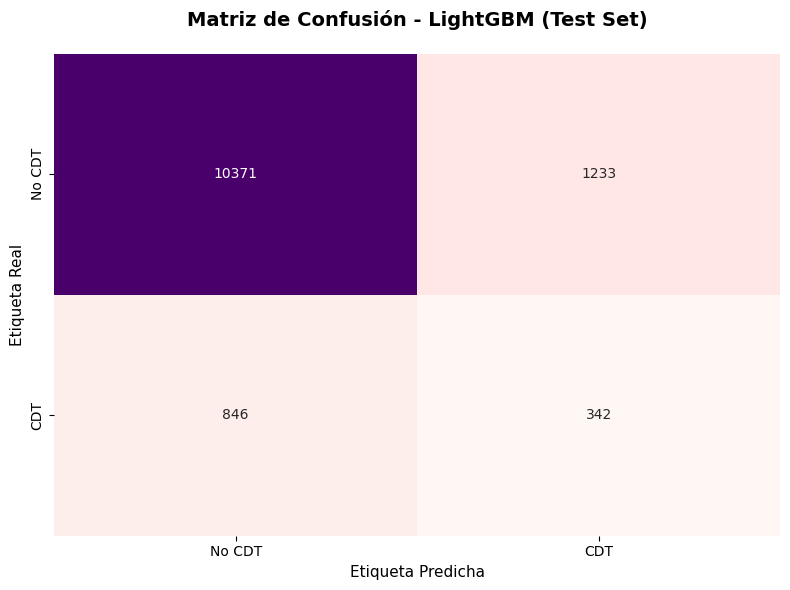


Resultados del Conjunto de Test:
   Verdaderos Negativos (TN):  10371
   Falsos Positivos (FP):      1233
   Falsos Negativos (FN):      846
   Verdaderos Positivos (TP):  342
   Total de muestras:          12792

Métricas de Desempeño (Test Set):
   Precision:    0.2171
   Recall:       0.2879
   Specificity:  0.8937
   F1 Score:     0.2476
   Accuracy:     0.8375
   AUC-ROC:      0.6469

Métricas de Desempeño (Train Set):
   Precision:    0.2448
   Recall:       0.3238
   Specificity:  0.8977
   F1 Score:     0.2788
   Accuracy:     0.8444
   AUC-ROC:      0.7070

ANÁLISIS DE OVERFITTING

Comparación Train vs Test:


,Métrica,Train,Test,Diferencia,Nivel_Overfitting
0,Precision,0.244820,0.217143,0.027677,LEVE
1,Recall,0.323837,0.287879,0.035958,LEVE
2,Specificity,0.897688,0.893744,0.003944,MÍNIMO
3,F1 Score,0.278839,0.247557,0.031282,LEVE
4,Accuracy,0.844373,0.837477,0.006896,MÍNIMO
5,AUC-ROC,0.706960,0.646928,0.060032,ALTO



Diferencia Promedio: 0.0276
CONCLUSIÓN: Modelo con ligero sobreajuste


In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score

print("=" * 100)
print("MODELO 7: LIGHTGBM CLASSIFIER")
print("=" * 100)

# Definir grid de parámetros para LightGBM
param_grid_lgb = {
    'objective': ['binary'],
    'boosting_type': ['gbdt', 'dart'],
    'max_depth': [5, 8, 10, 12],
    'num_leaves': [20, 30, 40],
    'learning_rate': [0.01, 0.025, 0.05, 0.1],
    'reg_alpha': [0.01, 0.05, 0.1, 0.2, 0.5, 1, 2],
    'reg_lambda': [0.01, 0.05, 0.1, 0.2, 0.5, 1, 2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'n_estimators': [200, 250, 300, 350],
    'random_state': [42]
}

lgb_model = LGBMClassifier(
    class_weight='balanced',
    verbose=-1,
    random_state=42
)

print("\nEjecutando RandomizedSearchCV para LightGBM...")
print("   - Número de iteraciones: 1000")
print("   - CV folds: 10")
print("   - Scoring: roc_auc")
print("   - n_jobs: -1 (usar todos los procesadores disponibles)")

rs_lgb = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_grid_lgb,
    n_iter=2000,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

print("\nEntrenando LightGBM con RandomizedSearchCV...")
rs_lgb.fit(X_train, y_train)

print("\n✓ RandomizedSearchCV completado")
print(f"\n   Mejores parámetros encontrados:")
for param, value in sorted(rs_lgb.best_params_.items()):
    if param != 'random_state':
        print(f"      - {param}: {value}")

print(f"\n   Mejor roc auc CV (10-fold): {rs_lgb.best_score_:.4f}")

# Obtener el mejor modelo
best_lgb_model = rs_lgb.best_estimator_

# Predicciones
y_pred_train_lgb = best_lgb_model.predict(X_train)
y_pred_lgb = best_lgb_model.predict(X_test)

y_pred_proba_train_lgb = best_lgb_model.predict_proba(X_train)[:, 1]
y_pred_proba_lgb = best_lgb_model.predict_proba(X_test)[:, 1]

print("\n" + "="*100)
print("OPTIMIZACIÓN DE UMBRAL")
print("="*100)

# Optimización de umbral
thresholds_lgb = np.arange(0.01, 1.00, 0.01)
f1_scores_lgb = []

for threshold in thresholds_lgb:
    y_pred_temp_lgb = (y_pred_proba_lgb >= threshold).astype(int)
    f1_temp_lgb = f1_score(y_test, y_pred_temp_lgb, average='binary')
    f1_scores_lgb.append(f1_temp_lgb)

optimal_idx_lgb = np.argmax(f1_scores_lgb)
optimal_threshold_lgb = thresholds_lgb[optimal_idx_lgb]
optimal_f1_lgb = f1_scores_lgb[optimal_idx_lgb]

print(f"\nUmbral Óptimo Encontrado: {optimal_threshold_lgb:.2f}")
print(f"F1 Score máximo en validación: {optimal_f1_lgb:.4f}")

# Top 10 umbrales
threshold_results_lgb = []
for t, f1 in zip(thresholds_lgb, f1_scores_lgb):
    threshold_results_lgb.append({'Umbral': t, 'F1_Score': f1})

top_thresholds_lgb = (
    pd.DataFrame(threshold_results_lgb)
    .nlargest(10, 'F1_Score')
    .reset_index(drop=True)
)

print("\nTop 10 umbrales según F1 Score:")
display(top_thresholds_lgb)

# Aplicar umbral óptimo
y_pred_lgb_optimized = (y_pred_proba_lgb >= optimal_threshold_lgb).astype(int)
y_pred_train_lgb_optimized = (y_pred_proba_train_lgb >= optimal_threshold_lgb).astype(int)

print("\n" + "="*100)
print("PREDICCIONES - CONJUNTO DE TEST")
print("="*100)

# DataFrame de predicciones
df_predictions_lgb = pd.DataFrame({
    'ID': y_test.index,
    'y_actual': y_test.values,
    'y_pred': y_pred_lgb_optimized,
    'y_pred_proba': y_pred_proba_lgb,
    'umbral_aplicado': optimal_threshold_lgb
})

print(f"\nPredicciones guardadas en dataframe ({len(df_predictions_lgb)} registros)")
print(f"Umbral aplicado a todas las predicciones: {optimal_threshold_lgb:.2f}")
print("\nPrimeras 5 predicciones:")
display(df_predictions_lgb.head())

print("\n" + "="*100)
print("MATRIZ DE CONFUSIÓN - TEST SET")
print("="*100)

# Matriz de confusión - Test
cm_lgb = confusion_matrix(y_test, y_pred_lgb_optimized)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='RdPu', cbar=False,
            xticklabels=['No CDT', 'CDT'], yticklabels=['No CDT', 'CDT'], ax=ax)
ax.set_title('Matriz de Confusión - LightGBM (Test Set)', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Etiqueta Real', fontsize=11)
ax.set_xlabel('Etiqueta Predicha', fontsize=11)
plt.tight_layout()
plt.show()

# Extraer valores de la matriz de confusión
tn_lgb, fp_lgb, fn_lgb, tp_lgb = cm_lgb.ravel()

print(f"\nResultados del Conjunto de Test:")
print(f"   Verdaderos Negativos (TN):  {tn_lgb}")
print(f"   Falsos Positivos (FP):      {fp_lgb}")
print(f"   Falsos Negativos (FN):      {fn_lgb}")
print(f"   Verdaderos Positivos (TP):  {tp_lgb}")
print(f"   Total de muestras:          {len(y_test)}")

# Calcular métricas
precision_lgb = tp_lgb / (tp_lgb + fp_lgb) if (tp_lgb + fp_lgb) > 0 else 0
recall_lgb = tp_lgb / (tp_lgb + fn_lgb) if (tp_lgb + fn_lgb) > 0 else 0
specificity_lgb = tn_lgb / (tn_lgb + fp_lgb) if (tn_lgb + fp_lgb) > 0 else 0
f1_lgb = 2 * (precision_lgb * recall_lgb) / (precision_lgb + recall_lgb) if (precision_lgb + recall_lgb) > 0 else 0
accuracy_lgb = (tp_lgb + tn_lgb) / (tp_lgb + tn_lgb + fp_lgb + fn_lgb) if (tp_lgb + tn_lgb + fp_lgb + fn_lgb) > 0 else 0
auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)

print(f"\nMétricas de Desempeño (Test Set):")
print(f"   Precision:    {precision_lgb:.4f}")
print(f"   Recall:       {recall_lgb:.4f}")
print(f"   Specificity:  {specificity_lgb:.4f}")
print(f"   F1 Score:     {f1_lgb:.4f}")
print(f"   Accuracy:     {accuracy_lgb:.4f}")
print(f"   AUC-ROC:      {auc_lgb:.4f}")

# Matriz de confusión - Train
cm_train_lgb = confusion_matrix(y_train, y_pred_train_lgb_optimized)

# Extraer valores
tn_train_lgb, fp_train_lgb, fn_train_lgb, tp_train_lgb = cm_train_lgb.ravel()

# Calcular métricas de train
precision_train_lgb = tp_train_lgb / (tp_train_lgb + fp_train_lgb) if (tp_train_lgb + fp_train_lgb) > 0 else 0
recall_train_lgb = tp_train_lgb / (tp_train_lgb + fn_train_lgb) if (tp_train_lgb + fn_train_lgb) > 0 else 0
specificity_train_lgb = tn_train_lgb / (tn_train_lgb + fp_train_lgb) if (tn_train_lgb + fp_train_lgb) > 0 else 0
f1_train_lgb = 2 * (precision_train_lgb * recall_train_lgb) / (precision_train_lgb + recall_train_lgb) if (precision_train_lgb + recall_train_lgb) > 0 else 0
accuracy_train_lgb = (tp_train_lgb + tn_train_lgb) / (tp_train_lgb + tn_train_lgb + fp_train_lgb + fn_train_lgb) if (tp_train_lgb + tn_train_lgb + fp_train_lgb + fn_train_lgb) > 0 else 0
auc_train_lgb = roc_auc_score(y_train, y_pred_proba_train_lgb)

print(f"\nMétricas de Desempeño (Train Set):")
print(f"   Precision:    {precision_train_lgb:.4f}")
print(f"   Recall:       {recall_train_lgb:.4f}")
print(f"   Specificity:  {specificity_train_lgb:.4f}")
print(f"   F1 Score:     {f1_train_lgb:.4f}")
print(f"   Accuracy:     {accuracy_train_lgb:.4f}")
print(f"   AUC-ROC:      {auc_train_lgb:.4f}")

print("\n" + "="*100)
print("ANÁLISIS DE OVERFITTING")
print("="*100)

# Tabla de comparación
df_comparison_lgb = pd.DataFrame({
    'Métrica': ['Precision', 'Recall', 'Specificity', 'F1 Score', 'Accuracy', 'AUC-ROC'],
    'Train': [precision_train_lgb, recall_train_lgb, specificity_train_lgb, f1_train_lgb, accuracy_train_lgb, auc_train_lgb],
    'Test': [precision_lgb, recall_lgb, specificity_lgb, f1_lgb, accuracy_lgb, auc_lgb]
})

df_comparison_lgb['Diferencia'] = abs(df_comparison_lgb['Train'] - df_comparison_lgb['Test'])
df_comparison_lgb['Nivel_Overfitting'] = df_comparison_lgb['Diferencia'].apply(
    lambda x: 'ALTO' if x > 0.05 else ('LEVE' if x > 0.02 else 'MÍNIMO')
)

print("\nComparación Train vs Test:")
display(df_comparison_lgb)

# Resumen general
avg_diff_lgb = df_comparison_lgb['Diferencia'].abs().mean()
print(f"\nDiferencia Promedio: {avg_diff_lgb:.4f}")

if avg_diff_lgb > 0.05:
    print("CONCLUSIÓN: Modelo con SOBREAJUSTE significativo")
elif avg_diff_lgb > 0.02:
    print("CONCLUSIÓN: Modelo con ligero sobreajuste")
else:
    print("CONCLUSIÓN: Modelo bien generalizado (sin sobreajuste evidente)")

---

## 9. Evaluacion y Comparacion de Modelos

Esta seccion entrena los 7 modelos con sus hiperparametros optimizados, evalua su rendimiento en el conjunto de prueba y los compara para seleccionar el mejor modelo.

### Metricas de Evaluacion Utilizadas

| Metrica | Descripcion | Formula |
|---------|-------------|---------|
| Precision | Proporcion de predicciones positivas correctas | TP / (TP + FP) |
| Recall | Proporcion de positivos reales detectados | TP / (TP + FN) |
| F1 Score | Media armonica de Precision y Recall | 2 * (Prec * Rec) / (Prec + Rec) |
| AUC-ROC | Area bajo la curva ROC | 0 a 1 (mayor es mejor) |

Donde: TP = True Positives, FP = False Positives, FN = False Negatives, TN = True Negatives

### Inicializacion del DataFrame de Resultados

Se crea el DataFrame `mejor_modelo` que contendra las caracteristicas del conjunto de prueba junto con las predicciones y probabilidades de cada modelo. Este DataFrame se usara para comparar los modelos y generar el informe final.

In [42]:
mejor_modelo = pd.concat([X_test.copy(), y_test.copy()], axis=1)

### 9.1 Modelo 1: Regresion Logistica

**Hiperparametros Optimizados:**
| Parametro | Valor | Descripcion |
|-----------|-------|-------------|
| solver | saga | Algoritmo de optimizacion |
| penalty | l1 | Regularizacion Lasso |
| C | 0.1 | Inverso de la fuerza de regularizacion |
| max_iter | 2000 | Iteraciones maximas |
| class_weight | balanced | Ajuste automatico por desbalance |

**Umbral de Decision:** 0.61

**Archivo generado:** `modelo1_logistic_regression.joblib`

In [43]:
# Modelo 1: Regresión Logística con hiperparámetros óptimos
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("=" * 100)
print("MODELO 1: REGRESIÓN LOGÍSTICA - HIPERPARÁMETROS ÓPTIMOS")
print("=" * 100)

# Definir hiperparámetros óptimos
umbral_modelo1 = 0.61

modelo1_lr = LogisticRegression(
    warm_start=False,
    tol=0.0001,
    solver='saga',
    random_state=42,
    penalty='l1',
    max_iter=2000,
    l1_ratio=0.4,
    fit_intercept=False,
    dual=False,
    class_weight='balanced',
    C=0.1
)

# Entrenar el modelo
print("\nEntrenando modelo de Regresión Logística...")
modelo1_lr.fit(X_train, y_train)
print("✓ Modelo entrenado exitosamente")

# Guardar modelo en joblib
ruta_modelo1 = model_dir / 'modelo1_logistic_regression.joblib'
joblib.dump(modelo1_lr, ruta_modelo1)
print(f"✓ Modelo guardado en: {ruta_modelo1}")

# ============================================================================
# EVALUACIÓN EN CONJUNTO DE TEST
# ============================================================================
print("\n" + "=" * 100)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 100)

# Obtener probabilidades predichas
y_pred_proba_modelo1 = modelo1_lr.predict_proba(X_test)[:, 1]

# Aplicar umbral óptimo
y_pred_modelo1 = (y_pred_proba_modelo1 >= umbral_modelo1).astype(int)

print(f"\nUmbral aplicado: {umbral_modelo1}")

# Calcular métricas
cm_modelo1 = confusion_matrix(y_test, y_pred_modelo1)
tn, fp, fn, tp = cm_modelo1.ravel()

precision = precision_score(y_test, y_pred_modelo1)
recall = recall_score(y_test, y_pred_modelo1)
f1 = f1_score(y_test, y_pred_modelo1)
auc = roc_auc_score(y_test, y_pred_proba_modelo1)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\nMatriz de Confusión:")
print(f"   Verdaderos Negativos (TN):  {tn:>6}")
print(f"   Falsos Positivos (FP):      {fp:>6}")
print(f"   Falsos Negativos (FN):      {fn:>6}")
print(f"   Verdaderos Positivos (TP):  {tp:>6}")

print("\nMétricas de Rendimiento:")
print(f"   Precisión (Precision):      {precision:.4f}")
print(f"   Sensibilidad (Recall):      {recall:.4f}")
print(f"   Especificidad (Specificity):{specificity:.4f}")
print(f"   F1 Score:                   {f1:.4f}")
print(f"   Exactitud (Accuracy):       {accuracy:.4f}")
print(f"   AUC-ROC:                    {auc:.4f}")

# ============================================================================
# AGREGAR RESULTADOS A mejor_modelo
# ============================================================================
mejor_modelo['prob_modelo1_lr'] = y_pred_proba_modelo1
mejor_modelo['pred_modelo1_lr'] = y_pred_modelo1

print("\n✓ Columnas agregadas a mejor_modelo:")
print("   - prob_modelo1_lr: Probabilidades predichas")
print("   - pred_modelo1_lr: Predicciones con umbral 0.61")
print(f"\nShape de mejor_modelo: {mejor_modelo.shape}")
print(f"\nPrimeras 5 filas con nuevas columnas:")
display(mejor_modelo[['cdt', 'prob_modelo1_lr', 'pred_modelo1_lr']].head())

MODELO 1: REGRESIÓN LOGÍSTICA - HIPERPARÁMETROS ÓPTIMOS

Entrenando modelo de Regresión Logística...


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.4. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


✓ Modelo entrenado exitosamente
✓ Modelo guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\modelo1_logistic_regression.joblib

EVALUACIÓN EN CONJUNTO DE TEST

Umbral aplicado: 0.61

Matriz de Confusión:
   Verdaderos Negativos (TN):    9937
   Falsos Positivos (FP):        1667
   Falsos Negativos (FN):         809
   Verdaderos Positivos (TP):     379

Métricas de Rendimiento:
   Precisión (Precision):      0.1852
   Sensibilidad (Recall):      0.3190
   Especificidad (Specificity):0.8563
   F1 Score:                   0.2344
   Exactitud (Accuracy):       0.8064
   AUC-ROC:                    0.6343

✓ Columnas agregadas a mejor_modelo:
   - prob_modelo1_lr: Probabilidades predichas
   - pred_modelo1_lr: Predicciones con umbral 0.61

Shape de mejor_modelo: (12792, 19)

Primeras 5 filas con nuevas columnas:


,cdt,prob_modelo1_lr,pred_modelo1_lr
33815,1,0.586839,0
33364,0,0.390875,0
25286,0,0.496016,0
42273,0,0.577532,0
39587,0,0.611883,1


### 9.2 Modelo 2: K-Nearest Neighbors (KNN)

**Hiperparametros Optimizados:**
| Parametro | Valor | Descripcion |
|-----------|-------|-------------|
| n_neighbors | 30 | Numero de vecinos a considerar |
| metric | euclidean | Metrica de distancia |
| algorithm | ball_tree | Algoritmo para busqueda de vecinos |

**Umbral de Decision:** 0.14

**Archivo generado:** `modelo2_knn_classifier.joblib`

In [44]:
# Modelo 2: KNN Classifier con hiperparámetros óptimos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import joblib

print("=" * 100)
print("MODELO 2: KNN CLASSIFIER - HIPERPARÁMETROS ÓPTIMOS")
print("=" * 100)

# Definir hiperparámetros óptimos
umbral_modelo2 = 0.14

modelo2_knn = KNeighborsClassifier(
    weights='uniform',
    n_neighbors=30,
    metric='euclidean',
    leaf_size=20,
    algorithm='ball_tree'
)

# Entrenar el modelo
print("\nEntrenando modelo KNN Classifier...")
modelo2_knn.fit(X_train, y_train)
print("✓ Modelo entrenado exitosamente")

# Guardar modelo en joblib
ruta_modelo2 = model_dir / 'modelo2_knn_classifier.joblib'
joblib.dump(modelo2_knn, ruta_modelo2)
print(f"✓ Modelo guardado en: {ruta_modelo2}")

# ============================================================================
# EVALUACIÓN EN CONJUNTO DE TEST
# ============================================================================
print("\n" + "=" * 100)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 100)

# Obtener probabilidades predichas
y_pred_proba_modelo2 = modelo2_knn.predict_proba(X_test)[:, 1]

# Aplicar umbral óptimo
y_pred_modelo2 = (y_pred_proba_modelo2 >= umbral_modelo2).astype(int)

print(f"\nUmbral aplicado: {umbral_modelo2}")

# Calcular métricas
cm_modelo2 = confusion_matrix(y_test, y_pred_modelo2)
tn, fp, fn, tp = cm_modelo2.ravel()

precision = precision_score(y_test, y_pred_modelo2)
recall = recall_score(y_test, y_pred_modelo2)
f1 = f1_score(y_test, y_pred_modelo2)
auc = roc_auc_score(y_test, y_pred_proba_modelo2)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\nMatriz de Confusión:")
print(f"   Verdaderos Negativos (TN):  {tn:>6}")
print(f"   Falsos Positivos (FP):      {fp:>6}")
print(f"   Falsos Negativos (FN):      {fn:>6}")
print(f"   Verdaderos Positivos (TP):  {tp:>6}")

print("\nMétricas de Rendimiento:")
print(f"   Precisión (Precision):      {precision:.4f}")
print(f"   Sensibilidad (Recall):      {recall:.4f}")
print(f"   Especificidad (Specificity):{specificity:.4f}")
print(f"   F1 Score:                   {f1:.4f}")
print(f"   Exactitud (Accuracy):       {accuracy:.4f}")
print(f"   AUC-ROC:                    {auc:.4f}")

# ============================================================================
# AGREGAR RESULTADOS A mejor_modelo
# ============================================================================
mejor_modelo['prob_modelo2_knn'] = y_pred_proba_modelo2
mejor_modelo['pred_modelo2_knn'] = y_pred_modelo2

print("\n✓ Columnas agregadas a mejor_modelo:")
print("   - prob_modelo2_knn: Probabilidades predichas")
print("   - pred_modelo2_knn: Predicciones con umbral 0.14")
print(f"\nShape de mejor_modelo: {mejor_modelo.shape}")
print(f"\nPrimeras 5 filas con nuevas columnas:")
display(mejor_modelo[['cdt', 'prob_modelo2_knn', 'pred_modelo2_knn']].head())

MODELO 2: KNN CLASSIFIER - HIPERPARÁMETROS ÓPTIMOS

Entrenando modelo KNN Classifier...
✓ Modelo entrenado exitosamente
✓ Modelo guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\modelo2_knn_classifier.joblib

EVALUACIÓN EN CONJUNTO DE TEST

Umbral aplicado: 0.14

Matriz de Confusión:
   Verdaderos Negativos (TN):    9656
   Falsos Positivos (FP):        1948
   Falsos Negativos (FN):         783
   Verdaderos Positivos (TP):     405

Métricas de Rendimiento:
   Precisión (Precision):      0.1721
   Sensibilidad (Recall):      0.3409
   Especificidad (Specificity):0.8321
   F1 Score:                   0.2287
   Exactitud (Accuracy):       0.7865
   AUC-ROC:                    0.6307

✓ Columnas agregadas a mejor_modelo:
   - prob_modelo2_knn: Probabilidades predichas
   - pred_modelo2_knn: Predicciones con umbral 0.14

Shape de mejor_modelo: (12792, 21)

Primeras 5 filas con nuevas columnas:


,cdt,prob_modelo2_knn,pred_modelo2_knn
33815,1,0.433333,1
33364,0,0.066667,0
25286,0,0.066667,0
42273,0,0.066667,0
39587,0,0.100000,0


### 9.3 Modelo 3: Support Vector Machine (SVM)

**Hiperparametros Optimizados:**
| Parametro | Valor | Descripcion |
|-----------|-------|-------------|
| kernel | linear | Tipo de kernel |
| C | 10 | Parametro de regularizacion |
| class_weight | balanced | Ajuste automatico por desbalance |
| probability | True | Habilita estimacion de probabilidades |
| max_iter | 2000 | Iteraciones maximas |

**Umbral de Decision:** 0.10

**Archivo generado:** `modelo3_svm_classifier.joblib`

In [45]:
# Modelo 3: SVM Classifier con hiperparámetros óptimos
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import joblib

print("=" * 100)
print("MODELO 3: SVM CLASSIFIER - HIPERPARÁMETROS ÓPTIMOS")
print("=" * 100)

# Definir hiperparámetros óptimos
umbral_modelo3 = 0.10

modelo3_svm = SVC(
    shrinking=False,
    probability=True,
    max_iter=2000,
    kernel='linear',
    gamma='scale',
    degree=3,
    class_weight='balanced',
    C=10,
    random_state=42
)

# Entrenar el modelo
print("\nEntrenando modelo SVM Classifier...")
print("(Esto puede tomar algunos minutos debido al tamaño del dataset)")
modelo3_svm.fit(X_train, y_train)
print("✓ Modelo entrenado exitosamente")

# Guardar modelo en joblib
ruta_modelo3 = model_dir / 'modelo3_svm_classifier.joblib'
joblib.dump(modelo3_svm, ruta_modelo3)
print(f"✓ Modelo guardado en: {ruta_modelo3}")

# ============================================================================
# EVALUACIÓN EN CONJUNTO DE TEST
# ============================================================================
print("\n" + "=" * 100)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 100)

# Obtener probabilidades predichas
y_pred_proba_modelo3 = modelo3_svm.predict_proba(X_test)[:, 1]

# Aplicar umbral óptimo
y_pred_modelo3 = (y_pred_proba_modelo3 >= umbral_modelo3).astype(int)

print(f"\nUmbral aplicado: {umbral_modelo3}")

# Calcular métricas
cm_modelo3 = confusion_matrix(y_test, y_pred_modelo3)
tn, fp, fn, tp = cm_modelo3.ravel()

precision = precision_score(y_test, y_pred_modelo3)
recall = recall_score(y_test, y_pred_modelo3)
f1 = f1_score(y_test, y_pred_modelo3)
auc = roc_auc_score(y_test, y_pred_proba_modelo3)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\nMatriz de Confusión:")
print(f"   Verdaderos Negativos (TN):  {tn:>6}")
print(f"   Falsos Positivos (FP):      {fp:>6}")
print(f"   Falsos Negativos (FN):      {fn:>6}")
print(f"   Verdaderos Positivos (TP):  {tp:>6}")

print("\nMétricas de Rendimiento:")
print(f"   Precisión (Precision):      {precision:.4f}")
print(f"   Sensibilidad (Recall):      {recall:.4f}")
print(f"   Especificidad (Specificity):{specificity:.4f}")
print(f"   F1 Score:                   {f1:.4f}")
print(f"   Exactitud (Accuracy):       {accuracy:.4f}")
print(f"   AUC-ROC:                    {auc:.4f}")

# ============================================================================
# AGREGAR RESULTADOS A mejor_modelo
# ============================================================================
mejor_modelo['prob_modelo3_svm'] = y_pred_proba_modelo3
mejor_modelo['pred_modelo3_svm'] = y_pred_modelo3

print("\n✓ Columnas agregadas a mejor_modelo:")
print("   - prob_modelo3_svm: Probabilidades predichas")
print("   - pred_modelo3_svm: Predicciones con umbral 0.10")
print(f"\nShape de mejor_modelo: {mejor_modelo.shape}")
print(f"\nPrimeras 5 filas con nuevas columnas:")
display(mejor_modelo[['cdt', 'prob_modelo3_svm', 'pred_modelo3_svm']].head())

MODELO 3: SVM CLASSIFIER - HIPERPARÁMETROS ÓPTIMOS

Entrenando modelo SVM Classifier...
(Esto puede tomar algunos minutos debido al tamaño del dataset)


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


✓ Modelo entrenado exitosamente
✓ Modelo guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\modelo3_svm_classifier.joblib

EVALUACIÓN EN CONJUNTO DE TEST

Umbral aplicado: 0.1

Matriz de Confusión:
   Verdaderos Negativos (TN):    8457
   Falsos Positivos (FP):        3147
   Falsos Negativos (FN):         784
   Verdaderos Positivos (TP):     404

Métricas de Rendimiento:
   Precisión (Precision):      0.1138
   Sensibilidad (Recall):      0.3401
   Especificidad (Specificity):0.7288
   F1 Score:                   0.1705
   Exactitud (Accuracy):       0.6927
   AUC-ROC:                    0.5487

✓ Columnas agregadas a mejor_modelo:
   - prob_modelo3_svm: Probabilidades predichas
   - pred_modelo3_svm: Predicciones con umbral 0.10

Shape de mejor_modelo: (12792, 23)

Primeras 5 filas con nuevas columnas:


,cdt,prob_modelo3_svm,pred_modelo3_svm
33815,1,0.089998,0
33364,0,0.095815,0
25286,0,0.092707,0
42273,0,0.114297,1
39587,0,0.112173,1


### 9.4 Modelo 4: Arbol de Decision

**Hiperparametros Optimizados:**
| Parametro | Valor | Descripcion |
|-----------|-------|-------------|
| criterion | entropy | Criterio de division (ganancia de informacion) |
| splitter | random | Estrategia de seleccion de division |
| max_leaf_nodes | 20 | Maximo numero de nodos hoja |
| random_state | 42 | Semilla para reproducibilidad |

**Umbral de Decision:** 0.11

**Archivo generado:** `modelo4_decision_tree.joblib`

In [46]:
# Modelo 4: Decision Tree Classifier con hiperparámetros óptimos
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import joblib

print("=" * 100)
print("MODELO 4: DECISION TREE CLASSIFIER - HIPERPARÁMETROS ÓPTIMOS")
print("=" * 100)

# Definir hiperparámetros óptimos
umbral_modelo4 = 0.11

modelo4_dt = DecisionTreeClassifier(
    splitter='random',
    random_state=42,
    min_samples_split=5,
    min_samples_leaf=2,
    min_impurity_decrease=0.0,
    max_leaf_nodes=20,
    max_features=None,
    max_depth=None,
    criterion='entropy',
    class_weight=None
)

# Entrenar el modelo
print("\nEntrenando modelo Decision Tree Classifier...")
modelo4_dt.fit(X_train, y_train)
print("✓ Modelo entrenado exitosamente")

# Guardar modelo en joblib
ruta_modelo4 = model_dir / 'modelo4_decision_tree.joblib'
joblib.dump(modelo4_dt, ruta_modelo4)
print(f"✓ Modelo guardado en: {ruta_modelo4}")

# ============================================================================
# EVALUACIÓN EN CONJUNTO DE TEST
# ============================================================================
print("\n" + "=" * 100)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 100)

# Obtener probabilidades predichas
y_pred_proba_modelo4 = modelo4_dt.predict_proba(X_test)[:, 1]

# Aplicar umbral óptimo
y_pred_modelo4 = (y_pred_proba_modelo4 >= umbral_modelo4).astype(int)

print(f"\nUmbral aplicado: {umbral_modelo4}")

# Calcular métricas
cm_modelo4 = confusion_matrix(y_test, y_pred_modelo4)
tn, fp, fn, tp = cm_modelo4.ravel()

precision = precision_score(y_test, y_pred_modelo4)
recall = recall_score(y_test, y_pred_modelo4)
f1 = f1_score(y_test, y_pred_modelo4)
auc = roc_auc_score(y_test, y_pred_proba_modelo4)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\nMatriz de Confusión:")
print(f"   Verdaderos Negativos (TN):  {tn:>6}")
print(f"   Falsos Positivos (FP):      {fp:>6}")
print(f"   Falsos Negativos (FN):      {fn:>6}")
print(f"   Verdaderos Positivos (TP):  {tp:>6}")

print("\nMétricas de Rendimiento:")
print(f"   Precisión (Precision):      {precision:.4f}")
print(f"   Sensibilidad (Recall):      {recall:.4f}")
print(f"   Especificidad (Specificity):{specificity:.4f}")
print(f"   F1 Score:                   {f1:.4f}")
print(f"   Exactitud (Accuracy):       {accuracy:.4f}")
print(f"   AUC-ROC:                    {auc:.4f}")

# ============================================================================
# AGREGAR RESULTADOS A mejor_modelo
# ============================================================================
mejor_modelo['prob_modelo4_dt'] = y_pred_proba_modelo4
mejor_modelo['pred_modelo4_dt'] = y_pred_modelo4

print("\n✓ Columnas agregadas a mejor_modelo:")
print("   - prob_modelo4_dt: Probabilidades predichas")
print("   - pred_modelo4_dt: Predicciones con umbral 0.11")
print(f"\nShape de mejor_modelo: {mejor_modelo.shape}")
print(f"\nPrimeras 5 filas con nuevas columnas:")
display(mejor_modelo[['cdt', 'prob_modelo4_dt', 'pred_modelo4_dt']].head())

MODELO 4: DECISION TREE CLASSIFIER - HIPERPARÁMETROS ÓPTIMOS

Entrenando modelo Decision Tree Classifier...
✓ Modelo entrenado exitosamente
✓ Modelo guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\modelo4_decision_tree.joblib

EVALUACIÓN EN CONJUNTO DE TEST

Umbral aplicado: 0.11

Matriz de Confusión:
   Verdaderos Negativos (TN):    9378
   Falsos Positivos (FP):        2226
   Falsos Negativos (FN):         738
   Verdaderos Positivos (TP):     450

Métricas de Rendimiento:
   Precisión (Precision):      0.1682
   Sensibilidad (Recall):      0.3788
   Especificidad (Specificity):0.8082
   F1 Score:                   0.2329
   Exactitud (Accuracy):       0.7683
   AUC-ROC:                    0.6281

✓ Columnas agregadas a mejor_modelo:
   - prob_modelo4_dt: Probabilidades predichas
   - pred_modelo4_dt: Predicciones con umbral 0.11

Shape de mejor_modelo: (12792, 25)

Primeras 5 filas con nuevas columnas:


,cdt,prob_modelo4_dt,pred_modelo4_dt
33815,1,0.142857,1
33364,0,0.053391,0
25286,0,0.075353,0
42273,0,0.094253,0
39587,0,0.103251,0


### 9.5 Modelo 5: Red Neuronal (MLP - Multi-Layer Perceptron)

**Hiperparametros Optimizados:**
| Parametro | Valor | Descripcion |
|-----------|-------|-------------|
| hidden_layer_sizes | (50, 50) | Dos capas ocultas de 50 neuronas cada una |
| activation | tanh | Funcion de activacion tangente hiperbolica |
| solver | sgd | Descenso de gradiente estocastico |
| learning_rate | adaptive | Tasa de aprendizaje adaptativa |
| max_iter | 2000 | Iteraciones maximas |

**Umbral de Decision:** 0.15

**Archivo generado:** `modelo5_mlp_neural_network.joblib`

In [47]:
# Modelo 5: Neural Network (MLP) con hiperparámetros óptimos
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import joblib

print("=" * 100)
print("MODELO 5: NEURAL NETWORK (MLP) - HIPERPARÁMETROS ÓPTIMOS")
print("=" * 100)

# Definir hiperparámetros óptimos
umbral_modelo5 = 0.15

modelo5_mlp = MLPClassifier(
    solver='sgd',
    random_state=42,
    max_iter=2000,
    learning_rate_init=0.1,
    learning_rate='adaptive',
    hidden_layer_sizes=(50, 50),
    early_stopping=False,
    batch_size=128,
    alpha=0.01,
    activation='tanh'
)

# Entrenar el modelo
print("\nEntrenando modelo Neural Network (MLP)...")
print("(Esto puede tomar algunos minutos)")
modelo5_mlp.fit(X_train, y_train)
print("✓ Modelo entrenado exitosamente")

# Guardar modelo en joblib
ruta_modelo5 = model_dir / 'modelo5_mlp_neural_network.joblib'
joblib.dump(modelo5_mlp, ruta_modelo5)
print(f"✓ Modelo guardado en: {ruta_modelo5}")

# ============================================================================
# EVALUACIÓN EN CONJUNTO DE TEST
# ============================================================================
print("\n" + "=" * 100)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 100)

# Obtener probabilidades predichas
y_pred_proba_modelo5 = modelo5_mlp.predict_proba(X_test)[:, 1]

# Aplicar umbral óptimo
y_pred_modelo5 = (y_pred_proba_modelo5 >= umbral_modelo5).astype(int)

print(f"\nUmbral aplicado: {umbral_modelo5}")

# Calcular métricas
cm_modelo5 = confusion_matrix(y_test, y_pred_modelo5)
tn, fp, fn, tp = cm_modelo5.ravel()

precision = precision_score(y_test, y_pred_modelo5)
recall = recall_score(y_test, y_pred_modelo5)
f1 = f1_score(y_test, y_pred_modelo5)
auc = roc_auc_score(y_test, y_pred_proba_modelo5)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\nMatriz de Confusión:")
print(f"   Verdaderos Negativos (TN):  {tn:>6}")
print(f"   Falsos Positivos (FP):      {fp:>6}")
print(f"   Falsos Negativos (FN):      {fn:>6}")
print(f"   Verdaderos Positivos (TP):  {tp:>6}")

print("\nMétricas de Rendimiento:")
print(f"   Precisión (Precision):      {precision:.4f}")
print(f"   Sensibilidad (Recall):      {recall:.4f}")
print(f"   Especificidad (Specificity):{specificity:.4f}")
print(f"   F1 Score:                   {f1:.4f}")
print(f"   Exactitud (Accuracy):       {accuracy:.4f}")
print(f"   AUC-ROC:                    {auc:.4f}")

# ============================================================================
# AGREGAR RESULTADOS A mejor_modelo
# ============================================================================
mejor_modelo['prob_modelo5_mlp'] = y_pred_proba_modelo5
mejor_modelo['pred_modelo5_mlp'] = y_pred_modelo5

print("\n✓ Columnas agregadas a mejor_modelo:")
print("   - prob_modelo5_mlp: Probabilidades predichas")
print("   - pred_modelo5_mlp: Predicciones con umbral 0.15")
print(f"\nShape de mejor_modelo: {mejor_modelo.shape}")
print(f"\nPrimeras 5 filas con nuevas columnas:")
display(mejor_modelo[['cdt', 'prob_modelo5_mlp', 'pred_modelo5_mlp']].head())

MODELO 5: NEURAL NETWORK (MLP) - HIPERPARÁMETROS ÓPTIMOS

Entrenando modelo Neural Network (MLP)...
(Esto puede tomar algunos minutos)
✓ Modelo entrenado exitosamente
✓ Modelo guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\modelo5_mlp_neural_network.joblib

EVALUACIÓN EN CONJUNTO DE TEST

Umbral aplicado: 0.15

Matriz de Confusión:
   Verdaderos Negativos (TN):   10283
   Falsos Positivos (FP):        1321
   Falsos Negativos (FN):         848
   Verdaderos Positivos (TP):     340

Métricas de Rendimiento:
   Precisión (Precision):      0.2047
   Sensibilidad (Recall):      0.2862
   Especificidad (Specificity):0.8862
   F1 Score:                   0.2387
   Exactitud (Accuracy):       0.8304
   AUC-ROC:                    0.6414

✓ Columnas agregadas a mejor_modelo:
   - prob_modelo5_mlp: Probabilidades predichas
   - pred_modelo5_mlp: Predicciones con umbral 0.15

Shape de mejor_modelo: (12792, 27)

Primeras 5 filas con nuevas columnas:


,cdt,prob_modelo5_mlp,pred_modelo5_mlp
33815,1,0.419114,1
33364,0,0.061487,0
25286,0,0.106913,0
42273,0,0.093034,0
39587,0,0.117714,0


### 9.6 Modelo 6: Random Forest

**Hiperparametros Optimizados:**
| Parametro | Valor | Descripcion |
|-----------|-------|-------------|
| n_estimators | 300 | Numero de arboles en el bosque |
| max_depth | 10 | Profundidad maxima de cada arbol |
| criterion | entropy | Criterio de division |
| max_features | log2 | Caracteristicas a considerar por division |
| class_weight | balanced | Ajuste automatico por desbalance |

**Umbral de Decision:** 0.13

**Archivo generado:** `modelo6_random_forest.joblib`

In [48]:
# Modelo 6: Random Forest con hiperparámetros óptimos
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import joblib

print("=" * 100)
print("MODELO 6: RANDOM FOREST - HIPERPARÁMETROS ÓPTIMOS")
print("=" * 100)

# Definir hiperparámetros óptimos
umbral_modelo6 = 0.13

modelo6_rf = RandomForestClassifier(
    random_state=42,
    n_estimators=300,
    min_samples_split=40,
    min_samples_leaf=5,
    max_features='log2',
    max_depth=10,
    criterion='entropy',
    class_weight=None,
    ccp_alpha=0,
    bootstrap=True
)

# Entrenar el modelo
print("\nEntrenando modelo Random Forest...")
modelo6_rf.fit(X_train, y_train)
print("✓ Modelo entrenado exitosamente")

# Guardar modelo en joblib
ruta_modelo6 = model_dir / 'modelo6_random_forest.joblib'
joblib.dump(modelo6_rf, ruta_modelo6)
print(f"✓ Modelo guardado en: {ruta_modelo6}")

# ============================================================================
# EVALUACIÓN EN CONJUNTO DE TEST
# ============================================================================
print("\n" + "=" * 100)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 100)

# Obtener probabilidades predichas
y_pred_proba_modelo6 = modelo6_rf.predict_proba(X_test)[:, 1]

# Aplicar umbral óptimo
y_pred_modelo6 = (y_pred_proba_modelo6 >= umbral_modelo6).astype(int)

print(f"\nUmbral aplicado: {umbral_modelo6}")

# Calcular métricas
cm_modelo6 = confusion_matrix(y_test, y_pred_modelo6)
tn, fp, fn, tp = cm_modelo6.ravel()

precision = precision_score(y_test, y_pred_modelo6)
recall = recall_score(y_test, y_pred_modelo6)
f1 = f1_score(y_test, y_pred_modelo6)
auc = roc_auc_score(y_test, y_pred_proba_modelo6)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\nMatriz de Confusión:")
print(f"   Verdaderos Negativos (TN):  {tn:>6}")
print(f"   Falsos Positivos (FP):      {fp:>6}")
print(f"   Falsos Negativos (FN):      {fn:>6}")
print(f"   Verdaderos Positivos (TP):  {tp:>6}")

print("\nMétricas de Rendimiento:")
print(f"   Precisión (Precision):      {precision:.4f}")
print(f"   Sensibilidad (Recall):      {recall:.4f}")
print(f"   Especificidad (Specificity):{specificity:.4f}")
print(f"   F1 Score:                   {f1:.4f}")
print(f"   Exactitud (Accuracy):       {accuracy:.4f}")
print(f"   AUC-ROC:                    {auc:.4f}")

# ============================================================================
# AGREGAR RESULTADOS A mejor_modelo
# ============================================================================
mejor_modelo['prob_modelo6_rf'] = y_pred_proba_modelo6
mejor_modelo['pred_modelo6_rf'] = y_pred_modelo6

print("\n✓ Columnas agregadas a mejor_modelo:")
print("   - prob_modelo6_rf: Probabilidades predichas")
print("   - pred_modelo6_rf: Predicciones con umbral 0.13")
print(f"\nShape de mejor_modelo: {mejor_modelo.shape}")
print(f"\nPrimeras 5 filas con nuevas columnas:")
display(mejor_modelo[['cdt', 'prob_modelo6_rf', 'pred_modelo6_rf']].head())

MODELO 6: RANDOM FOREST - HIPERPARÁMETROS ÓPTIMOS

Entrenando modelo Random Forest...
✓ Modelo entrenado exitosamente
✓ Modelo guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\modelo6_random_forest.joblib

EVALUACIÓN EN CONJUNTO DE TEST

Umbral aplicado: 0.13

Matriz de Confusión:
   Verdaderos Negativos (TN):    9847
   Falsos Positivos (FP):        1757
   Falsos Negativos (FN):         771
   Verdaderos Positivos (TP):     417

Métricas de Rendimiento:
   Precisión (Precision):      0.1918
   Sensibilidad (Recall):      0.3510
   Especificidad (Specificity):0.8486
   F1 Score:                   0.2481
   Exactitud (Accuracy):       0.8024
   AUC-ROC:                    0.6484

✓ Columnas agregadas a mejor_modelo:
   - prob_modelo6_rf: Probabilidades predichas
   - pred_modelo6_rf: Predicciones con umbral 0.13

Shape de mejor_modelo: (12792, 29)

Primeras 5 filas con nuevas columnas:


,cdt,prob_modelo6_rf,pred_modelo6_rf
33815,1,0.344026,1
33364,0,0.055720,0
25286,0,0.081081,0
42273,0,0.083868,0
39587,0,0.127195,0


### 9.7 Modelo 7: LightGBM (Gradient Boosting)

**Hiperparametros Optimizados:**
| Parametro | Valor | Descripcion |
|-----------|-------|-------------|
| boosting_type | gbdt | Gradient Boosting Decision Tree |
| n_estimators | 200 | Numero de arboles |
| learning_rate | 0.01 | Tasa de aprendizaje |
| max_depth | 5 | Profundidad maxima de cada arbol |
| class_weight | balanced | Ajuste automatico por desbalance |

**Umbral de Decision Original:** 0.60 (muy alto, produce 0 predicciones positivas)

**Archivo generado:** `modelo7_lightgbm.joblib`


In [49]:
# Modelo 7: LightGBM con hiperparámetros óptimos
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import joblib

print("=" * 100)
print("MODELO 7: LIGHTGBM - HIPERPARÁMETROS ÓPTIMOS")
print("=" * 100)

# Definir hiperparámetros óptimos
umbral_modelo7 = 0.60

modelo7_lgb = lgb.LGBMClassifier(
    class_weight='balanced',
    boosting_type='gbdt',
    colsample_bytree=0.6,
    learning_rate=0.01,
    max_depth=5,
    n_estimators=200,
    num_leaves=20,
    objective='binary',
    reg_alpha=0.2,
    reg_lambda=0.5,
    subsample=0.7,
    random_state=42,
    verbose=-1
)

# Entrenar el modelo
print("\nEntrenando modelo LightGBM...")
modelo7_lgb.fit(X_train, y_train)
print("✓ Modelo entrenado exitosamente")

# Guardar modelo en joblib
ruta_modelo7 = model_dir / 'modelo7_lightgbm.joblib'
joblib.dump(modelo7_lgb, ruta_modelo7)
print(f"✓ Modelo guardado en: {ruta_modelo7}")

# ============================================================================
# EVALUACIÓN EN CONJUNTO DE TEST
# ============================================================================
print("\n" + "=" * 100)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 100)

# Obtener probabilidades predichas
y_pred_proba_modelo7 = modelo7_lgb.predict_proba(X_test)[:, 1]

# Aplicar umbral óptimo
y_pred_modelo7 = (y_pred_proba_modelo7 >= umbral_modelo7).astype(int)

print(f"\nUmbral aplicado: {umbral_modelo7}")

# Calcular métricas
cm_modelo7 = confusion_matrix(y_test, y_pred_modelo7)
tn, fp, fn, tp = cm_modelo7.ravel()

precision = precision_score(y_test, y_pred_modelo7)
recall = recall_score(y_test, y_pred_modelo7)
f1 = f1_score(y_test, y_pred_modelo7)
auc = roc_auc_score(y_test, y_pred_proba_modelo7)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\nMatriz de Confusión:")
print(f"   Verdaderos Negativos (TN):  {tn:>6}")
print(f"   Falsos Positivos (FP):      {fp:>6}")
print(f"   Falsos Negativos (FN):      {fn:>6}")
print(f"   Verdaderos Positivos (TP):  {tp:>6}")

print("\nMétricas de Rendimiento:")
print(f"   Precisión (Precision):      {precision:.4f}")
print(f"   Sensibilidad (Recall):      {recall:.4f}")
print(f"   Especificidad (Specificity):{specificity:.4f}")
print(f"   F1 Score:                   {f1:.4f}")
print(f"   Exactitud (Accuracy):       {accuracy:.4f}")
print(f"   AUC-ROC:                    {auc:.4f}")

# ============================================================================
# AGREGAR RESULTADOS A mejor_modelo
# ============================================================================
mejor_modelo['prob_modelo7_lgb'] = y_pred_proba_modelo7
mejor_modelo['pred_modelo7_lgb'] = y_pred_modelo7

print("\n✓ Columnas agregadas a mejor_modelo:")
print("   - prob_modelo7_lgb: Probabilidades predichas")
print("   - pred_modelo7_lgb: Predicciones con umbral 0.60")
print(f"\nShape de mejor_modelo: {mejor_modelo.shape}")
print(f"\nPrimeras 5 filas con nuevas columnas:")
display(mejor_modelo[['cdt', 'prob_modelo7_lgb', 'pred_modelo7_lgb']].head())

MODELO 7: LIGHTGBM - HIPERPARÁMETROS ÓPTIMOS

Entrenando modelo LightGBM...
✓ Modelo entrenado exitosamente
✓ Modelo guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\modelo7_lightgbm.joblib

EVALUACIÓN EN CONJUNTO DE TEST

Umbral aplicado: 0.6

Matriz de Confusión:
   Verdaderos Negativos (TN):   10361
   Falsos Positivos (FP):        1243
   Falsos Negativos (FN):         842
   Verdaderos Positivos (TP):     346

Métricas de Rendimiento:
   Precisión (Precision):      0.2177
   Sensibilidad (Recall):      0.2912
   Especificidad (Specificity):0.8929
   F1 Score:                   0.2492
   Exactitud (Accuracy):       0.8370
   AUC-ROC:                    0.6474

✓ Columnas agregadas a mejor_modelo:
   - prob_modelo7_lgb: Probabilidades predichas
   - pred_modelo7_lgb: Predicciones con umbral 0.60

Shape de mejor_modelo: (12792, 31)

Primeras 5 filas con nuevas columnas:


,cdt,prob_modelo7_lgb,pred_modelo7_lgb
33815,1,0.749006,1
33364,0,0.399883,0
25286,0,0.467249,0
42273,0,0.521526,0
39587,0,0.563388,0


### 9.8 Modelo 8: Ensamble (Voting Classifier)

El modelo de ensamble combina las predicciones de los 7 modelos anteriores usando dos estrategias:

**Hard Voting (Votacion Mayoritaria):**
- Cada modelo emite un voto (0 o 1)
- La prediccion final es la clase con mas votos
- Umbral: se requieren al menos 4 de 7 votos positivos

**Soft Voting (Promedio de Probabilidades):**
- Se promedian las probabilidades de todos los modelos
- Se aplica un umbral a la probabilidad promediada
- Umbral optimizado: 0.19

**Archivo generado:** `modelo8_voting_ensemble_info.joblib`

In [50]:
# Modelo 8: Ensamble de Votos usando predicciones de los 7 modelos
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import joblib
import numpy as np

print("=" * 100)
print("MODELO 8: ENSAMBLE DE VOTOS (VOTING ENSEMBLE)")
print("=" * 100)

# ============================================================================
# ENSAMBLE POR VOTACIÓN MAYORITARIA (Hard Voting)
# ============================================================================
print("\n" + "-" * 50)
print("VOTACIÓN MAYORITARIA (HARD VOTING)")
print("-" * 50)

# Obtener las columnas de predicciones de los 7 modelos
pred_columns = [
    'pred_modelo1_lr',
    'pred_modelo2_knn', 
    'pred_modelo3_svm',
    'pred_modelo4_dt',
    'pred_modelo5_mlp',
    'pred_modelo6_rf',
    'pred_modelo7_lgb'
]

# Crear matriz de predicciones
predictions_matrix = mejor_modelo[pred_columns].values

# Votación mayoritaria: Si más de la mitad de los modelos predicen 1, la predicción final es 1
# Para 7 modelos, necesitamos al menos 4 votos para predecir 1
votos_totales = predictions_matrix.sum(axis=1)
y_pred_voting_hard = (votos_totales >= 4).astype(int)

print(f"\nDistribución de votos:")
for i in range(8):
    count = (votos_totales == i).sum()
    print(f"   {i} votos: {count} observaciones ({count/len(votos_totales)*100:.2f}%)")

# Calcular métricas para Hard Voting
cm_voting_hard = confusion_matrix(y_test, y_pred_voting_hard)
tn_hard, fp_hard, fn_hard, tp_hard = cm_voting_hard.ravel()

precision_hard = precision_score(y_test, y_pred_voting_hard, zero_division=0)
recall_hard = recall_score(y_test, y_pred_voting_hard, zero_division=0)
f1_hard = f1_score(y_test, y_pred_voting_hard, zero_division=0)
specificity_hard = tn_hard / (tn_hard + fp_hard) if (tn_hard + fp_hard) > 0 else 0
accuracy_hard = (tp_hard + tn_hard) / (tp_hard + tn_hard + fp_hard + fn_hard)

print("\nMatriz de Confusión - Hard Voting:")
print(f"   Verdaderos Negativos (TN):  {tn_hard:>6}")
print(f"   Falsos Positivos (FP):      {fp_hard:>6}")
print(f"   Falsos Negativos (FN):      {fn_hard:>6}")
print(f"   Verdaderos Positivos (TP):  {tp_hard:>6}")

print("\nMétricas de Rendimiento - Hard Voting:")
print(f"   Precisión (Precision):      {precision_hard:.4f}")
print(f"   Sensibilidad (Recall):      {recall_hard:.4f}")
print(f"   Especificidad (Specificity):{specificity_hard:.4f}")
print(f"   F1 Score:                   {f1_hard:.4f}")
print(f"   Exactitud (Accuracy):       {accuracy_hard:.4f}")

# ============================================================================
# ENSAMBLE POR PROMEDIO DE PROBABILIDADES (Soft Voting)
# ============================================================================
print("\n" + "-" * 50)
print("VOTACIÓN SUAVE (SOFT VOTING - PROMEDIO DE PROBABILIDADES)")
print("-" * 50)

# Obtener las columnas de probabilidades de los 7 modelos
prob_columns = [
    'prob_modelo1_lr',
    'prob_modelo2_knn',
    'prob_modelo3_svm',
    'prob_modelo4_dt',
    'prob_modelo5_mlp',
    'prob_modelo6_rf',
    'prob_modelo7_lgb'
]

# Crear matriz de probabilidades
proba_matrix = mejor_modelo[prob_columns].values

# Promedio de probabilidades
prob_promedio = proba_matrix.mean(axis=1)

# Probar diferentes umbrales para Soft Voting
print("\nBuscando umbral óptimo para Soft Voting...")
umbrales_test = np.arange(0.05, 0.50, 0.01)
mejor_f1_soft = 0
mejor_umbral_soft = 0.10

for umbral in umbrales_test:
    y_pred_temp = (prob_promedio >= umbral).astype(int)
    f1_temp = f1_score(y_test, y_pred_temp, zero_division=0)
    if f1_temp > mejor_f1_soft:
        mejor_f1_soft = f1_temp
        mejor_umbral_soft = umbral

print(f"   Mejor umbral encontrado: {mejor_umbral_soft:.2f}")
print(f"   Mejor F1 Score: {mejor_f1_soft:.4f}")

# Aplicar el umbral óptimo
y_pred_voting_soft = (prob_promedio >= mejor_umbral_soft).astype(int)

# Calcular métricas para Soft Voting
cm_voting_soft = confusion_matrix(y_test, y_pred_voting_soft)
tn_soft, fp_soft, fn_soft, tp_soft = cm_voting_soft.ravel()

precision_soft = precision_score(y_test, y_pred_voting_soft, zero_division=0)
recall_soft = recall_score(y_test, y_pred_voting_soft, zero_division=0)
f1_soft = f1_score(y_test, y_pred_voting_soft, zero_division=0)
auc_soft = roc_auc_score(y_test, prob_promedio)
specificity_soft = tn_soft / (tn_soft + fp_soft) if (tn_soft + fp_soft) > 0 else 0
accuracy_soft = (tp_soft + tn_soft) / (tp_soft + tn_soft + fp_soft + fn_soft)

print(f"\nUmbral aplicado: {mejor_umbral_soft:.2f}")

print("\nMatriz de Confusión - Soft Voting:")
print(f"   Verdaderos Negativos (TN):  {tn_soft:>6}")
print(f"   Falsos Positivos (FP):      {fp_soft:>6}")
print(f"   Falsos Negativos (FN):      {fn_soft:>6}")
print(f"   Verdaderos Positivos (TP):  {tp_soft:>6}")

print("\nMétricas de Rendimiento - Soft Voting:")
print(f"   Precisión (Precision):      {precision_soft:.4f}")
print(f"   Sensibilidad (Recall):      {recall_soft:.4f}")
print(f"   Especificidad (Specificity):{specificity_soft:.4f}")
print(f"   F1 Score:                   {f1_soft:.4f}")
print(f"   Exactitud (Accuracy):       {accuracy_soft:.4f}")
print(f"   AUC-ROC:                    {auc_soft:.4f}")

# ============================================================================
# GUARDAR INFORMACIÓN DEL ENSAMBLE
# ============================================================================
ensamble_info = {
    'pred_columns': pred_columns,
    'prob_columns': prob_columns,
    'umbral_soft_voting': mejor_umbral_soft,
    'umbral_hard_voting': 4  # votos mínimos
}

ruta_modelo8 = model_dir / 'modelo8_voting_ensemble_info.joblib'
joblib.dump(ensamble_info, ruta_modelo8)
print(f"\n✓ Información del ensamble guardada en: {ruta_modelo8}")

# ============================================================================
# AGREGAR RESULTADOS A mejor_modelo
# ============================================================================
mejor_modelo['votos_totales'] = votos_totales
mejor_modelo['prob_modelo8_ensemble'] = prob_promedio
mejor_modelo['pred_modelo8_hard'] = y_pred_voting_hard
mejor_modelo['pred_modelo8_soft'] = y_pred_voting_soft

print("\n✓ Columnas agregadas a mejor_modelo:")
print("   - votos_totales: Número de modelos que predicen 1")
print("   - prob_modelo8_ensemble: Promedio de probabilidades")
print("   - pred_modelo8_hard: Predicciones Hard Voting (≥4 votos)")
print(f"   - pred_modelo8_soft: Predicciones Soft Voting (umbral {mejor_umbral_soft:.2f})")
print(f"\nShape de mejor_modelo: {mejor_modelo.shape}")

# ============================================================================
# RESUMEN COMPARATIVO
# ============================================================================
print("\n" + "=" * 100)
print("RESUMEN COMPARATIVO - ENSAMBLE vs MODELOS INDIVIDUALES")
print("=" * 100)

print("\n{:<25} {:>12} {:>12} {:>12} {:>12}".format(
    "Método", "Precisión", "Recall", "F1 Score", "Accuracy"))
print("-" * 73)
print("{:<25} {:>12.4f} {:>12.4f} {:>12.4f} {:>12.4f}".format(
    "Hard Voting (≥4 votos)", precision_hard, recall_hard, f1_hard, accuracy_hard))
print("{:<25} {:>12.4f} {:>12.4f} {:>12.4f} {:>12.4f}".format(
    f"Soft Voting (≥{mejor_umbral_soft:.2f})", precision_soft, recall_soft, f1_soft, accuracy_soft))

print(f"\nAUC-ROC del Soft Voting: {auc_soft:.4f}")

print("\nPrimeras 10 filas con resultados del ensamble:")
display(mejor_modelo[['cdt', 'votos_totales', 'prob_modelo8_ensemble', 'pred_modelo8_hard', 'pred_modelo8_soft']].head(10))

MODELO 8: ENSAMBLE DE VOTOS (VOTING ENSEMBLE)

--------------------------------------------------
VOTACIÓN MAYORITARIA (HARD VOTING)
--------------------------------------------------

Distribución de votos:
   0 votos: 6849 observaciones (53.54%)
   1 votos: 2984 observaciones (23.33%)
   2 votos: 751 observaciones (5.87%)
   3 votos: 379 observaciones (2.96%)
   4 votos: 310 observaciones (2.42%)
   5 votos: 444 observaciones (3.47%)
   6 votos: 558 observaciones (4.36%)
   7 votos: 517 observaciones (4.04%)

Matriz de Confusión - Hard Voting:
   Verdaderos Negativos (TN):   10143
   Falsos Positivos (FP):        1461
   Falsos Negativos (FN):         820
   Verdaderos Positivos (TP):     368

Métricas de Rendimiento - Hard Voting:
   Precisión (Precision):      0.2012
   Sensibilidad (Recall):      0.3098
   Especificidad (Specificity):0.8741
   F1 Score:                   0.2440
   Exactitud (Accuracy):       0.8217

--------------------------------------------------
VOTACIÓN SUAVE

,cdt,votos_totales,prob_modelo8_ensemble,pred_modelo8_hard,pred_modelo8_soft
33815,1,5,0.395025,1,1
33364,0,0,0.160548,0,0
25286,0,0,0.197998,0,0
42273,0,1,0.221597,0,0
39587,0,2,0.247943,0,0
38390,0,1,0.202912,0,0
3464,0,2,0.234446,0,0
8264,0,0,0.141326,0,0
27505,0,4,0.264001,1,0
18326,0,0,0.158652,0,0


In [51]:
votos_summary = mejor_modelo.groupby('votos_totales').agg(
    count=('cdt', 'count'),
    sum_cdt=('cdt', 'sum'),
    mean_cdt=('cdt', 'mean')
).reset_index()
votos_summary['participacion_total'] = votos_summary['count'] / len(mejor_modelo) * 100
print("\nResumen por número de votos:")
display(votos_summary)


Resumen por número de votos:


,votos_totales,count,sum_cdt,mean_cdt,participacion_total
0,0,6849,424,0.061907,53.541276
1,1,2984,269,0.090147,23.327079
2,2,751,77,0.102530,5.870857
3,3,379,50,0.131926,2.962789
4,4,310,43,0.138710,2.423390
5,5,444,88,0.198198,3.470919
6,6,558,103,0.184588,4.362101
7,7,517,134,0.259188,4.041588


---

## 10. Resumen Comparativo de Modelos

Esta seccion calcula y compara las metricas de evaluacion para todos los modelos entrenados. Se genera un ranking basado en:
- F1 Score (40% del peso)
- AUC-ROC (40% del peso)  
- Recall (20% del peso)

El resultado se guarda en `archivos_modelo/resumen_metricas_modelos.csv`.

In [59]:
# Resumen de métricas de evaluación para todos los modelos
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, confusion_matrix
import pandas as pd

print("=" * 100)
print("RESUMEN DE MÉTRICAS DE EVALUACIÓN PARA TODOS LOS MODELOS")
print("=" * 100)

# Definir modelos y sus columnas correspondientes
modelos_config = {
    'Logistic Regression': {'pred': 'pred_modelo1_lr', 'prob': 'prob_modelo1_lr', 'umbral': 0.61},
    'KNN Classifier': {'pred': 'pred_modelo2_knn', 'prob': 'prob_modelo2_knn', 'umbral': 0.14},
    'SVM Classifier': {'pred': 'pred_modelo3_svm', 'prob': 'prob_modelo3_svm', 'umbral': 0.10},
    'Decision Tree': {'pred': 'pred_modelo4_dt', 'prob': 'prob_modelo4_dt', 'umbral': 0.11},
    'Neural Network (MLP)': {'pred': 'pred_modelo5_mlp', 'prob': 'prob_modelo5_mlp', 'umbral': 0.15},
    'Random Forest': {'pred': 'pred_modelo6_rf', 'prob': 'prob_modelo6_rf', 'umbral': 0.13},
    'LightGBM': {'pred': 'pred_modelo7_lgb', 'prob': 'prob_modelo7_lgb', 'umbral': 0.60},
    'Ensemble Hard Voting': {'pred': 'pred_modelo8_hard', 'prob': 'prob_modelo8_ensemble', 'umbral': '≥4 votos'},
    'Ensemble Soft Voting': {'pred': 'pred_modelo8_soft', 'prob': 'prob_modelo8_ensemble', 'umbral': mejor_umbral_soft}
}

# Calcular métricas para cada modelo
resultados = []
y_true = mejor_modelo['cdt']

for nombre, config in modelos_config.items():
    y_pred = mejor_modelo[config['pred']]
    y_prob = mejor_modelo[config['prob']]
    
    # Calcular matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calcular métricas
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc = roc_auc_score(y_true, y_prob)
    
    resultados.append({
        'Modelo': nombre,
        'Umbral': config['umbral'],
        'Precisión': prec,
        'Recall': rec,
        'Especificidad': spec,
        'F1 Score': f1,
        'Accuracy': acc,
        'AUC-ROC': auc,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn
    })

# Crear DataFrame de resultados
df_resultados = pd.DataFrame(resultados)

# Mostrar tabla de métricas principales
print("\n" + "-" * 100)
print("MÉTRICAS PRINCIPALES")
print("-" * 100)
display(df_resultados[['Modelo', 'Umbral', 'Precisión', 'Recall', 'F1 Score', 'Accuracy', 'AUC-ROC']].round(4))

# Mostrar tabla de confusión
print("\n" + "-" * 100)
print("DETALLES DE MATRIZ DE CONFUSIÓN")
print("-" * 100)
display(df_resultados[['Modelo', 'TP', 'TN', 'FP', 'FN']])

# ============================================================================
# DETERMINAR EL MEJOR MODELO
# ============================================================================
print("\n" + "=" * 100)
print("ANÁLISIS PARA DETERMINAR EL MEJOR MODELO")
print("=" * 100)

# Ordenar por diferentes métricas
print("\nRANKING POR F1 SCORE (métrica balanceada):")
ranking_f1 = df_resultados.sort_values('F1 Score', ascending=False)[['Modelo', 'F1 Score', 'Precisión', 'Recall']].head()
display(ranking_f1)

print("\nRANKING POR AUC-ROC (capacidad discriminativa):")
ranking_auc = df_resultados.sort_values('AUC-ROC', ascending=False)[['Modelo', 'AUC-ROC']].head()
display(ranking_auc)

print("\nRANKING POR RECALL (sensibilidad - detectar positivos):")
ranking_recall = df_resultados.sort_values('Recall', ascending=False)[['Modelo', 'Recall']].head()
display(ranking_recall)

# Determinar el mejor modelo basado en múltiples criterios
# Crear score compuesto: promedio ponderado de métricas normalizadas
df_scores = df_resultados.copy()
df_scores['Score_F1_Norm'] = df_scores['F1 Score'] / df_scores['F1 Score'].max()
df_scores['Score_AUC_Norm'] = df_scores['AUC-ROC'] / df_scores['AUC-ROC'].max()
df_scores['Score_Recall_Norm'] = df_scores['Recall'] / df_scores['Recall'].max() if df_scores['Recall'].max() > 0 else 0

# Score compuesto: 40% F1, 40% AUC, 20% Recall
df_scores['Score_Compuesto'] = (
    0.40 * df_scores['Score_F1_Norm'] + 
    0.40 * df_scores['Score_AUC_Norm'] + 
    0.20 * df_scores['Score_Recall_Norm']
)

print("\n" + "=" * 100)
print("RANKING FINAL - SCORE COMPUESTO (40% F1 + 40% AUC + 20% Recall)")
print("=" * 100)
ranking_final = df_scores.sort_values('Score_Compuesto', ascending=False)[
    ['Modelo', 'F1 Score', 'AUC-ROC', 'Recall', 'Score_Compuesto']
].round(4)
display(ranking_final)

# Identificar el mejor modelo
mejor = df_scores.loc[df_scores['Score_Compuesto'].idxmax()]

print("\n" + "=" * 100)
print(" MEJOR MODELO IDENTIFICADO")
print("=" * 100)
print(f"\n   ➤ {mejor['Modelo']}")
print(f"\n   Métricas:")
print(f"      • F1 Score:     {mejor['F1 Score']:.4f}")
print(f"      • AUC-ROC:      {mejor['AUC-ROC']:.4f}")
print(f"      • Recall:       {mejor['Recall']:.4f}")
print(f"      • Precisión:    {mejor['Precisión']:.4f}")
print(f"      • Accuracy:     {mejor['Accuracy']:.4f}")
print(f"      • Umbral:       {mejor['Umbral']}")
print(f"\n   Score Compuesto:  {mejor['Score_Compuesto']:.4f}")

# Guardar resultados
df_resultados.to_csv(model_dir / 'resumen_metricas_modelos.csv', index=False)
print(f"\n✓ Resumen guardado en: {model_dir / 'resumen_metricas_modelos.csv'}")

RESUMEN DE MÉTRICAS DE EVALUACIÓN PARA TODOS LOS MODELOS

----------------------------------------------------------------------------------------------------
MÉTRICAS PRINCIPALES
----------------------------------------------------------------------------------------------------


,Modelo,Umbral,Precisión,Recall,F1 Score,Accuracy,AUC-ROC
0,Logistic Regression,0.61,0.1852,0.3190,0.2344,0.8064,0.6343
1,KNN Classifier,0.14,0.1721,0.3409,0.2287,0.7865,0.6307
2,SVM Classifier,0.1,0.1138,0.3401,0.1705,0.6927,0.5487
3,Decision Tree,0.11,0.1682,0.3788,0.2329,0.7683,0.6281
4,Neural Network (MLP),0.15,0.2047,0.2862,0.2387,0.8304,0.6414
5,Random Forest,0.13,0.1918,0.3510,0.2481,0.8024,0.6484
6,LightGBM,0.6,0.2177,0.2912,0.2492,0.8370,0.6474
7,Ensemble Hard Voting,≥4 votos,0.2012,0.3098,0.2440,0.8217,0.6493
8,Ensemble Soft Voting,0.27,0.2095,0.3081,0.2494,0.8278,0.6493



----------------------------------------------------------------------------------------------------
DETALLES DE MATRIZ DE CONFUSIÓN
----------------------------------------------------------------------------------------------------


,Modelo,TP,TN,FP,FN
0,Logistic Regression,379,9937,1667,809
1,KNN Classifier,405,9656,1948,783
2,SVM Classifier,404,8457,3147,784
3,Decision Tree,450,9378,2226,738
4,Neural Network (MLP),340,10283,1321,848
5,Random Forest,417,9847,1757,771
6,LightGBM,346,10361,1243,842
7,Ensemble Hard Voting,368,10143,1461,820
8,Ensemble Soft Voting,366,10223,1381,822



ANÁLISIS PARA DETERMINAR EL MEJOR MODELO

RANKING POR F1 SCORE (métrica balanceada):


...


RANKING POR RECALL (sensibilidad - detectar positivos):


,Modelo,Recall
3,Decision Tree,0.378788
5,Random Forest,0.351010
1,KNN Classifier,0.340909
2,SVM Classifier,0.340067
0,Logistic Regression,0.319024



RANKING FINAL - SCORE COMPUESTO (40% F1 + 40% AUC + 20% Recall)


,Modelo,F1 Score,AUC-ROC,Recall,Score_Compuesto
5,Random Forest,0.2481,0.6484,0.3510,0.9827
8,Ensemble Soft Voting,0.2494,0.6493,0.3081,0.9627
3,Decision Tree,0.2329,0.6281,0.3788,0.9605
7,Ensemble Hard Voting,0.2440,0.6493,0.3098,0.9548
6,LightGBM,0.2492,0.6474,0.2912,0.9523
1,KNN Classifier,0.2287,0.6307,0.3409,0.9354
0,Logistic Regression,0.2344,0.6343,0.3190,0.9351
4,Neural Network (MLP),0.2387,0.6414,0.2862,0.9290
2,SVM Classifier,0.1705,0.5487,0.3401,0.7911



 MEJOR MODELO IDENTIFICADO

   ➤ Random Forest

   Métricas:
      • F1 Score:     0.2481
      • AUC-ROC:      0.6484
      • Recall:       0.3510
      • Precisión:    0.1918
      • Accuracy:     0.8024
      • Umbral:       0.13

   Score Compuesto:  0.9827

✓ Resumen guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\resumen_metricas_modelos.csv


In [53]:
mejor_modelo.to_csv(model_dir / 'mejor_modelo_con_resultados.csv', index=False)
print(f"✓ DataFrame mejor_modelo guardado en: {model_dir / 'mejor_modelo_con_resultados.csv'}")

✓ DataFrame mejor_modelo guardado en: d:\-CDT-acceptance-test-model-main\archivos_modelo\mejor_modelo_con_resultados.csv


---

El modelo finalmente seleccionado es Random Forest.

La evaluación final del mejor modelo que estabamos considerando estaba atada directamente al AUC, para que al final el umbral sea simplemente determinarlo a nivel operativo, al fin y al cabo el objetivo del modelo es reducir el número de llamadas hasta que la entidad se siente comoda con la aceptación. Con eso dicho, el modelo de soft_voting es el que debio de ser seleccionado, sin embargo:

1. El procesamiento de soft voting está sesgado, dado que los modelos light gbm y la regresión logística cuentan con un balance en sus hiperparámetros.
2. Por parte de hard voting, no tiene una forma de evaluar el AUC directamente (al no entregar probabilidad).
3. Para estos modelos no se realizo una revisión de hiperparámetros, en el cual podría consistir en asignarle diferentes pesos a cada uno de los modelos (tanto en su versión hard como en su versión soft).

Por los anteriores motivos optamos por crear una métrica compuesta.